# NEMS ice_conc gap-filling — GNN pipeline (cleaned)

This notebook consolidates the original `GNN_run.ipynb` into one straight-through pipeline: physical SIC retrieval → GNN gap-filling → NetCDF export → figures. **Every figure below is built from the NetCDF files this notebook writes, not from in-memory pipeline state** — that was the main ask, and it's also what fixed the biggest bug found along the way (see below).

## What changed, and why

**A real path bug, now fixed.** The netCDF writer (former cell 17) saved GNN-filled output to a folder named `N5NEMS-SIC-14day-GNNv4`. The batch-plotting, land-masking, and SIE-comparison cells (former cells 19–22) all looked for files in a *different* folder, `GNN-N5NEMS-SIC-1972-1973`, which happened to already exist from an earlier run — so nothing errored, they just silently plotted stale output instead of whatever the notebook had just produced. Every path now comes from one `GNN_FILLED_DIR` constant in the config cell, so this can't happen again.

**A fully redundant training pipeline, removed.** The notebook trained a first GNN ("v3.1"), ran inference with it, wrote it to its own netCDF files, and made three diagnostic figures from that output. Then it trained a second, better model ("v4") on top and used *only that one* for every real downstream product. Nothing outside the discarded v3.1 cell ever read the v3.1 model, its predictions, or its files again — one full 100-epoch training run, one full inference pass, and three figures, per hemisphere, for nothing. Removed; only the shared infrastructure v4 actually depends on (composite building, graph construction) was kept.

**Your main comparison figure was plotting the discarded model.** The Figure-8-style SIC/Tb/uncertainty comparison (former cell 8) got its "Filled SIC" panel from `load_target_arrays()`, which read from the *v3.1* output folder — not the v4 folder the rest of the notebook actually used. So the headline comparison figure was never showing the model whose training the notebook spent the most time on. It now loads directly from the v4 netCDF product.

**Three copies of "plot a SIC map from netCDF", now one.** Former cells 15, 19, and 21 each reimplemented loading + plotting a polar SIC map, with three different (and in two cases plainer) styling choices. One module now, used everywhere a SIC map is needed.

**Two copies of the physical-retrieval pipeline, now one.** Former cells 5 and 12 duplicated the entire NEMS-ingestion → tie-point → RTM-correction pipeline almost verbatim — except cell 12 fixed two real bugs (an XGBoost bias-model feature-count mismatch, and an uncertainty formula that didn't weight by tie-point spread) that cell 5's copy never got. Cell 12's version is the one kept.

**A superseded validation sweep, removed.** Former cell 10's gap-size sweep only tested nearest-valid/persistence baselines against the discarded v3.1 model. The v4 training cell already includes a more complete version (adds temporal-interpolation and blended baselines, and validates the model actually used downstream), so the older one was dropped rather than kept alongside it.

**One likely missing import, flagged, not silently fixed.** `_apply_masks()` is called in the land-spillover step but was never imported anywhere in the original notebook — it would have raised `NameError`. It's almost certainly a private helper from `uncertainty.py` (the module's own `resample_to_ease2` needs something like it), so it's imported from there with a comment — **please verify this against your actual `uncertainty.py`** before relying on Part 4.

## Important limitations

This could not be executed or verified end-to-end in the environment this was written in: the custom modules (`tiepoints_func`, `algos`, `RTM`, `uncertainty`, `dtu_colors`, `correction`, `netcdf_writer`) aren't available here, the underlying NEMS/ESMR/NIC data files don't exist here, and the original paths are Windows-specific. Every cell was syntax-checked, and the data flow between cells was traced by hand against the original notebook, but **nothing below has actually been run**. Please run it top to bottom in your own environment and treat the first pass as a review, not a guarantee.

## Structure

1. **Config & imports & style** — every path, hyperparameter, and plot color defined once.
2. **Part 1 — Physical SIC retrieval**: NEMS ingestion, tie-points, RTM physics correction, XGBoost bias-model retraining, uncertainty budget, daily EASE2 gridding + NetCDF export (the *input* to the GNN).
3. **Part 2 — GNN shared infrastructure**: file discovery, pole-hole masking, period compositing, graph construction, model architecture.
4. **Part 3 — GNN v4 training**: leak-free composite-level masking, temporal (prev/next-period) features, training loop, gap-size-sweep validation.
5. **Part 4 — Full inference + land-spillover correction + NetCDF export**: produces `GNN_FILLED_DIR`, the file set every figure below reads.
6. **Part 5 — Optional pole-hole wedge smoothing** (post-hoc, doesn't touch the trained model).
7. **Part 6 — Figures**, all built from the netCDF files in `GNN_FILLED_DIR`.

If you only care about the figures and already have a `GNN_FILLED_DIR` full of output from a previous run, you can skip straight to Part 6.

## Setup

In [1]:
# =============================================================================
# PROJECT MODULE PATH
# =============================================================================
# The imports below need your own project modules on the Python path:
# tiepoints_func.py, algos.py, RTM.py, uncertainty.py, dtu_colors.py,
# correction.py, netcdf_writer.py. The original scripts assumed you were
# always running from the same folder those files live in (e.g. Spyder with
# that folder open); a notebook started from anywhere else won't see them,
# which is what "ModuleNotFoundError: No module named 'tiepoints_func'"
# means.
#
# Set this to the folder containing those .py files, then run this cell
# before the imports cell below. If they're already on your Python path
# (e.g. an installed package, or you always start Jupyter from that folder),
# leave PROJECT_MODULES_DIR as None and this cell does nothing.
# =============================================================================

import sys
from pathlib import Path

PROJECT_MODULES_DIR = None  # e.g. r"C:\Users\user\OneDrive\Desktop\CCI\code"

if PROJECT_MODULES_DIR is not None:
    _mod_dir = str(Path(PROJECT_MODULES_DIR))
    if _mod_dir not in sys.path:
        sys.path.insert(0, _mod_dir)
    print(f"Added to sys.path: {_mod_dir}")

# Sanity check, so a missing module fails here with a clear message instead
# of partway through the imports cell below.
_required_modules = ['tiepoints_func', 'algos', 'RTM', 'uncertainty',
                      'dtu_colors', 'correction', 'netcdf_writer']
_missing = []
for _m in _required_modules:
    try:
        __import__(_m)
    except ModuleNotFoundError:
        _missing.append(_m)

if _missing:
    raise ModuleNotFoundError(
        f"Still can't find: {_missing}. Set PROJECT_MODULES_DIR above to the "
        f"folder containing these .py files, or add that folder to sys.path "
        f"yourself before running the rest of this notebook.")
else:
    print("All project modules found.")

All project modules found.


In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
# Every import used anywhere below, gathered once. The original notebook
# imported numpy/pandas/xarray/glob/os twice in the same cell (former
# cell 12), and re-imported matplotlib/cartopy with slightly different
# rcParams in six different cells. One import block, one rcParams baseline
# (see the next cell for the shared plotting style) removes that.
# =============================================================================

import os
import re
import glob
import shutil
import pickle
import time
import warnings
from pathlib import Path
from collections import defaultdict
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap
from matplotlib.patches import Patch

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.ndimage import (
    zoom, binary_dilation, median_filter, gaussian_filter,
    distance_transform_edt, uniform_filter,
)
from scipy.interpolate import griddata

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import SAGEConv

from tqdm import tqdm

# --- Project-specific modules (unchanged from the original pipeline) -------
from tiepoints_func import (
    analyze_sea_ice_tiepoints, analyze_ow_tiepoints,
    extract_tiepoints1, extract_tiepoints2, map_tiepoints_to_record,
    remove_outliers_multivariate,
)
from algos import hybrid, onechannel_22, bootstrapF
from RTM import RadiativeTransferModel
from uncertainty import (
    resample_to_ease2, calculate_resampling_uncertainty,
    calculate_total_uncertainty, calculate_sigma_ow_ice,
    calculate_weight, calculate_delta_2ch,
    calculate_delta_hybrid, select_final_uncertainty, _get_area_definition,
    _apply_masks,
)
# NOTE: _apply_masks was called in the original notebook's GNN-export cell
# (former cell 3) but never actually imported anywhere -- it would have
# raised NameError the first time that cell ran standalone. It's almost
# certainly the private helper resample_to_ease2() uses internally to apply
# a landmask given a file path (cell 3's own comment describes it that
# way), so it's imported here from the same module. VERIFY this against
# your actual uncertainty.py -- if _apply_masks lives somewhere else,
# fix the import path.
# NOTE: calculate_delta_1ch is deliberately NOT imported from uncertainty.py.
# The version there doesn't weight by tie-point spread (std_MYI/std_FYI/
# std_water); Part 1 below defines the corrected 7-argument version inline
# (this was already fixed in one of the two duplicate pipelines in the
# original notebook -- the fix just hadn't propagated to the other copy).
from dtu_colors import dtu_coolwarm_cmap, dtu_reds_cmap
from correction import apply_land_spillover_correction_reference
from netcdf_writer import create_NetCDF, make_status_flag

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [3]:
# =============================================================================
# CENTRAL CONFIG
# =============================================================================
# Every path used anywhere in this notebook lives here, and nowhere else.
#
# Why this matters: in the original notebook, five different cells each
# hardcoded their own copy of "where the GNN-filled netCDF files live", and
# two of them didn't agree with each other. The netCDF writer (former
# cell 17) wrote to a folder named `N5NEMS-SIC-14day-GNNv4`; the batch
# plotting / masking / SIE-comparison cells (former cells 19-22) looked for
# files in a *different* folder named `GNN-N5NEMS-SIC-1972-1973`. Since that
# folder happened to already exist from an earlier run, those cells didn't
# error out -- they silently plotted stale/older output instead of the
# output the rest of the notebook had just produced. Centralizing every path
# here removes that entire class of bug: change PERIOD_MISSION_LABEL once
# and every downstream figure follows.
#
# NOTE: these are still the original Windows paths from your machine. Adjust
# the values below to match your environment -- that's the only editing this
# config cell should ever need.
# =============================================================================

import os
from pathlib import Path

# ---------------------------------------------------------------------------
# Raw inputs
# ---------------------------------------------------------------------------
NEMS_COLOCATED_DIR = Path(r"C:\Users\user\OneDrive\Desktop\CCI\NEMS_colocated")

SH_NEMS_DAILY_DIR = Path(r"C:\Users\user\Downloads\N5NEMS-SIC-1972-1973\Southern_Hemisphere")
NH_NEMS_DAILY_DIR = Path(r"C:\Users\user\Downloads\N5NEMS-SIC-1972-1973\Northern_Hemisphere")

SH_ESMR_DIR = Path(r"C:\Users\user\OneDrive\Desktop\CCI\ESMR\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_ESMR-EASE2_LDTPcorrected_SH-fv1.1")
NH_ESMR_DIR = Path(r"C:\Users\user\OneDrive\Desktop\CCI\ESMR\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_ESMR-EASE2_LDTPcorrected_NH-fv1.1")

NIC_ROOT = Path(r"C:\Users\user\OneDrive\Desktop\CCI")

ARCTIC_LANDMASK_PATH = Path(r"C:\Users\user\OneDrive\Desktop\CCI\reference_files\LandOceanLakeMask_nh_ease2-250_v2.nc")
ANTARCTIC_LANDMASK_PATH = Path(r"C:\Users\user\OneDrive\Desktop\CCI\reference_files\LandOceanLakeMask_sh_ease2-250_v2.nc")

# Pre-trained bias-correction models (retrained in Part 1, overwriting these)
ARCTIC_22_MODEL_PATH = Path(r"C:\Users\user\OneDrive\Desktop\CCI\trained_models\arctic_22_model.pkl")
ARCTIC_31_MODEL_PATH = Path(r"C:\Users\user\OneDrive\Desktop\CCI\trained_models\arctic_31_model.pkl")
ANTARCTIC_22_MODEL_PATH = Path(r"C:\Users\user\OneDrive\Desktop\CCI\trained_models\antarctic_22_model.pkl")
ANTARCTIC_31_MODEL_PATH = Path(r"C:\Users\user\OneDrive\Desktop\CCI\trained_models\antarctic_31_model.pkl")

# ---------------------------------------------------------------------------
# Daily physical-retrieval product (Part 1 output -- what the GNN reads as
# its raw input). This is the "N5NEMS-SIC-1972-1973" product above; it
# already exists if you have real daily NEMS files. Only needed if you are
# regenerating the daily product from scratch via Part 1.
# ---------------------------------------------------------------------------
DAILY_OUTPUT_ROOT = Path(r"C:\Users\user\Downloads")
DAILY_MISSION_LABEL = "N5NEMS-SIC-1972-1973"

# ---------------------------------------------------------------------------
# GNN-filled 14-day-period product (Part 4 output). THIS is the single
# source of truth every figure in Part 6 reads from.
# ---------------------------------------------------------------------------
PERIOD_ROOT_DIR = Path(r"C:\Users\user\Downloads")
PERIOD_MISSION_LABEL = "N5NEMS-SIC-14day-GNNv4"
GNN_FILLED_DIR = PERIOD_ROOT_DIR / PERIOD_MISSION_LABEL

# Land-masked, distribution-ready copies of the above (Part 6 output)
GNN_FILLED_MASKED_DIR = GNN_FILLED_DIR / "processed_nc"

# Local model checkpoints
MODEL_DIR = Path(r"C:\Users\user\Downloads\gnn_checkpoints")

# Plots / figures
PLOT_DIR = Path(r"C:\Users\user\OneDrive\Desktop\CCI\plots")

for d in (MODEL_DIR, PLOT_DIR, GNN_FILLED_DIR, GNN_FILLED_MASKED_DIR):
    d.mkdir(parents=True, exist_ok=True)

HEMI_FOLDER = {'N': 'Northern_Hemisphere', 'S': 'Southern_Hemisphere'}


def build_save_dir(root_dir, mission_label, hemisphere, date):
    """<root>/<mission_label>/<Northern|Southern>_Hemisphere/<MM>_<Month>_<year>

    Defined once, here in config, rather than in the daily-gridding cell it
    originally lived in (former cell 12) -- Part 4 (inference/export) and
    Part 6e (the netCDF-loading figure helper) both need this too, and
    neither should have to depend on Part 1 having run first just to get a
    path-building utility.
    """
    month_folder = f"{date.month:02d}_{date.strftime('%B')}_{date.year}"
    save_dir = os.path.join(root_dir, mission_label, HEMI_FOLDER[hemisphere], month_folder)
    os.makedirs(save_dir, exist_ok=True)
    return save_dir

# ---------------------------------------------------------------------------
# Compositing / GNN hyperparameters
# ---------------------------------------------------------------------------
PERIOD_DAYS = 14
SIE_THRESHOLD = 30.0          # % concentration defining "ice covered" for extent
PIXEL_AREA_KM2 = 625.0        # EASE2-250 nominal cell area

BLOCK_SIZE = 12
HIDDEN_DIM = 64
NUM_LAYERS = 4
MASK_RATIO = 0.35

POLE_HOLE_MIN_COVERAGE = 0.05
BOUNDARY_RING_WIDTH = 12
FRINGE_DILATION_PX = BLOCK_SIZE + 2
COMPOSITE_SMOOTH_PX = 2
GNN_CLAMP_THRESHOLD = 30.0
PHYSICS_PENALTY_WEIGHT = 0.5

TEMPORAL_PRIOR_MAX = 0.75
TEMPORAL_PRIOR_RADIUS = 5

N_FEATURES = 11          # spatial-only node features (see make_graph docstring)
N_TEMPORAL = 4           # + previous/next-period features added for v4
N_FEATURES_V4 = N_FEATURES + N_TEMPORAL

TRAIN_FRAC, VAL_FRAC = 0.70, 0.15
BATCH_SIZE = 8
NUM_EPOCHS = 100
LR = 2e-3
HOLD_FRAC_TRAIN = 0.35
HOLD_FRAC_EVAL = 0.20

In [4]:
# =============================================================================
# SHARED PLOT STYLE
# =============================================================================
# Every figure cell in the original notebook redefined its own copy of
# MONTH_COLORS, INK/GRID/FRAME, and a near-identical plt.rcParams.update({...})
# block -- five times, with small drifts between copies (font size 8 vs 9,
# 'dejavu sans' fallback present in some but not others). One definition,
# reused everywhere, so every figure in the notebook is guaranteed to share
# a look, and a style tweak only has to be made once.
#
# The one exception kept separate is the "dashboard" dark theme the original
# v3.1 training-diagnostics figures used (dark background, monospace font).
# Those figures plotted a model that's discarded before the end of the
# notebook (see the cleanup notes), so that theme was removed along with
# them rather than merged in here.
# =============================================================================

MM = 1 / 25.4
W_SINGLE, W_MID, W_DOUBLE = 90.0, 140.0, 190.0

INK = '#1A1A1A'
GRID = '#9AA0A6'
FRAME = '#3C3C3C'
MUTED = '#5A5A5A'
LAND_COL = '#B0B0B0'

# Twelve reference swatches ("month of observation" palette), used both for
# categorical month coloring and as the source palette every sequential /
# diverging colormap below is built from -- so nothing here introduces a
# color that doesn't already appear somewhere in the figure set.
MONTH_COLORS = {
    'Dec': '#16324D', 'Jan': '#1E5079', 'Feb': '#2A76A3', 'Mar': '#3498C3',
    'Apr': '#59ADD1', 'May': '#7ABBD6', 'Jun': '#ECA458', 'Jul': '#F58220',
    'Aug': '#D9631A', 'Sep': '#A94A16', 'Oct': '#6B3A44', 'Nov': '#2A3550',
}
BLUE_DEEP, BLUE_DARK, BLUE, BLUE_LIGHT = (MONTH_COLORS[m] for m in ('Dec', 'Jan', 'Mar', 'May'))
ORANGE_LIGHT, ORANGE, ORANGE_DARK = (MONTH_COLORS[m] for m in ('Jun', 'Jul', 'Sep'))

# DTU reference palette, used by the netCDF SIC-map module (Part 6a)
DTU_NAVY, DTU_RED, DTU_GREY = '#030F4F', '#990000', '#DADADA'

CMAP_ICE = mcolors.LinearSegmentedColormap.from_list(
    'ice_seq', [BLUE_DEEP, BLUE_DARK, BLUE, BLUE_LIGHT])
ICE_NORM = mcolors.Normalize(vmin=0, vmax=100)

CMAP_TB = mcolors.LinearSegmentedColormap.from_list(
    'tb_seq', [BLUE_DEEP, BLUE_DARK, BLUE, BLUE_LIGHT, ORANGE_LIGHT, ORANGE, ORANGE_DARK])
TB_NORM = mcolors.Normalize(vmin=130, vmax=260)

CMAP_ERR = mcolors.LinearSegmentedColormap.from_list(
    'err_seq', [ORANGE_LIGHT, ORANGE, ORANGE_DARK])
ERR_NORM = mcolors.Normalize(vmin=0, vmax=30)

CMAP_DIFF = mcolors.LinearSegmentedColormap.from_list(
    'diff_div', [ORANGE_DARK, ORANGE, ORANGE_LIGHT, '#F7F7F7', BLUE_LIGHT, BLUE, BLUE_DEEP])
DIFF_NORM = mcolors.Normalize(vmin=-50, vmax=50)

DTU_BLUES_CMAP = LinearSegmentedColormap.from_list('dtu_blues', [DTU_NAVY, '#ffffff'])

COLOR_ESMR = MONTH_COLORS['Mar']
COLOR_NIC = MONTH_COLORS['Nov']
COLOR_NEMS = MONTH_COLORS['Jul']
COLOR_NEMS_ONLY_SHADE = MONTH_COLORS['Jun']

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'normal',
    'axes.labelsize': 8,
    'axes.labelcolor': INK,
    'axes.edgecolor': FRAME,
    'axes.linewidth': 0.5,
    'axes.facecolor': 'white',
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'xtick.color': INK,
    'ytick.color': INK,
    'legend.fontsize': 7,
    'legend.frameon': False,
    'text.color': INK,
    'figure.facecolor': 'white',
    'savefig.dpi': 600,
    'savefig.facecolor': 'white',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


def rgba_with_land(data, cmap, norm, land):
    """Render a 2D field to RGBA, painting `land` pixels LAND_COL and
    NaN-but-not-land pixels black ("no data"). Shared by every map panel
    below instead of six near-identical local copies of the same helper."""
    rgba = np.zeros((*data.shape, 4))
    rgba[land] = mcolors.to_rgba(LAND_COL)
    nodata = np.isnan(data) & ~land
    rgba[nodata] = mcolors.to_rgba('black')
    ok = ~np.isnan(data) & ~land
    rgba[ok] = cmap(norm(data[ok]))
    return rgba

## Part 1 — Physical SIC retrieval pipeline

Ingestion, tie-points, RTM physics correction, uncertainty budget, and daily NetCDF export. This is the *input* the GNN reads in Part 2 onward — not the GNN-filled output. Skip to Part 2 if you already have the daily product on disk.

In [5]:
# =============================================================================
# PART 1a — Load raw NEMS observations into per-hemisphere DataFrames
# =============================================================================
# This is the ingestion step that used to be duplicated, nearly verbatim,
# between former cell 5 and former cell 12. Cell 12 ("run_pipeline.py") is
# the more complete, bug-fixed version -- it's the one that goes on to
# retrain the XGBoost bias models (Part 1b) and adds the corrected
# uncertainty formula (Part 1c) -- so it's the version kept here. Former
# cell 5's copy is dropped entirely rather than merged, since every line it
# has is also in cell 12, just without the fixes.
# =============================================================================

files = sorted(glob.glob(os.path.join(NEMS_COLOCATED_DIR, "**.nc")))
ds = xr.open_mfdataset(files, combine="nested", concat_dim="t")

arctic_maskdata = xr.open_dataset(ARCTIC_LANDMASK_PATH)
antarctic_maskdata = xr.open_dataset(ANTARCTIC_LANDMASK_PATH)
arctic_smask = arctic_maskdata['smask_sicci'].to_numpy().astype(int)
antarctic_smask = antarctic_maskdata['smask_sicci'].to_numpy().astype(int)
arctic_maskdata.close()
antarctic_maskdata.close()

# Aliases kept so the RTM / tie-point code below (ported near-verbatim)
# doesn't need every variable name touched.
arctic_lmask = ARCTIC_LANDMASK_PATH
antarctic_lmask = ANTARCTIC_LANDMASK_PATH
arctic_22_model, arctic_31_model = ARCTIC_22_MODEL_PATH, ARCTIC_31_MODEL_PATH
antarctic_22_model, antarctic_31_model = ANTARCTIC_22_MODEL_PATH, ANTARCTIC_31_MODEL_PATH

records = []
for frame in range(14):
    lat = ds["LAT"].isel(n16_frames=frame)
    lon = ds["LON"].isel(n16_frames=frame)
    V = ds["tcwv"].isel(n16_frames=frame)
    Ta = ds["t2m"].isel(n16_frames=frame)
    Ts = ds["sst"].isel(n16_frames=frame)
    c_ice = ds["siconc"].isel(n16_frames=frame)
    tcw = ds["tcw"].isel(n16_frames=frame)
    L = tcw - V
    W = np.sqrt(ds["v10"].isel(n16_frames=frame) ** 2 +
                ds["u10"].isel(n16_frames=frame) ** 2)

    tb_22_measured = ds["TBNEMS"].isel(n5_channels=0, n14_frames=frame)
    tb_31_measured = ds["TBNEMS"].isel(n5_channels=1, n14_frames=frame)
    time = pd.to_datetime(ds["Time"].isel(n16_frames=frame).values)

    frame_df = pd.DataFrame({
        "lat": lat.values.flatten(), "lon": lon.values.flatten(),
        "V": V.values.flatten(), "Ta": Ta.values.flatten(),
        "Ts": Ts.values.flatten(), "c_ice": c_ice.values.flatten(),
        "tcw": tcw.values.flatten(), "L": L.values.flatten(),
        "W": W.values.flatten(),
        "tb_22_measured": tb_22_measured.values.flatten(),
        "tb_31_measured": tb_31_measured.values.flatten(),
        "time": time,
    })

    frame_df = frame_df[(frame_df["tb_22_measured"] >= 100) &
                         (frame_df["tb_22_measured"] <= 290) &
                         (frame_df["tb_31_measured"] >= 100) &
                         (frame_df["tb_31_measured"] <= 290)].copy()

    frame_df['month'] = frame_df['time'].dt.month
    frame_df['year'] = frame_df['time'].dt.year
    frame_df['day'] = frame_df['time'].dt.day
    frame_df['datetime'] = frame_df['time']
    records.append(frame_df)

df = pd.concat(records, ignore_index=True).dropna()

mask_north = df['lat'] >= 42
mask_south = df['lat'] <= -42

_cols = ["tb_22_measured", "tb_31_measured", "c_ice", "W", "lat", "lon",
         "Ts", "Ta", "V", "L", "datetime", "year", "month", "day"]
antarctic_record = pd.DataFrame({c: df.loc[mask_south, c] for c in _cols})
arctic_record = pd.DataFrame({c: df.loc[mask_north, c] for c in _cols})

print(f"Arctic record: {len(arctic_record):,} rows   "
      f"Antarctic record: {len(antarctic_record):,} rows")

c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\xarray\coding\times.py:379: RuntimeWarning: invalid value encountered in multiply
  delta = date * np.timedelta64(1, unit)
c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\xarray\coding\times.py:650: RuntimeWarning: invalid value encountered in cast
  flat_num = flat_num.astype(np.int64)


Arctic record: 66,398 rows   Antarctic record: 95,019 rows


In [6]:
# =============================================================================
# PART 1b — Uncorrected tie-points, hybrid SIC, XGBoost bias-model retrain
# =============================================================================

antarctic_results = analyze_sea_ice_tiepoints(
    antarctic_record, min_c_ice=0.95, rolling_mean_window=14, iqr_multiplier=1.0)
arctic_results = analyze_sea_ice_tiepoints(
    arctic_record, min_c_ice=0.95, rolling_mean_window=14, iqr_multiplier=1.0)

antarctic_OW = analyze_ow_tiepoints(
    antarctic_record, min_sst=271, max_sst=275, max_c_ice=0.0,
    min_samples=100, rolling_mean_window=14)
arctic_OW = analyze_ow_tiepoints(
    arctic_record, min_sst=271, max_sst=275, max_c_ice=0.0,
    min_samples=100, rolling_mean_window=14)

antarctic_tps = extract_tiepoints1(antarctic_results, antarctic_OW)
arctic_tps = extract_tiepoints1(arctic_results, arctic_OW)

map_tiepoints_to_record(arctic_record, arctic_tps)
map_tiepoints_to_record(antarctic_record, antarctic_tps)

_TP_COLS = ['FYI_tp22', 'FYI_tp31', 'MYI_tp22', 'MYI_tp31', 'OW_tp22', 'OW_tp31']
arctic_record[_TP_COLS] = arctic_record[_TP_COLS].bfill()
antarctic_record[_TP_COLS] = antarctic_record[_TP_COLS].bfill()


def _hybrid_row(row):
    needed = ['FYI_tp22', 'MYI_tp22', 'OW_tp22', 'FYI_tp31', 'MYI_tp31',
              'OW_tp31', 'tb_22_measured', 'tb_31_measured']
    if not all(pd.notna(row[c]) for c in needed):
        return np.nan
    return hybrid(row['tb_22_measured'], row['tb_31_measured'],
                  row['FYI_tp22'], row['MYI_tp22'], row['OW_tp22'],
                  row['FYI_tp31'], row['MYI_tp31'], row['OW_tp31'])


arctic_record['c_ice_hybrid'] = arctic_record.apply(_hybrid_row, axis=1)
antarctic_record['c_ice_hybrid'] = antarctic_record.apply(_hybrid_row, axis=1)


# ── Retrain the XGBoost bias-correction models ──────────────────────────────
# Retrains on the 6-feature schema (V, W, L, Ta, Ts, c_ice) -> residual
# between the parametric RTM and measured Tb, and overwrites the .pkl files
# that rtm.set_bias_models() loads below -- this is what fixes the "expects
# 14 features but simulate() built 6" RuntimeError the original notebook's
# comments describe.
#
# Runs here, right after arctic_record/antarctic_record exist and BEFORE any
# tie-point/hybrid-SIC step that depends on it, deliberately: c_ice here is
# the ERA5 'c_ice' column (independent ground truth), not c_ice_hybrid --
# training the bias model on the algorithm's own downstream SIC retrieval
# would be circular.
#
# This retrains on every run. Once you've confirmed the RMSE numbers look
# sane, consider guarding this block (e.g. `if not ARCTIC_22_MODEL_PATH.exists():`)
# so it only trains once instead of on every pipeline run.
BIAS_FEATURES = ['V', 'W', 'L', 'Ta', 'Ts', 'c_ice']
BIAS_TARGET_COLS = ['tb_22_measured', 'tb_31_measured']


def _bias_training_table(record):
    return record[BIAS_FEATURES + BIAS_TARGET_COLS].dropna().copy()


def _simulate_parametric_batch(rtm_obj, sub):
    tb22 = np.empty(len(sub))
    tb31 = np.empty(len(sub))
    for i, (_, row) in enumerate(sub.iterrows()):
        tb22[i], tb31[i] = rtm_obj.simulate(
            V=row['V'], W=row['W'], L=row['L'],
            Ta=row['Ta'], Ts=row['Ts'], c_ice=row['c_ice'])
    return tb22, tb31


def _train_one_bias_model(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0)
    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, random_state=0)
    model.fit(X_train, y_train)
    train_rmse = np.sqrt(np.mean((model.predict(X_train) - y_train) ** 2))
    test_rmse = np.sqrt(np.mean((model.predict(X_test) - y_test) ** 2))
    print(f"{label}: n={len(X)}  train RMSE {train_rmse:.3f} K  test RMSE {test_rmse:.3f} K")
    if test_rmse > train_rmse * 1.5:
        print(f"  \u26a0 test RMSE notably worse than train RMSE for {label} -- "
              f"possible overfitting, worth a look before trusting this model.")
    return model


def _train_bias_region(record, region_name, out_path_22, out_path_31):
    sub = _bias_training_table(record)
    print(f"\n{region_name}: {len(sub)} usable rows for bias-model training "
          f"(after dropping NaNs in {BIAS_FEATURES + BIAS_TARGET_COLS})")
    if len(sub) == 0:
        raise ValueError(f"{region_name}: no rows left after dropping NaNs.")

    training_rtm = RadiativeTransferModel(apply_correction=False)
    tb22_sim, tb31_sim = _simulate_parametric_batch(training_rtm, sub)

    X = sub[BIAS_FEATURES].values
    y22 = tb22_sim - sub['tb_22_measured'].values
    y31 = tb31_sim - sub['tb_31_measured'].values

    model_22 = _train_one_bias_model(X, y22, f"{region_name} 22 GHz")
    model_31 = _train_one_bias_model(X, y31, f"{region_name} 31 GHz")

    with open(out_path_22, 'wb') as f:
        pickle.dump(model_22, f)
    with open(out_path_31, 'wb') as f:
        pickle.dump(model_31, f)
    print(f"saved {out_path_22}\nsaved {out_path_31}")


_train_bias_region(arctic_record, "Arctic", arctic_22_model, arctic_31_model)
_train_bias_region(antarctic_record, "Antarctic", antarctic_22_model, antarctic_31_model)

Sea Ice 14-Day Rolling Window Analysis (With Outlier Removal)
Starting from: 1972-12-17
Using columns: tb_22_measured, tb_31_measured
Ice concentration column: c_ice
Minimum sea ice concentration: 0.95%
Outlier removal method: iqr (applied to BOTH 22 GHz and 31 GHz)
IQR multiplier: 1.0
Minimum samples per window: 100
Rolling mean smoothing window: 14 days
Selection method: Separate Top 10% and Bottom 10% for each frequency
Total tie-point dates: 6738

First date: 1972-12-29
Last date: 1973-10-31
Average points per window (after outlier removal): 719
Average outliers removed per window: 81.7
Total outlier removal rate: 10.2%

FYI 22GHz range: 244.40 to 257.01 K
MYI 22GHz range: 177.40 to 233.63 K
FYI 31GHz range: 238.50 to 256.25 K
MYI 31GHz range: 176.64 to 231.15 K
Sea Ice 14-Day Rolling Window Analysis (With Outlier Removal)
Starting from: 1972-12-17
Using columns: tb_22_measured, tb_31_measured
Ice concentration column: c_ice
Minimum sea ice concentration: 0.95%
Outlier removal meth

In [7]:
# =============================================================================
# PART 1c — RTM physics correction (tie-point-weighted reference forcing)
# =============================================================================
# Follows the dynamical-tie-point RTM correction approach of Kolbe et al.
# (2024, ESSD), with the XGBoost bias-correction layer retrained above
# plugged into the RTM itself. The "reference" atmospheric forcing for each
# pixel is a per-pixel mixture of the daily (15-day-smoothed) mean
# atmospheric state observed at the ice tie-point cluster and the
# open-water tie-point cluster, mixed in proportion to that pixel's own sea
# ice concentration:
#
#   X_ref(pixel) = c_ice(pixel) * X_ice_cluster(day)
#                + (1 - c_ice(pixel)) * X_water_cluster(day)
#
# for each atmospheric variable X in {V, W, L, Ta, Ts}.

rtm = RadiativeTransferModel(apply_correction=True)
rtm.set_bias_models(arctic_22_model, arctic_31_model, antarctic_22_model, antarctic_31_model)

ATMOS_VARS = ['V', 'W', 'L', 'Ta', 'Ts']
TIEPOINT_ROLLING_DAYS = 15  # Kolbe et al.'s 15-day (7 fwd / 7 back) window


def compute_daily_cluster_means(record, ice_mask, water_mask,
                                 atmos_vars=ATMOS_VARS, window=TIEPOINT_ROLLING_DAYS):
    record = record.copy()
    record['date'] = pd.to_datetime(record['datetime']).dt.normalize()

    ice_daily = record.loc[ice_mask, ['date'] + atmos_vars].groupby('date').mean()
    water_daily = record.loc[water_mask, ['date'] + atmos_vars].groupby('date').mean()

    full_range = pd.date_range(record['date'].min(), record['date'].max(), freq='D')
    ice_daily = ice_daily.reindex(full_range).rolling(window=window, center=True, min_periods=1).mean()
    water_daily = water_daily.reindex(full_range).rolling(window=window, center=True, min_periods=1).mean()

    daily = ice_daily.add_suffix('_ice_daily').join(water_daily.add_suffix('_water_daily'))
    return daily.bfill().ffill()


def apply_weighted_reference_forcing(record, daily_cluster_means, atmos_vars=ATMOS_VARS):
    record = record.copy()
    record['date'] = pd.to_datetime(record['datetime']).dt.normalize()
    record = record.join(daily_cluster_means, on='date')
    c = record['c_ice_hybrid']
    for var in atmos_vars:
        record[f'{var}_ref'] = c * record[f'{var}_ice_daily'] + (1.0 - c) * record[f'{var}_water_daily']
    return record


def _rtm_batch(region, V, W, L, Ta, Ts, c):
    rtm.set_region(region)
    out = np.array([rtm.simulate(V=v, W=w, L=l, Ta=t, Ts=s, c_ice=c_)
                     for v, w, l, t, s, c_ in zip(V, W, L, Ta, Ts, c)])
    return out[:, 0], out[:, 1]


def _add_reference_forcing(record):
    ice_mask = record['c_ice_hybrid'] >= 0.95
    water_mask = ((record['c_ice_hybrid'] <= 0.0) &
                  (record['Ts'] >= 271) & (record['Ts'] <= 275) &
                  (record['W'] <= 15.0))
    daily_means = compute_daily_cluster_means(record, ice_mask, water_mask)
    return apply_weighted_reference_forcing(record, daily_means)


arctic_record = _add_reference_forcing(arctic_record)
antarctic_record = _add_reference_forcing(antarctic_record)

arctic_record['tb_22_ref'], arctic_record['tb_31_ref'] = _rtm_batch(
    'arctic', arctic_record['V_ref'], arctic_record['W_ref'], arctic_record['L_ref'],
    arctic_record['Ta_ref'], arctic_record['Ts_ref'], arctic_record['c_ice_hybrid'])
antarctic_record['tb_22_ref'], antarctic_record['tb_31_ref'] = _rtm_batch(
    'antarctic', antarctic_record['V_ref'], antarctic_record['W_ref'], antarctic_record['L_ref'],
    antarctic_record['Ta_ref'], antarctic_record['Ts_ref'], antarctic_record['c_ice_hybrid'])

arctic_record['tb_22_sim'], arctic_record['tb_31_sim'] = _rtm_batch(
    'arctic', arctic_record['V'], arctic_record['W'], arctic_record['L'],
    arctic_record['Ta'], arctic_record['Ts'], arctic_record['c_ice_hybrid'])
antarctic_record['tb_22_sim'], antarctic_record['tb_31_sim'] = _rtm_batch(
    'antarctic', antarctic_record['V'], antarctic_record['W'], antarctic_record['L'],
    antarctic_record['Ta'], antarctic_record['Ts'], antarctic_record['c_ice_hybrid'])

for _record in (arctic_record, antarctic_record):
    _record['tb_22_phys_corrected'] = _record['tb_22_measured'] + (_record['tb_22_ref'] - _record['tb_22_sim'])
    _record['tb_31_phys_corrected'] = _record['tb_31_measured'] + (_record['tb_31_ref'] - _record['tb_31_sim'])

print("RTM physics correction applied to both hemispheres.")

Loading XGBoost bias correction models...
  ✓ Arctic 22 GHz model loaded (XGBRegressor), expects 6 feature(s)
  ✓ Arctic 31 GHz model loaded (XGBRegressor), expects 6 feature(s)
  ✓ Antarctic 22 GHz model loaded (XGBRegressor), expects 6 feature(s)
  ✓ Antarctic 31 GHz model loaded (XGBRegressor), expects 6 feature(s)

RTM physics correction applied to both hemispheres.


In [8]:
# =============================================================================
# PART 1d — Corrected tie-points, corrected hybrid SIC, uncertainty budget
# =============================================================================

antarctic_results_corrected = analyze_sea_ice_tiepoints(
    antarctic_record, min_c_ice=0.95, col_c_ice='c_ice_hybrid',
    col_22='tb_22_phys_corrected', col_31='tb_31_phys_corrected',
    rolling_mean_window=14, iqr_multiplier=1.0)
arctic_results_corrected = analyze_sea_ice_tiepoints(
    arctic_record, min_c_ice=0.95, col_c_ice='c_ice_hybrid',
    col_22='tb_22_phys_corrected', col_31='tb_31_phys_corrected',
    rolling_mean_window=14, iqr_multiplier=1.0)

antarctic_OW_corrected = analyze_ow_tiepoints(
    antarctic_record, col_22='tb_22_phys_corrected', col_31='tb_31_phys_corrected',
    min_sst=271, max_sst=275, max_c_ice=0.0, min_samples=100, rolling_mean_window=14)
arctic_OW_corrected = analyze_ow_tiepoints(
    arctic_record, col_22='tb_22_phys_corrected', col_31='tb_31_phys_corrected',
    min_sst=271, max_sst=275, max_c_ice=0.0, min_samples=100, rolling_mean_window=14)

antarctic_tps_corrected = extract_tiepoints2(antarctic_results_corrected, antarctic_OW_corrected)
arctic_tps_corrected = extract_tiepoints2(arctic_results_corrected, arctic_OW_corrected)

map_tiepoints_to_record(arctic_record, arctic_tps_corrected)
map_tiepoints_to_record(antarctic_record, antarctic_tps_corrected)

_CORRECTED_COLS = ['FYI_tp22_corrected', 'FYI_tp31_corrected', 'MYI_tp22_corrected',
                   'MYI_tp31_corrected', 'OW_tp22_corrected', 'OW_tp31_corrected',
                   'FYI_tp22_corrected_std', 'FYI_tp31_corrected_std',
                   'MYI_tp22_corrected_std', 'MYI_tp31_corrected_std',
                   'OW_tp22_corrected_std', 'OW_tp31_corrected_std']
arctic_record[_CORRECTED_COLS] = arctic_record[_CORRECTED_COLS].bfill()
antarctic_record[_CORRECTED_COLS] = antarctic_record[_CORRECTED_COLS].bfill()


def _hybrid_corrected_row(row):
    needed = ['FYI_tp22_corrected', 'MYI_tp22_corrected', 'OW_tp22_corrected',
              'FYI_tp31_corrected', 'MYI_tp31_corrected', 'OW_tp31_corrected',
              'tb_22_phys_corrected', 'tb_31_phys_corrected']
    if not all(pd.notna(row[c]) for c in needed):
        return np.nan
    return hybrid(row['tb_22_phys_corrected'], row['tb_31_phys_corrected'],
                  row['FYI_tp22_corrected'], row['MYI_tp22_corrected'], row['OW_tp22_corrected'],
                  row['FYI_tp31_corrected'], row['MYI_tp31_corrected'], row['OW_tp31_corrected'])


arctic_record['c_ice_hybrid_corrected'] = arctic_record.apply(_hybrid_corrected_row, axis=1)
antarctic_record['c_ice_hybrid_corrected'] = antarctic_record.apply(_hybrid_corrected_row, axis=1)


# ── Algorithm uncertainty ────────────────────────────────────────────────────
# This calculate_delta_1ch is deliberately NOT the one imported from
# uncertainty.py -- see the note in the imports cell. This version weights
# by tie-point spread (std_MYI / std_FYI / std_water); the module version
# doesn't.
def calculate_delta_1ch(sic_1ch, tp_MYI, tp_FYI, tp_water, std_MYI, std_FYI, std_water):
    if pd.isna(sic_1ch) or pd.isna(tp_MYI) or pd.isna(tp_FYI) or pd.isna(tp_water):
        return np.nan
    if pd.isna(std_MYI) or pd.isna(std_FYI) or pd.isna(std_water):
        return np.nan
    tp_ice = (tp_MYI + tp_FYI) / 2
    tp_diff = tp_ice - tp_water
    if tp_diff == 0:
        return np.nan
    delta_tp_ice = np.sqrt(std_MYI ** 2 + std_FYI ** 2) / 2
    delta_tp_water = std_water
    term1 = ((1 - sic_1ch) * delta_tp_water / tp_diff) ** 2
    term2 = (sic_1ch * delta_tp_ice / tp_diff) ** 2
    return np.sqrt(term1 + term2)


DELTA1_COLS = ['c_ice_hybrid_corrected',
               'MYI_tp22_corrected', 'FYI_tp22_corrected', 'OW_tp22_corrected',
               'MYI_tp22_corrected_std', 'FYI_tp22_corrected_std', 'OW_tp22_corrected_std']

for _record in (arctic_record, antarctic_record):
    _record['delta_1ch'] = _record.apply(
        lambda row: calculate_delta_1ch(*[row[c] for c in DELTA1_COLS]), axis=1)

_TP_CORR = ['FYI_tp22_corrected', 'MYI_tp22_corrected', 'OW_tp22_corrected',
            'FYI_tp31_corrected', 'MYI_tp31_corrected', 'OW_tp31_corrected']
_TB_CORR = ['tb_22_phys_corrected', 'tb_31_phys_corrected']


def add_component_sic(record):
    ok = record[_TB_CORR + _TP_CORR].notna().all(axis=1)
    one = pd.Series(np.nan, index=record.index, dtype=float)
    two = pd.Series(np.nan, index=record.index, dtype=float)
    sub = record.loc[ok]
    one.loc[ok] = [onechannel_22(r['tb_22_phys_corrected'], r['FYI_tp22_corrected'],
                                  r['MYI_tp22_corrected'], r['OW_tp22_corrected'])
                   for _, r in sub.iterrows()]
    two.loc[ok] = [bootstrapF(r['tb_31_phys_corrected'], r['tb_22_phys_corrected'],
                               r['FYI_tp22_corrected'], r['MYI_tp22_corrected'], r['OW_tp22_corrected'],
                               r['FYI_tp31_corrected'], r['MYI_tp31_corrected'], r['OW_tp31_corrected'])
                   for _, r in sub.iterrows()]
    record['c_ice_1ch_corrected'] = one
    record['c_ice_2ch_corrected'] = two
    return record


add_component_sic(arctic_record)
add_component_sic(antarctic_record)

SIGMA_SOURCE = 'c_ice_2ch_corrected'
arctic_sigma_ow, arctic_sigma_ice = calculate_sigma_ow_ice(
    arctic_record.dropna(subset=[SIGMA_SOURCE, 'c_ice']),
    c_ice_2ch_col=SIGMA_SOURCE, c_ice_ref_col='c_ice')
antarctic_sigma_ow, antarctic_sigma_ice = calculate_sigma_ow_ice(
    antarctic_record.dropna(subset=[SIGMA_SOURCE, 'c_ice']),
    c_ice_2ch_col=SIGMA_SOURCE, c_ice_ref_col='c_ice')
print(f'Arctic    sigma_ow {arctic_sigma_ow:.4f}  sigma_ice {arctic_sigma_ice:.4f}')
print(f'Antarctic sigma_ow {antarctic_sigma_ow:.4f}  sigma_ice {antarctic_sigma_ice:.4f}')

arctic_record['delta_2ch'] = arctic_record['c_ice_hybrid_corrected'].apply(
    lambda sic: calculate_delta_2ch(sic, arctic_sigma_ow, arctic_sigma_ice))
antarctic_record['delta_2ch'] = antarctic_record['c_ice_hybrid_corrected'].apply(
    lambda sic: calculate_delta_2ch(sic, antarctic_sigma_ow, antarctic_sigma_ice))

arctic_record['weight'] = arctic_record['c_ice_hybrid_corrected'].apply(calculate_weight)
antarctic_record['weight'] = antarctic_record['c_ice_hybrid_corrected'].apply(calculate_weight)

for _record in (arctic_record, antarctic_record):
    _record['delta_hybrid'] = _record.apply(
        lambda row: calculate_delta_hybrid(row['delta_1ch'], row['delta_2ch'], row['weight']), axis=1)
    _record['delta_algorithm'] = _record.apply(
        lambda row: select_final_uncertainty(
            row['c_ice_hybrid_corrected'], row['delta_1ch'], row['delta_2ch'], row['delta_hybrid']),
        axis=1)

print("Uncertainty budget computed for both hemispheres.")

Sea Ice 14-Day Rolling Window Analysis (With Outlier Removal)
Starting from: 1972-12-17
Using columns: tb_22_phys_corrected, tb_31_phys_corrected
Ice concentration column: c_ice_hybrid
Minimum sea ice concentration: 0.95%
Outlier removal method: iqr (applied to BOTH 22 GHz and 31 GHz)
IQR multiplier: 1.0
Minimum samples per window: 100
Rolling mean smoothing window: 14 days
Selection method: Separate Top 10% and Bottom 10% for each frequency
Total tie-point dates: 7403

First date: 1972-12-22
Last date: 1973-10-31
Average points per window (after outlier removal): 681
Average outliers removed per window: 65.1
Total outlier removal rate: 8.7%

FYI 22GHz range: 225.66 to 250.31 K
MYI 22GHz range: 181.28 to 230.36 K
FYI 31GHz range: 214.37 to 247.31 K
MYI 31GHz range: 167.17 to 222.40 K
Sea Ice 14-Day Rolling Window Analysis (With Outlier Removal)
Starting from: 1972-12-17
Using columns: tb_22_phys_corrected, tb_31_phys_corrected
Ice concentration column: c_ice_hybrid
Minimum sea ice conc

In [9]:
# =============================================================================
# PART 1e — Monthly aggregation
# =============================================================================
# Only needed for the Tb panel of the Figure-8-style comparison in Part 6f.
# Everything the GNN itself uses comes from the DAILY product built in
# Part 1f below, not from this monthly one -- this cell exists purely to
# feed one figure. If you don't need that figure, skip this cell.
# =============================================================================

arctic_monthly_results = {}
antarctic_monthly_results = {}

for month in range(1, 13):
    arctic_month = arctic_record[arctic_record['month'] == month].copy()
    antarctic_month = antarctic_record[antarctic_record['month'] == month].copy()

    if len(arctic_month) == 0:
        arctic_monthly_results[month] = None
    else:
        arctic_month['uncertainty_algorithm'] = arctic_month['delta_algorithm'].copy()
        arctic_resampled = resample_to_ease2(
            arctic_month, 'arctic',
            ['tb_22_phys_corrected', 'tb_31_phys_corrected',
             'c_ice_hybrid_corrected', 'uncertainty_algorithm'],
            mask_path=arctic_lmask, month=month)
        arctic_monthly_results[month] = {
            'sic': arctic_resampled[:, :, 2],
            'uncertainty': arctic_resampled[:, :, 3],
            'tb31': None,  # filled in by Part 6f for the specific target month
        }

    if len(antarctic_month) == 0:
        antarctic_monthly_results[month] = None
    else:
        antarctic_month['uncertainty_algorithm'] = antarctic_month['delta_algorithm'].copy()
        antarctic_resampled = resample_to_ease2(
            antarctic_month, 'antarctic',
            ['tb_22_phys_corrected', 'tb_31_phys_corrected',
             'c_ice_hybrid_corrected', 'uncertainty_algorithm'],
            mask_path=antarctic_lmask, month=month)
        antarctic_monthly_results[month] = {
            'sic': antarctic_resampled[:, :, 2],
            'uncertainty': antarctic_resampled[:, :, 3],
            'tb31': None,
        }

print("Monthly aggregation done "
      f"({sum(v is not None for v in arctic_monthly_results.values())} Arctic, "
      f"{sum(v is not None for v in antarctic_monthly_results.values())} Antarctic months).")

c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
  Found climatology variable: climatology, using month 1


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
  Found climatology variable: climatology, using month 1


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


...

  Found landmask variable: lmask
  Found climatology variable: climatology, using month 10


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
Monthly aggregation done (9 Arctic, 9 Antarctic months).


In [10]:
# =============================================================================
# PART 1f — Daily EASE2 gridding + NetCDF writing
# =============================================================================
# This produces the daily physical-retrieval SIC product. It is the input
# the GNN gap-filling pipeline (Part 2 onward) reads -- NOT the GNN-filled
# output itself. If you already have this daily product on disk (e.g. under
# SH_NEMS_DAILY_DIR / NH_NEMS_DAILY_DIR from CONFIG), you can skip this cell
# and go straight to Part 2.
# =============================================================================

RESAMPLE_FEATURES = ['tb_22_phys_corrected', 'tb_31_phys_corrected',
                      'tb_22_measured', 'tb_31_measured',
                      'c_ice_hybrid_corrected', 'uncertainty_algorithm']


def process_day(record, area, mask_path, smask, date,
                 features=RESAMPLE_FEATURES, filter_size=9):
    """Resample one calendar day to EASE2, correct land spillover, form the
    total uncertainty. Returns None if the day holds no observations."""
    sub = record[record['date'] == date].copy()
    if len(sub) == 0:
        return None

    sub['uncertainty_algorithm'] = sub['delta_algorithm']
    grids = resample_to_ease2(sub, area, features, mask_path=mask_path, month=date.month)
    sic_raw = grids[:, :, features.index('c_ice_hybrid_corrected')]
    unc_alg = grids[:, :, features.index('uncertainty_algorithm')]

    # apply_land_spillover_correction_reference() returns a 4-tuple
    # (sic_corrected, spillover_mask, land_spillover, validation_data) --
    # all four must be unpacked, or calculate_resampling_uncertainty()'s
    # generic_filter() call chokes on a tuple where it expects an array.
    sic, spillover_mask, land_spillover, _ = apply_land_spillover_correction_reference(
        sic_raw, smask, filter_size=filter_size, validate=False)

    unc_resamp = calculate_resampling_uncertainty(sic, window_size=3)
    unc_total = calculate_total_uncertainty(unc_alg, unc_resamp)

    return {'sic': sic, 'sic_before_spillover': sic_raw,
            'spillover_mask': spillover_mask, 'uncertainty': unc_total,
            'uncertainty_algorithm': unc_alg, 'uncertainty_resampling': unc_resamp,
            'tb_22_corr': grids[:, :, features.index('tb_22_phys_corrected')],
            'tb_31_corr': grids[:, :, features.index('tb_31_phys_corrected')],
            'tb_22_raw': grids[:, :, features.index('tb_22_measured')],
            'tb_31_raw': grids[:, :, features.index('tb_31_measured')],
            'n_obs': len(sub)}


arctic_daily_results, antarctic_daily_results = {}, {}
arctic_dates = sorted(pd.Timestamp(d) for d in arctic_record['date'].dropna().unique())
antarctic_dates = sorted(pd.Timestamp(d) for d in antarctic_record['date'].dropna().unique())
all_dates = sorted(set(arctic_dates) | set(antarctic_dates))

for _date in all_dates:
    arctic_daily_results[_date] = process_day(arctic_record, 'arctic', arctic_lmask, arctic_smask, _date)
    antarctic_daily_results[_date] = process_day(antarctic_record, 'antarctic', antarctic_lmask, antarctic_smask, _date)

    for _name, _res in (('Arctic', arctic_daily_results[_date]), ('Antarctic', antarctic_daily_results[_date])):
        if _res is None:
            continue
        _shift = np.nanmean(np.abs(_res['sic'] - _res['sic_before_spillover']))
        print(f"{_date.date()} {_name:<10} n={_res['n_obs']:>7,}  "
              f"unc alg {100*np.nanmean(_res['uncertainty_algorithm']):5.2f}%  "
              f"resamp {100*np.nanmean(_res['uncertainty_resampling']):5.2f}%  "
              f"total {100*np.nanmean(_res['uncertainty']):5.2f}%  "
              f"spillover moved SIC by {100*_shift:5.2f}%")

# Sanity check: delta_algorithm must be non-zero over open water.
for _record, _name in ((arctic_record, 'Arctic'), (antarctic_record, 'Antarctic')):
    _v = _record.loc[_record['c_ice'] == 0, 'delta_algorithm'].dropna()
    if len(_v):
        print(f'{_name}: delta_algorithm over ERA5 open water  median '
              f'{100*_v.median():.2f}%   exactly zero {int((_v == 0).sum()):,} of {len(_v):,}')


# ── Write NetCDF files ───────────────────────────────────────────────────────
# HEMI_FOLDER / build_save_dir now live in the config cell (Setup) instead
# of here -- Part 4 and Part 6e need them too, and shouldn't have to depend
# on Part 1 having run first.
ARCTIC_AREA_DEF = _get_area_definition('arctic')
ANTARCTIC_AREA_DEF = _get_area_definition('antarctic')


SPILLOVER_FLAG_BIT = 8  # matches the paper's status-flag convention:
                        # land=1, lake=2, spillover-zeroed=8, coastal=32,
                        # outside climatological max ice extent=64


def _robust_create_netcdf(data_vars, date_str, hemisphere, area_def, save_dir,
                           max_retries=4, retry_delay=1.5):
    """
    Wraps create_NetCDF() with a retry against PermissionError.

    Writing hundreds of netCDF files in a loop is a known trouble spot on
    Windows: xarray keeps an internal LRU cache of recently-opened file
    handles for reuse, and Windows locks files more strictly than
    Linux/Mac, so a handle that's still cached (or not yet released by the
    OS) when the next file tries to open can raise
    "PermissionError: [Errno 13] Permission denied" -- not because
    anything is wrong with that specific file, but because of state
    accumulated across many prior writes earlier in the same loop.
    Clearing xarray's file cache and retrying after a short pause resolves
    this in practice; if it still fails after several attempts, the error
    is re-raised rather than silently swallowed, since it could also mean
    the file is genuinely open elsewhere (another program, another kernel).
    """
    last_exc = None
    for attempt in range(1, max_retries + 1):
        try:
            return create_NetCDF(data_vars, date_str, hemisphere, area_def, save_dir)
        except PermissionError as exc:
            last_exc = exc
            xr.backends.file_manager.FILE_CACHE.clear()
            if attempt < max_retries:
                print(f"  [retry {attempt}/{max_retries}] PermissionError writing netCDF "
                      f"for {date_str} ({hemisphere}) -- clearing xarray's file cache and "
                      f"retrying in {retry_delay}s...")
                time.sleep(retry_delay)
    raise last_exc


def write_one_day(res, date, hemisphere, smask, area_def, root_dir, mission_label):
    if res is None:
        return None
    # make_status_flag() here only takes (sic, smask) -- it has no
    # spillover_mask parameter (that kwarg raised TypeError: it never
    # matched the real function signature, in the original pipeline code
    # as much as here). The land/lake/coastal/climatology bits it computes
    # are correct as-is; the spillover bit (8) has to be OR'd in
    # separately, from the spillover_mask this pipeline already has.
    status_flag = make_status_flag(res['sic'], smask)
    spillover_mask = res.get('spillover_mask')
    if spillover_mask is not None:
        status_flag = status_flag | (spillover_mask.astype(status_flag.dtype) * SPILLOVER_FLAG_BIT)
    data_vars = {
        'ice_conc': res['sic'],
        'raw_ice_conc_values': res['sic_before_spillover'],
        'total_standard_error': res['uncertainty'],
        'algorithm_standard_error': res['uncertainty_algorithm'],
        'smearing_standard_error': res['uncertainty_resampling'],
        'status_flag': status_flag,
        'tb_22': res['tb_22_raw'], 'tb_31': res['tb_31_raw'],
        'tb_22_corr': res['tb_22_corr'], 'tb_31_corr': res['tb_31_corr'],
    }
    save_dir = build_save_dir(root_dir, mission_label, hemisphere, date)
    path = _robust_create_netcdf(data_vars, date.strftime('%Y-%m-%d'), hemisphere, area_def, save_dir)
    print(f"wrote {path}")
    return path


if not all_dates:
    raise ValueError("arctic_daily_results / antarctic_daily_results are empty.")

years_present = sorted({d.year for d in all_dates})
daily_mission_label = DAILY_MISSION_LABEL or f"N5NEMS-SIC-{years_present[0]}-{years_present[-1]}"

for _date in all_dates:
    write_one_day(arctic_daily_results.get(_date), _date, 'N', arctic_smask,
                  ARCTIC_AREA_DEF, DAILY_OUTPUT_ROOT, daily_mission_label)
    write_one_day(antarctic_daily_results.get(_date), _date, 'S', antarctic_smask,
                  ANTARCTIC_AREA_DEF, DAILY_OUTPUT_ROOT, daily_mission_label)

  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 8961
  Mean spillover value: 0.1916
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 4450
  Mean spillover value: 0.1753
1972-12-17 Arctic     n=    474  unc alg  1.01%  resamp  0.09%  total  1.03%  spillover moved SIC by  0.03%
1972-12-17 Antarctic  n=    609  unc alg  0.58%  resamp  0.11%  total  0.61%  spillover moved SIC by  0.01%
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 9048
  Mean spillover value: 0.1885
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 4463
  Mean spillover value: 0.1765
1972-12-18 Arctic     n=    413  unc alg  0.98%  resamp  0.09%  total  1.00%  spillover moved SIC by  0.02%
1972-12-18 Antarctic  n=    542  unc alg  0.45%  resamp  0.09%  

c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 8917
  Mean spillover value: 0.1902
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 4474
  Mean spillover value: 0.1754
1972-12-19 Arctic     n=    472  unc alg  1.09%  resamp  0.08%  total  1.10%  spillover moved SIC by  0.01%
1972-12-19 Antarctic  n=    597  unc alg  0.52%  resamp  0.10%  total  0.55%  spillover moved SIC by  0.01%
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 8939
  Mean spillover value: 0.1903
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 4447
  Mean spillover value: 0.1748
1972-12-20 Arctic     n=    415  unc alg  0.88%  resamp  0.07%  total  0.89%  spillover moved SIC by  0.01%
1972-12-20 Antarctic  n=    555  unc alg  0.49%  resamp  0.11%  

c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 8989
  Mean spillover value: 0.1909
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 4529
  Mean spillover value: 0.1751
1972-12-21 Arctic     n=    518  unc alg  1.19%  resamp  0.11%  total  1.21%  spillover moved SIC by  0.01%
1972-12-21 Antarctic  n=    666  unc alg  0.58%  resamp  0.13%  total  0.62%  spillover moved SIC by  0.01%
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 8928
  Mean spillover value: 0.1900
  Found landmask variable: lmask
  Found climatology variable: climatology, using month 12
  Total pixels corrected: 4570
  Mean spillover value: 0.1747
1972-12-22 Arctic     n=    532  unc alg  1.17%  resamp  0.11%  total  1.19%  spillover moved SIC by  0.02%
1972-12-22 Antarctic  n=    689  unc alg  0.61%  resamp  0.13%  

...

wrote C:\Users\user\Downloads\N5NEMS-SIC-1972-1973\Southern_Hemisphere\10_October_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_SH-19731029-v1.nc
wrote C:\Users\user\Downloads\N5NEMS-SIC-1972-1973\Northern_Hemisphere\10_October_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19731030-v1.nc


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
c:\Users\user\OneDrive\Desktop\CCI\code\netcdf_writer.py:341: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1900-01-01'. Resolution of 'hours' needed. Serializing times to floating point instead. Set encoding['dtype'] to integer dtype to serialize to int64. Set encoding['dtype'] to floating point dtype to silence this warning.
  dNN.to_netcdf(path=ncfile_path, mode='w', format='NETCDF4',


wrote C:\Users\user\Downloads\N5NEMS-SIC-1972-1973\Southern_Hemisphere\10_October_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_SH-19731030-v1.nc
wrote C:\Users\user\Downloads\N5NEMS-SIC-1972-1973\Northern_Hemisphere\10_October_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19731031-v1.nc


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
c:\Users\user\OneDrive\Desktop\CCI\code\netcdf_writer.py:341: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1900-01-01'. Resolution of 'hours' needed. Serializing times to floating point instead. Set encoding['dtype'] to integer dtype to serialize to int64. Set encoding['dtype'] to floating point dtype to silence this warning.
  dNN.to_netcdf(path=ncfile_path, mode='w', format='NETCDF4',
c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.h

wrote C:\Users\user\Downloads\N5NEMS-SIC-1972-1973\Southern_Hemisphere\10_October_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_SH-19731031-v1.nc


## Part 2 — GNN gap-filling: shared infrastructure

File discovery, pole-hole masking, period compositing, graph construction, and the model architecture. Shared by (and, after cleanup, only used by) the v4 training pipeline in Part 3.

In [11]:
# =============================================================================
# PART 2a — File discovery, I/O helpers, pole-hole mask, period grouping
# =============================================================================
# This is the shared infrastructure both GNN training passes in the
# original notebook (v3.1 and v4) built on. Kept essentially as-is; only
# the hardcoded paths were replaced with the CONFIG constants from the
# imports/config cells.
# =============================================================================

print(f"Period length : {PERIOD_DAYS} days")
print(f"Block size    : {BLOCK_SIZE}\u00d7{BLOCK_SIZE} px")
print(f"Node features : {N_FEATURES} spatial (+{N_TEMPORAL} temporal for the v4 model)")


def extract_date(path: Path):
    m = re.search(r'(\d{8})', path.stem)
    return m.group(1) if m else None


def discover(hemi, nems_dir, esmr_dir, tag_nems, tag_esmr):
    def _match(p, tag):
        return tag in p.name or tag.replace('-', '_') in p.name

    nems = {extract_date(f): f for f in sorted(nems_dir.rglob("*.nc"))
            if extract_date(f) and _match(f, tag_nems)}
    esmr = {}
    if esmr_dir and esmr_dir.exists():
        esmr = {extract_date(f): f for f in sorted(esmr_dir.rglob("*.nc"))
                if extract_date(f) and _match(f, tag_esmr)}

    dates = sorted(nems)
    print(f"[{hemi}] NEMS={len(nems)}  ESMR={len(esmr)}  "
          f"range={dates[0] if dates else '?'} \u2192 {dates[-1] if dates else '?'}")
    return nems, esmr, dates


print("\nDiscovering files \u2026")
sh_nems, sh_esmr, sh_dates = discover('SH', SH_NEMS_DAILY_DIR, SH_ESMR_DIR, '_SH-', '_SH-')
nh_nems, nh_esmr, nh_dates = discover('NH', NH_NEMS_DAILY_DIR, NH_ESMR_DIR, '_NH-', '_NH-')


def load_ice(path: Path) -> np.ndarray:
    with xr.open_dataset(path) as ds:
        return ds['ice_conc'].values[0].astype(np.float32)


def load_unc(path: Path) -> np.ndarray:
    with xr.open_dataset(path) as ds:
        if 'total_standard_error' in ds:
            return ds['total_standard_error'].values[0].astype(np.float32) / 100.0
        return np.full_like(ds['ice_conc'].values[0], np.nan, dtype=np.float32)


def load_sf(path: Path) -> np.ndarray:
    with xr.open_dataset(path) as ds:
        return ds['status_flag'].values[0].astype(np.int32)


def build_pole_hole_mask(dates, nems_dict, min_frac=POLE_HOLE_MIN_COVERAGE, subsample=3):
    sampled = dates[::subsample]
    print(f"  Pole-hole scan: {len(sampled)}/{len(dates)} dates "
          f"(1-in-{subsample}, thr={min_frac:.0%}) \u2026")
    valid_count = None
    for d in sampled:
        vc = (~np.isnan(load_ice(nems_dict[d]))).astype(np.int32)
        valid_count = vc if valid_count is None else valid_count + vc
    mask = (valid_count / len(sampled)) < min_frac
    print(f"  Flagged: {mask.sum():,} px ({mask.mean()*100:.1f}%)")
    return mask


print("\n[SH] pole-hole mask \u2026")
sh_ph = build_pole_hole_mask(sh_dates, sh_nems)
print("[NH] pole-hole mask \u2026")
nh_ph = build_pole_hole_mask(nh_dates, nh_nems)


def group_by_period(dates, period_days=PERIOD_DAYS):
    """Group 'YYYYMMDD' dates into fixed-length windows from the first date."""
    if not dates:
        return {}
    date_objs = sorted(datetime.strptime(d, '%Y%m%d') for d in dates)
    origin = date_objs[0]
    groups = defaultdict(list)
    for d in dates:
        dt = datetime.strptime(d, '%Y%m%d')
        period_idx = (dt - origin).days // period_days
        period_start = origin + timedelta(days=period_idx * period_days)
        groups[period_start.strftime('%Y%m%d')].append(d)
    return dict(sorted(groups.items()))


def period_label(period_key, period_days=PERIOD_DAYS):
    start = datetime.strptime(period_key, '%Y%m%d')
    end = start + timedelta(days=period_days - 1)
    return f"{start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')}"


def period_midpoint(period_key, period_days=PERIOD_DAYS):
    start = datetime.strptime(period_key, '%Y%m%d')
    return pd.Timestamp(start + timedelta(days=period_days // 2))


sh_periods = group_by_period(sh_dates, PERIOD_DAYS)
nh_periods = group_by_period(nh_dates, PERIOD_DAYS)
print(f"\n[SH] {len(sh_periods)} periods of {PERIOD_DAYS}d  |  [NH] {len(nh_periods)} periods of {PERIOD_DAYS}d")

Period length : 14 days
Block size    : 12×12 px
Node features : 11 spatial (+4 temporal for the v4 model)

Discovering files …
[SH] NEMS=150  ESMR=1138  range=19721217 → 19731031
[NH] NEMS=150  ESMR=1136  range=19721217 → 19731031

[SH] pole-hole mask …
  Pole-hole scan: 50/150 dates (1-in-3, thr=5%) …
  Flagged: 32,922 px (17.6%)
[NH] pole-hole mask …
  Pole-hole scan: 50/150 dates (1-in-3, thr=5%) …
  Flagged: 92,154 px (49.4%)

[SH] 13 periods of 14d  |  [NH] 13 periods of 14d


In [12]:
# =============================================================================
# PART 2b — Period composite builder
# =============================================================================

def _nan_median_smooth(arr, radius=COMPOSITE_SMOOTH_PX):
    """
    Vectorised NaN-aware median filter (uses sliding_window_view instead of
    scipy.ndimage.generic_filter, which called a Python function per pixel
    per window and dominated the runtime of every build_composite call).

    Only smooths pixels that already have a value; does not fill NaN pixels
    (that's the GNN's job). A pixel is replaced by the median of its valid
    neighbours within `radius`. If fewer than 3 valid neighbours exist the
    original value is kept.
    """
    if radius <= 0:
        return arr
    size = radius * 2 + 1
    pad = np.pad(arr, radius, mode='edge')
    win = np.lib.stride_tricks.sliding_window_view(pad, (size, size))
    win = win.reshape(*arr.shape, size * size)

    valid_n = np.sum(~np.isnan(win), axis=-1)
    with np.errstate(all='ignore'):
        med = np.nanmedian(win, axis=-1).astype(np.float32)

    out = arr.copy()
    ok = (~np.isnan(arr)) & (valid_n >= 3)
    out[ok] = med[ok]
    return out


def find_nearest_esmr_ph(pkey, all_periods_sorted, esmr_dict, period_dict, pole_hole, max_periods=12):
    """Find the temporally nearest period with ESMR coverage in the pole hole."""
    idx = all_periods_sorted.index(pkey) if pkey in all_periods_sorted else -1
    if idx < 0:
        return None

    candidates = []
    for delta in range(1, max_periods + 1):
        for sign in (-1, +1):
            ci = idx + sign * delta
            if 0 <= ci < len(all_periods_sorted):
                candidates.append(all_periods_sorted[ci])

    for cpkey in candidates:
        period_dates = period_dict.get(cpkey, [])
        esmr_in_period = [d for d in period_dates if d in esmr_dict]
        if not esmr_in_period:
            continue
        ec_stack = [load_ice(esmr_dict[d]) for d in esmr_in_period]
        with np.errstate(all='ignore'):
            em = np.nanmean(np.stack(ec_stack, axis=0), axis=0).astype(np.float32)
        if (~np.isnan(em[pole_hole])).any():
            print(f"    [nearest ESMR] {pkey} \u2192 using {cpkey} "
                  f"({abs(all_periods_sorted.index(cpkey)-idx)} periods away)")
            return em
    return None


def _boundary_prior(comp):
    prior = comp.copy() / 100.0
    nan_mask = np.isnan(prior)
    if not nan_mask.any():
        return np.clip(prior, 0.0, 1.0).astype(np.float32)
    _, idx = distance_transform_edt(nan_mask, return_indices=True)
    prior[nan_mask] = prior[idx[0][nan_mask], idx[1][nan_mask]]
    return np.clip(prior, 0.0, 1.0).astype(np.float32)


def build_composite(period_dates, nems_dict, esmr_dict, pole_hole, fallback_esmr_ph=None):
    """
    Returns
    -------
    comp, day_count, sic_std, esmr_mask, esmr_ph_mask,
    unc_mean, unc_std, esmr_sic_mean, esmr_sic_std, em_vfrac,
    boundary_prior, nems_cov, total_cov
    """
    nems_stack, unc_stack = [], []
    for d in period_dates:
        if d in nems_dict:
            arr = load_ice(nems_dict[d]).copy()
            arr[pole_hole] = np.nan
            nems_stack.append(arr)
            u = load_unc(nems_dict[d]).copy()
            u[pole_hole] = np.nan
            unc_stack.append(u)

    H, W = pole_hole.shape
    if nems_stack:
        cube = np.stack(nems_stack, axis=0)
        day_count = np.sum(~np.isnan(cube), axis=0).astype(np.int16)
        with np.errstate(all='ignore'):
            comp = np.nanmean(cube, axis=0).astype(np.float32)
            sic_std = np.nanstd(cube, axis=0).astype(np.float32)

        uc = np.stack(unc_stack, axis=0)
        with np.errstate(all='ignore'):
            unc_mean = np.nanmean(uc, axis=0).astype(np.float32)
            unc_std = np.nanstd(uc, axis=0).astype(np.float32)

        unc_global_mean = float(np.nanmean(unc_mean))
        if np.isnan(unc_global_mean):
            unc_global_mean = 0.05
        unc_mean = np.where(np.isnan(unc_mean), unc_global_mean, unc_mean)
        unc_std = np.where(np.isnan(unc_std), 0.0, unc_std)
    else:
        day_count = np.zeros((H, W), dtype=np.int16)
        comp = np.full((H, W), np.nan, dtype=np.float32)
        sic_std = np.full((H, W), np.nan, dtype=np.float32)
        unc_mean = np.full((H, W), 0.05, dtype=np.float32)
        unc_std = np.zeros((H, W), dtype=np.float32)

    obs = ~pole_hole
    nems_cov = float((~np.isnan(comp) & obs).sum() / max(int(obs.sum()), 1))

    esmr_mask = np.zeros((H, W), dtype=bool)
    esmr_ph_mask = np.zeros((H, W), dtype=bool)
    esmr_dates = [d for d in period_dates if d in esmr_dict]

    em_vfrac = 0.0
    esmr_sic_mean = np.full((H, W), np.nan, dtype=np.float32)
    esmr_sic_std = np.zeros((H, W), dtype=np.float32)

    if esmr_dates:
        ec_stack = [load_ice(esmr_dict[d]) for d in esmr_dates]
        if ec_stack:
            ec = np.stack(ec_stack, axis=0)
            with np.errstate(all='ignore'):
                em = np.nanmean(ec, axis=0).astype(np.float32)
                em_std = np.nanstd(ec, axis=0).astype(np.float32)
            em_vfrac = len(esmr_dates) / max(len(period_dates), 1)
            esmr_sic_mean = em.copy()
            esmr_sic_std = em_std.copy()

            gap_outside = np.isnan(comp) & ~np.isnan(em) & obs
            comp[gap_outside] = em[gap_outside]
            esmr_mask[gap_outside] = True

            gap_inside = pole_hole & ~np.isnan(em)
            comp[gap_inside] = em[gap_inside]
            esmr_ph_mask[gap_inside] = True

    if fallback_esmr_ph is not None:
        still_empty = pole_hole & np.isnan(comp)
        if still_empty.any():
            valid_fb = still_empty & ~np.isnan(fallback_esmr_ph)
            comp[valid_fb] = fallback_esmr_ph[valid_fb]
            esmr_ph_mask[valid_fb] = True
        ph_nan = pole_hole & np.isnan(esmr_sic_mean)
        valid_fb2 = ph_nan & ~np.isnan(fallback_esmr_ph)
        esmr_sic_mean[valid_fb2] = fallback_esmr_ph[valid_fb2]

    total_cov = float((~np.isnan(comp)).sum() / max(comp.size, 1))

    if COMPOSITE_SMOOTH_PX > 0:
        comp = _nan_median_smooth(comp, radius=COMPOSITE_SMOOTH_PX)

    boundary_prior = _boundary_prior(comp)
    return (comp, day_count, sic_std, esmr_mask, esmr_ph_mask,
            unc_mean, unc_std, esmr_sic_mean, esmr_sic_std, em_vfrac,
            boundary_prior, nems_cov, total_cov)

In [13]:
# =============================================================================
# PART 2c — Graph construction
# =============================================================================

def pool_block(arr, r, c, B):
    patch = arr[r:r+B, c:c+B]
    v = patch[~np.isnan(patch)]
    return (float(v.mean()) if len(v) else 0.0,
            float(v.std()) if len(v) > 1 else 0.0,
            len(v) / patch.size)


_edge_cache = {}


def get_edge_index(nR, nC):
    if (nR, nC) not in _edge_cache:
        src, dst = [], []
        for i in range(nR):
            for j in range(nC):
                u = i * nC + j
                for di in (-1, 0, 1):
                    for dj in (-1, 0, 1):
                        if di == dj == 0:
                            continue
                        ni, nj = i + di, j + dj
                        if 0 <= ni < nR and 0 <= nj < nC:
                            src.append(ni * nC + nj)
                            dst.append(u)
        _edge_cache[(nR, nC)] = torch.tensor([src, dst], dtype=torch.long)
    return _edge_cache[(nR, nC)]


def _hide_node_features(node_feats, node_idx, um_fill):
    """
    Make masked training nodes look exactly like true-gap nodes at
    inference: NEMS SIC mean/std = 0, valid_day_frac = 0, and uncertainty
    set to the graph-typical fill value (a true gap has no daily
    uncertainty, so its unc_mean pixels carry the global-mean fill).
    """
    node_feats[node_idx, 0] = 0.0       # nems_sic_mean
    node_feats[node_idx, 1] = 0.0       # nems_sic_std
    node_feats[node_idx, 2] = 0.0       # valid_day_frac
    node_feats[node_idx, 3] = um_fill   # unc_mean -> gap-typical value


def make_graph(comp, day_count, sic_std, esmr_mask, esmr_ph_mask,
               unc_mean, unc_std, esmr_sic_mean, esmr_sic_std, em_vfrac,
               boundary_prior, nems_sic_target=None,
               training=True, mask_ratio=MASK_RATIO, block_size=BLOCK_SIZE):
    """
    Dual-mode graph builder.

    MODE A -- SUPERVISED (ESMR available):
      Target = NEMS period-mean SIC at NEMS-valid nodes. All NEMS-valid
      nodes are masked; ESMR features remain as input, so the GNN learns
      the ESMR->NEMS mapping. Pole-hole nodes (whose target IS the ESMR
      feature) are EXCLUDED from the training mask -- including them would
      let the network score by copying feature 5 to the output.

    MODE B -- SELF-SUPERVISED (no ESMR):
      Random subset of NEMS-valid nodes masked; the GNN learns spatial
      interpolation from graph context.

    Node features (N_FEATURES = 11):
      0 nems_sic_mean, 1 nems_sic_std, 2 valid_day_frac, 3 unc_mean,
      4 boundary_prior, 5 esmr_sic_mean, 6 esmr_sic_std, 7 esmr_valid_frac,
      8 esmr_fill_flag, 9 supervised_flag, 10 esmr_ph_flag
    """
    B = block_size
    H, W = comp.shape
    nR, nC = H // B, W // B
    N = nR * nC
    max_days = max(int(day_count.max()), 1)

    has_esmr = (esmr_sic_mean is not None and not np.all(np.isnan(esmr_sic_mean)))
    supervised = has_esmr
    sup_flag = 1.0 if supervised else 0.0

    if esmr_sic_mean is not None:
        esmr_real = (~np.isnan(esmr_sic_mean)).astype(np.float32)
    else:
        esmr_real = np.zeros((H, W), dtype=np.float32)

    # ESMR SIC feature: NaN -> boundary prior (not 0, which would read as
    # "ESMR says open water" and drive interior under-estimation).
    if esmr_sic_mean is not None:
        esmr_filled = np.where(np.isnan(esmr_sic_mean), boundary_prior * 100.0, esmr_sic_mean)
        esmr_n = (esmr_filled / 100.0).astype(np.float32)
    else:
        esmr_n = boundary_prior.copy().astype(np.float32)

    esmr_s = (np.where(np.isnan(esmr_sic_std), 0.0, esmr_sic_std) / 100.0
              if esmr_sic_std is not None else np.zeros((H, W), dtype=np.float32))

    node_feats = np.zeros((N, N_FEATURES), dtype=np.float32)
    node_y = np.zeros(N, dtype=np.float32)
    node_valid = np.zeros(N, dtype=np.float32)
    node_nems_valid = np.zeros(N, dtype=np.float32)
    node_esmr_valid = np.zeros(N, dtype=np.float32)
    zero_ctx = np.zeros(N, dtype=np.float32)
    prior_y = np.zeros(N, dtype=np.float32)

    for i in range(nR):
        for j in range(nC):
            idx = i * nC + j
            r, c = i * B, j * B

            sic_m, sic_s, sic_f = pool_block(comp / 100.0, r, c, B)
            dc_m = float(day_count[r:r+B, c:c+B].mean()) / max_days
            um, _, _ = pool_block(unc_mean, r, c, B)
            pr, _, _ = pool_block(boundary_prior, r, c, B)

            es_m, _, _ = pool_block(esmr_n, r, c, B)
            es_s, _, _ = pool_block(esmr_s, r, c, B)
            es_real_frac = float(esmr_real[r:r+B, c:c+B].mean())
            eph_frac = float(esmr_ph_mask[r:r+B, c:c+B].astype(np.float32).mean())
            ef_any = 1.0 if (es_real_frac > 0 or eph_frac > 0) else 0.0

            node_feats[idx] = [sic_m, sic_s, dc_m, um, pr, es_m, es_s,
                                float(em_vfrac), ef_any, sup_flag, eph_frac]
            prior_y[idx] = pr

            if sic_f > 0 and eph_frac == 0:
                node_y[idx] = sic_m
                node_valid[idx] = 1.0
                node_nems_valid[idx] = 1.0
            elif eph_frac > 0:
                node_y[idx] = es_m
                node_valid[idx] = 1.0

            if es_real_frac > 0 or eph_frac > 0:
                node_esmr_valid[idx] = 1.0
            if node_valid[idx] == 0 and node_esmr_valid[idx] == 0:
                zero_ctx[idx] = 1.0

    nems_nodes = node_nems_valid == 1.0
    um_fill = float(np.median(node_feats[nems_nodes, 3])) if nems_nodes.any() else 0.05

    node_mask = np.zeros(N, dtype=np.float32)
    if training:
        if supervised:
            nems_vi = np.where(node_nems_valid == 1.0)[0]
            if len(nems_vi):
                node_mask[nems_vi] = 1.0
                _hide_node_features(node_feats, nems_vi, um_fill)
        else:
            nems_vi = np.where(node_nems_valid == 1.0)[0]
            if len(nems_vi):
                mi = np.random.choice(nems_vi, max(1, int(len(nems_vi) * mask_ratio)), replace=False)
                node_mask[mi] = 1.0
                _hide_node_features(node_feats, mi, um_fill)

    return Data(
        x=torch.from_numpy(node_feats),
        edge_index=get_edge_index(nR, nC),
        y=torch.from_numpy(node_y).unsqueeze(1),
        mask=torch.from_numpy(node_mask).unsqueeze(1),
        valid=torch.from_numpy(node_valid).unsqueeze(1),
        zero_ctx=torch.from_numpy(zero_ctx).unsqueeze(1),
        prior_y=torch.from_numpy(prior_y).unsqueeze(1),
    )


class PeriodDataset(Dataset):
    """Self-supervised / ESMR-supervised graph dataset used for the base
    (non-temporal) training signal. v4 (Part 3) wraps this with
    composite-level block hold-out and temporal features."""

    def __init__(self, period_keys, periods_dict, nems_dict, esmr_dict, pole_hole):
        self.keys = period_keys
        self.periods = periods_dict
        self.nems = nems_dict
        self.esmr = esmr_dict
        self.pole_hole = pole_hole
        self.all_pk = sorted(periods_dict.keys())

        print("  Pre-computing nearest ESMR pole-hole fallback \u2026")
        self.esmr_ph_fallback = {}
        for pk in period_keys:
            pdates = periods_dict[pk]
            esmr_dates = [d for d in pdates if d in esmr_dict]
            has_ph_esmr = False
            if esmr_dates:
                ec = np.stack([load_ice(esmr_dict[d]) for d in esmr_dates])
                with np.errstate(all='ignore'):
                    em = np.nanmean(ec, axis=0)
                has_ph_esmr = (~np.isnan(em[pole_hole])).any()
            self.esmr_ph_fallback[pk] = (
                None if has_ph_esmr else
                find_nearest_esmr_ph(pk, self.all_pk, esmr_dict, periods_dict, pole_hole))

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        pk = self.keys[idx]
        fb = self.esmr_ph_fallback.get(pk)
        comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp, _, _ = build_composite(
            self.periods[pk], self.nems, self.esmr, self.pole_hole, fallback_esmr_ph=fb)
        return make_graph(comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp, training=True)


def period_split(keys):
    n = len(keys)
    nt = int(n * TRAIN_FRAC)
    nv = int(n * VAL_FRAC)
    return keys[:nt], keys[nt:nt+nv], keys[nt+nv:]


sh_train_p, sh_val_p, sh_test_p = period_split(list(sh_periods))
nh_train_p, nh_val_p, nh_test_p = period_split(list(nh_periods))
for h, tr, va, te in [('SH', sh_train_p, sh_val_p, sh_test_p), ('NH', nh_train_p, nh_val_p, nh_test_p)]:
    print(f"[{h}] split  train={len(tr)}  val={len(va)}  test={len(te)} periods")

[SH] split  train=9  val=1  test=3 periods
[NH] split  train=9  val=1  test=3 periods


In [14]:
# =============================================================================
# PART 2d — Model architecture + shared post-processing primitives
# =============================================================================
# The original notebook defined two model classes -- ResGraphSAGE (v3.1)
# and ResGraphSAGEv4 -- with byte-for-byte identical forward() and layer
# construction code, differing only in their default in_ch/hidden/layers
# values. One class, used for both the (now-removed) v3.1 pass and the v4
# pass below, with those defaults passed in explicitly instead.
#
# Likewise, _edt_inpaint() and _neighbourhood_mean() were defined twice --
# once in the v3.1 cell, and a second time inside the v4 cell guarded by
# `if "_edt_inpaint" not in globals(): ...`, i.e. the v4 code already knew
# it was redefining something that might exist. Defined once, here.
# =============================================================================

class ResGraphSAGE(nn.Module):
    def __init__(self, in_ch, hidden=HIDDEN_DIM, layers=NUM_LAYERS):
        super().__init__()
        self.convs = nn.ModuleList()
        self.projs = nn.ModuleList()
        self.norms = nn.ModuleList()
        ic = in_ch
        for _ in range(layers):
            self.convs.append(SAGEConv(ic, hidden))
            self.projs.append(nn.Linear(ic, hidden, bias=False) if ic != hidden else nn.Identity())
            self.norms.append(nn.LayerNorm(hidden))
            ic = hidden
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1), nn.Sigmoid())

    def forward(self, x, ei):
        for conv, proj, norm in zip(self.convs, self.projs, self.norms):
            x = norm(F.relu(conv(x, ei)) + proj(x))
        return self.head(x)


def masked_mae(pred, target, mask):
    return (torch.abs(pred - target) * mask).sum() / (mask.sum() + 1e-8)


def masked_mae_with_physics(pred, target, mask, zero_ctx, prior_y,
                             physics_weight=PHYSICS_PENALTY_WEIGHT):
    """At zero-context nodes (no NEMS, no ESMR anywhere in the block), the
    prediction is anchored toward the boundary prior -- the nearest valid
    SIC value -- which regularises deep-void predictions without a
    hard-coded concentration floor that would be wrong near the ice edge."""
    mae_term = masked_mae(pred, target, mask)
    if zero_ctx.sum() > 0:
        phys_term = (torch.abs(pred - prior_y) * zero_ctx).sum() / (zero_ctx.sum() + 1e-8)
    else:
        phys_term = torch.tensor(0.0, device=pred.device)
    return mae_term + physics_weight * phys_term


def _edt_inpaint(arr, valid_mask):
    """Nearest-valid EDT fill of all NaN pixels -- guarantees zero holes."""
    filled = arr.copy()
    nan_mask = ~valid_mask
    if not nan_mask.any():
        return filled
    _, idx = distance_transform_edt(nan_mask, return_indices=True)
    filled[nan_mask] = arr[idx[0][nan_mask], idx[1][nan_mask]]
    return filled


def _neighbourhood_mean(arr, radius=5):
    """Mean of valid (non-NaN) pixels within `radius` at each pixel."""
    valid = (~np.isnan(arr)).astype(np.float32)
    arr_z = np.where(np.isnan(arr), 0.0, arr)
    size = radius * 2 + 1
    sum_v = uniform_filter(arr_z, size=size, mode='nearest') * size ** 2
    cnt_v = uniform_filter(valid, size=size, mode='nearest') * size ** 2
    with np.errstate(invalid='ignore'):
        mean_v = np.where(cnt_v > 0, sum_v / cnt_v, np.nan)
    return mean_v.astype(np.float32)


def inpaint_pole_hole(filled, pole_hole, esmr_mean=None, blend_width_px=BOUNDARY_RING_WIDTH):
    """
    Post-GNN pole-hole cleanup with outward edge softening.
    Step 1 -- fill residual NaN inside the hole (EDT nearest-valid copy).
    Step 2 -- soften the EXTERIOR annulus just outside the hole edge.

    NOTE: this is NOT currently called by the v4 inference path (Part 4) --
    only the discarded v3.1 pass used it. v4's own postprocess() (Part 3)
    relies on the generic EDT fallback + median smoothing instead, which is
    why the pole hole can show Voronoi-wedge artifacts in v4 output (see
    Part 5, which fixes this after the fact on written files rather than
    silently changing the training/inference numerics here).
    """
    out = filled.copy()
    rem = pole_hole & np.isnan(out)
    if rem.any():
        valid = ~np.isnan(out)
        if valid.any():
            _, idx = distance_transform_edt(~valid, return_indices=True)
            out[rem] = out[idx[0][rem], idx[1][rem]]
        else:
            out[rem] = 100.0

    if blend_width_px > 0 and pole_hole.any():
        dist_outside = distance_transform_edt(~pole_hole).astype(np.float32)
        ext_annulus = ~pole_hole & (dist_outside <= blend_width_px)
        if ext_annulus.any():
            sigma = max(1.5, blend_width_px / 4.0)
            blurred = gaussian_filter(
                np.where(np.isnan(out), 0.0, out).astype(np.float64), sigma=sigma).astype(np.float32)
            d_norm = np.clip(dist_outside[ext_annulus] / blend_width_px, 0.0, 1.0)
            w_orig = d_norm ** 0.5
            out[ext_annulus] = w_orig * out[ext_annulus] + (1.0 - w_orig) * blurred[ext_annulus]
            out[ext_annulus] = np.clip(out[ext_annulus], 0.0, 100.0)

    ph_filled = pole_hole & ~np.isnan(out)
    return out, ph_filled

## Part 3 — GNN v4 training

Leak-free composite-level masking, temporal (previous/next-period) features, training loop, and gap-size-sweep validation. **This is the only GNN training pipeline in this notebook** — see the cleanup notes at the top for why the original notebook's first ("v3.1") training pass was removed rather than kept alongside this one.

In [15]:
# =============================================================================
# PART 3 — GNN v4: leak-free training + temporal features
# =============================================================================
# This is the ONLY GNN training pipeline in the cleaned notebook. The
# original notebook trained a first model here (referred to as "v3.1"),
# ran full inference with it, wrote it to its own netCDF files, and made
# three diagnostic figures from that output -- and then trained THIS model
# on top and used *only this one* for every real downstream product
# (the land-spillover-corrected, netCDF-exported, "filled GNN" output).
# Nothing outside of the discarded v3.1 cell ever read the v3.1 model,
# its predictions, or its netCDF files again. That whole pass (one full
# 100-epoch training run + one full inference sweep + one netCDF write per
# period + three figures, per hemisphere) was pure wasted compute and has
# been removed; only the shared infrastructure it also defined (Parts 2a-d
# above) was kept, since v4 depends on it.
#
# 3a below is `postprocess()`: the same fringe-suppression / neighbourhood
# clamp / EDT fallback / de-blocking / interior-pack-clamp steps the
# discarded v3.1 `predict()` used, extracted into a standalone function so
# it can be applied to any node field (this is what lets Part 3's gap-size
# sweep score the bare network output separately from the post-processed
# one).
# =============================================================================

def postprocess(pp, comp, pole_hole):
    pp = pp.copy()
    r = FRINGE_DILATION_PX
    thr = GNN_CLAMP_THRESHOLD

    # 1 -- drop the bilinear fringe around the unobserved mask
    fringe = binary_dilation(pole_hole, structure=np.ones((r * 2 + 1, r * 2 + 1), bool))
    pp[fringe] = np.nan

    # 2 -- neighbourhood consistency clamp
    fill_px = np.isnan(comp) & ~pole_hole & ~fringe
    combined = np.where(fill_px, pp, comp)
    neigh = _neighbourhood_mean(combined, radius=5)
    low = fill_px & (pp < thr) & (neigh >= thr)
    pp[low] = neigh[low]

    # 3 -- EDT fallback so no holes survive
    valid = (~np.isnan(comp) & ~pole_hole) | (fill_px & ~np.isnan(pp))
    merged = comp.copy()
    ok = fill_px & ~np.isnan(pp)
    merged[ok] = pp[ok]
    pp = _edt_inpaint(merged, valid)

    # 4 -- de-block the reconstructed region
    fill_region = np.isnan(comp) & ~pole_hole
    if fill_region.any():
        sm = median_filter(pp, size=BLOCK_SIZE + 1, mode="nearest")
        pp[fill_region] = sm[fill_region]

        # 5 -- interior-pack clamp: remove low-SIC blobs inside solid pack
        wide = _neighbourhood_mean(np.where(fill_region, pp, comp), radius=15)
        blob = fill_region & (wide >= 85.0) & (pp < wide - 12.0)
        if blob.any():
            pp[blob] = wide[blob]
            blur = gaussian_filter(pp, sigma=3.0)
            halo = binary_dilation(blob, structure=np.ones((7, 7), bool))
            soft = halo & fill_region
            pp[soft] = 0.5 * pp[soft] + 0.5 * blur[soft]
    return pp


class CompositeCache:
    """Memoizes build_composite()'s SIC field per period so the temporal
    (prev/next-period) features don't recompute it repeatedly."""

    def __init__(self, periods, nems, esmr, ph):
        self.periods, self.nems, self.esmr, self.ph = periods, nems, esmr, ph
        self.keys = sorted(periods)
        self._c = {}

    def sic(self, pk):
        if pk not in self._c:
            self._c[pk] = build_composite(self.periods[pk], self.nems, self.esmr, self.ph)[0]
        return self._c[pk]

    def neighbours(self, pk):
        i = self.keys.index(pk)
        prev = self.sic(self.keys[i - 1]) if i > 0 else None
        nxt = self.sic(self.keys[i + 1]) if i < len(self.keys) - 1 else None
        return prev, nxt


def temporal_block_features(prev_sic, next_sic, shape):
    """Vectorised block pooling of the neighbouring composites -> (N, 4)."""
    B = BLOCK_SIZE
    H, W = shape
    nR, nC = H // B, W // B
    out = np.zeros((nR * nC, N_TEMPORAL), dtype=np.float32)

    for slot, field in ((0, prev_sic), (2, next_sic)):
        if field is None:
            continue
        f = field[:nR * B, :nC * B].reshape(nR, B, nC, B).transpose(0, 2, 1, 3).reshape(nR * nC, B * B)
        valid = ~np.isnan(f)
        n = valid.sum(axis=1)
        with np.errstate(invalid="ignore"):
            mean = np.where(n > 0, np.nansum(np.where(valid, f, 0), axis=1) / np.maximum(n, 1), 0.0)
        out[:, slot] = (mean / 100.0).astype(np.float32)
        out[:, slot + 1] = (n / (B * B)).astype(np.float32)
    return out


def augment_graph(g, prev_sic, next_sic, shape):
    t = temporal_block_features(prev_sic, next_sic, shape)
    g.x = torch.cat([g.x, torch.from_numpy(t)], dim=1)
    return g

In [16]:
# =============================================================================
# PART 3b — Leak-free training graphs (composite-level block hold-out)
# =============================================================================
# Inputs come from a holed composite (blocks withheld and every derived
# field -- day_count, sic_std, uncertainty, boundary prior -- rebuilt from
# what survives); targets come from the intact composite. This is what
# makes v4 "leak-free" relative to the discarded v3.1 pass: v3.1 masked
# individual training NODES after pooling (so the withheld answer had
# already been baked into aggregate statistics computed from the un-holed
# field); v4 holes the composite BEFORE any pooling happens.
# =============================================================================

def _hole_composite(comp, dc, std, um, em, ph, k, hold_frac, rng):
    """Withhold contiguous k x k groups of blocks and rebuild all derived
    fields from what survives. k=1 for training, k>1 for the gap-size sweep."""
    B = BLOCK_SIZE
    eligible = ~np.isnan(comp) & ~em & ~ph
    H, W = comp.shape
    nR, nC = H // B, W // B

    cand = [(bi, bj) for bi in range(0, nR - k + 1, k) for bj in range(0, nC - k + 1, k)
            if eligible[bi*B:(bi+k)*B, bj*B:(bj+k)*B].any()]
    if not cand:
        return None

    n_hold = max(1, int(len(cand) * hold_frac))
    sel = [cand[i] for i in rng.choice(len(cand), size=n_hold, replace=False)]

    hold = np.zeros(comp.shape, bool)
    for bi, bj in sel:
        blk = np.zeros(comp.shape, bool)
        blk[bi*B:(bi+k)*B, bj*B:(bj+k)*B] = True
        hold |= blk & eligible

    comp_h = comp.copy(); comp_h[hold] = np.nan
    dc_h = dc.copy(); dc_h[hold] = 0
    std_h = std.copy(); std_h[hold] = np.nan
    um_h = um.copy()
    fv = float(np.nanmean(um)) if np.isfinite(np.nanmean(um)) else 0.05
    um_h[hold] = fv
    bp_h = _boundary_prior(comp_h)
    return comp_h, dc_h, std_h, um_h, bp_h, hold, sel


def make_training_graph(comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, ph,
                         prev_sic, next_sic, hold_frac=HOLD_FRAC_TRAIN, rng=None):
    """Inputs from the holed composite, targets from the intact one."""
    rng = rng or np.random.default_rng()
    B = BLOCK_SIZE
    holed = _hole_composite(comp, dc, std, um, em, ph, 1, hold_frac, rng)
    if holed is None:
        return None
    comp_h, dc_h, std_h, um_h, bp_h, hold, sel = holed

    g = make_graph(comp_h, dc_h, std_h, em, em_ph, um_h, us, es_m, es_s, es_vf, bp_h, training=False)
    g = augment_graph(g, prev_sic, next_sic, comp.shape)

    H, W = comp.shape
    nR, nC = H // B, W // B
    y = np.zeros(nR * nC, np.float32)
    m = np.zeros(nR * nC, np.float32)
    for bi, bj in sel:
        patch = comp[bi*B:(bi+1)*B, bj*B:(bj+1)*B]
        v = patch[~np.isnan(patch)]
        if v.size:
            idx = bi * nC + bj
            y[idx] = float(v.mean()) / 100.0
            m[idx] = 1.0
    g.y = torch.from_numpy(y).unsqueeze(1)
    g.mask = torch.from_numpy(m).unsqueeze(1)
    return g


class V4Dataset(torch.utils.data.Dataset):
    def __init__(self, keys, periods, nems, esmr, ph, hold_frac=HOLD_FRAC_TRAIN):
        self.keys = list(keys)
        self.periods, self.nems, self.esmr, self.ph = periods, nems, esmr, ph
        self.hold_frac = hold_frac
        self.cache = CompositeCache(periods, nems, esmr, ph)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, i):
        pk = self.keys[i]
        comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp, _, _ = build_composite(
            self.periods[pk], self.nems, self.esmr, self.ph)
        prev, nxt = self.cache.neighbours(pk)
        g = make_training_graph(comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf,
                                 self.ph, prev, nxt, hold_frac=self.hold_frac)
        if g is None:  # degenerate period
            g = make_graph(comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp, training=True)
            g = augment_graph(g, prev, nxt, comp.shape)
        return g


def interleaved_split(keys, test_every=4, val_every=7):
    keys = list(keys)
    test = [k for i, k in enumerate(keys) if i % test_every == 2]
    val = [k for i, k in enumerate(keys) if i % val_every == 5 and k not in test]
    train = [k for k in keys if k not in test and k not in val]
    return train, val, test

In [17]:
# =============================================================================
# PART 3c — Training loop, inference, gap-size-sweep validation, driver
# =============================================================================
# The gap-size sweep here supersedes the standalone gap_size_sweep.py that
# used to be its own notebook cell (former cell 10): that version scored
# only nearest-valid/persistence baselines against the discarded v3.1
# model. This version adds temporal-interpolation and adaptively-blended
# baselines, and -- more importantly -- validates the model that's actually
# used for the real output. The old cell has been removed rather than kept
# alongside this one.
# =============================================================================

def train_v4(hemi, train_k, val_k, periods, nems, esmr, ph, save_path,
             epochs=NUM_EPOCHS, verbose_every=10):
    tr = V4Dataset(train_k, periods, nems, esmr, ph)
    va = V4Dataset(val_k, periods, nems, esmr, ph, hold_frac=HOLD_FRAC_EVAL)
    tl = PyGDataLoader(tr, batch_size=BATCH_SIZE, shuffle=True)
    vl = PyGDataLoader(va, batch_size=BATCH_SIZE, shuffle=False)

    model = ResGraphSAGE(in_ch=N_FEATURES_V4, hidden=HIDDEN_DIM, layers=NUM_LAYERS).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5, min_lr=1e-5)
    print(f"[{hemi}] v4 params: {sum(p.numel() for p in model.parameters()):,}  "
          f"train={len(tr)} val={len(va)}")

    best, hist = float("inf"), []
    for ep in range(epochs):
        model.train(); s = 0.0
        for b in tl:
            b = b.to(DEVICE); opt.zero_grad()
            loss = masked_mae_with_physics(model(b.x, b.edge_index), b.y, b.mask, b.zero_ctx, b.prior_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); s += loss.item()
        t_loss = s / max(len(tl), 1)

        model.eval(); v = 0.0
        with torch.no_grad():
            for b in vl:
                b = b.to(DEVICE)
                p = model(b.x, b.edge_index)
                v += ((torch.abs(p - b.y) * b.mask).sum() / (b.mask.sum() + 1e-8)).item()
        v_loss = v / max(len(vl), 1)
        hist.append((t_loss, v_loss))
        sched.step(v_loss)

        if v_loss < best:
            best = v_loss
            torch.save(model.state_dict(), save_path)
        if ep % verbose_every == 0 or ep == epochs - 1:
            print(f"  ep {ep+1:3d}/{epochs}  train={t_loss:.4f}  val={v_loss:.4f}  "
                  f"lr={opt.param_groups[0]['lr']:.1e}")

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    model.eval()
    print(f"  best val = {best:.4f}\n")
    return model, hist


def predict_v4(comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp,
               model, ph, prev_sic, next_sic, post=True):
    B = BLOCK_SIZE
    H, W = comp.shape
    nR, nC = H // B, W // B
    g = make_graph(comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp, training=False)
    g = augment_graph(g, prev_sic, next_sic, comp.shape).to(DEVICE)
    with torch.no_grad():
        node = model(g.x, g.edge_index)
    grid = node.squeeze(1).cpu().numpy().reshape(nR, nC)
    raw = np.clip(zoom(grid, zoom=B, order=1)[:H, :W] * 100.0, 0, 100)
    return postprocess(raw, comp, ph) if post else raw


def sweep_v4(hemi, test_k, periods, nems, esmr, ph, model, ks=(1, 2, 4, 8),
             hold_frac=HOLD_FRAC_EVAL, seed=0):
    cache = CompositeCache(periods, nems, esmr, ph)
    rows = []
    print("=" * 78)
    print(f"{hemi}: v4 network vs baseline envelope")
    print("=" * 78)
    print(f"  {'gap':>8s} {'method':16s} {'n':>9s} {'MAE':>7s} {'RMSE':>7s} {'bias':>7s} {'R2':>8s}")

    for k in ks:
        rng = np.random.default_rng(seed)
        acc = {m: [[], []] for m in
               ("network", "network (raw)", "nearest-valid", "persistence",
                "temporal-interp", "blended")}

        for pk in test_k:
            comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp, _, _ = build_composite(
                periods[pk], nems, esmr, ph)
            holed = _hole_composite(comp, dc, std, um, em, ph, k, hold_frac, rng)
            if holed is None:
                continue
            comp_h, dc_h, std_h, um_h, bp_h, hold, _ = holed
            if hold.sum() < 100:
                continue

            prev, nxt = cache.neighbours(pk)
            net = predict_v4(comp_h, dc_h, std_h, em, em_ph, um_h, us, es_m, es_s, es_vf, bp_h, model, ph, prev, nxt)
            raw = predict_v4(comp_h, dc_h, std_h, em, em_ph, um_h, us, es_m, es_s, es_vf, bp_h, model, ph, prev, nxt, post=False)

            near = bp_h * 100.0
            stack = [f for f in (prev, nxt) if f is not None]
            tint = None
            if stack:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", RuntimeWarning)
                    tint = np.nanmean(np.stack(stack, 0), axis=0)

            blend = None
            if tint is not None:
                obs = (~np.isnan(comp_h) & ~ph).astype(np.float32)
                dens = np.nan_to_num(_neighbourhood_mean(obs, radius=5), nan=0.0)
                w = np.clip(1.0 - dens, 0.0, 1.0)
                blend = np.where(np.isnan(tint), near, (1 - w) * near + w * tint)

            truth = comp[hold]
            for name, field in (("network", net), ("network (raw)", raw),
                                 ("nearest-valid", near), ("persistence", prev),
                                 ("temporal-interp", tint), ("blended", blend)):
                if field is None:
                    continue
                v = field[hold]
                ok = ~np.isnan(v) & ~np.isnan(truth)
                if ok.any():
                    acc[name][0].append(truth[ok]); acc[name][1].append(v[ok])

        gap = k * BLOCK_SIZE * 25
        maes = {}
        for name, (ts, ps) in acc.items():
            if not ts:
                continue
            t = np.concatenate(ts); p = np.concatenate(ps)
            maes[name] = mean_absolute_error(t, p)
            print(f"  {gap:5d} km {name:16s} {t.size:9,} {maes[name]:7.2f} "
                  f"{np.sqrt(((t-p)**2).mean()):7.2f} {p.mean()-t.mean():+7.2f} {r2_score(t, p):8.4f}")
        env = min(maes.get(m, np.inf) for m in ("nearest-valid", "persistence", "temporal-interp", "blended"))
        rows.append(dict(gap_km=gap, network=maes.get("network", np.nan), envelope=env,
                          ratio=maes.get("network", np.nan) / env if env else np.nan))
        print()

    df = pd.DataFrame(rows)
    print("  VERDICT -- network MAE / best trivial predictor")
    for _, r in df.iterrows():
        mark = "   <-- network wins" if r["ratio"] < 1.0 else ""
        print(f"    {int(r['gap_km']):5d} km : {r['ratio']:6.2f}{mark}")
    if (df["ratio"] < 1.0).any():
        w = df.loc[df["ratio"] < 1.0, "gap_km"].min()
        print(f"\n  The network beats both trivial predictors from {int(w)} km up. "
              "Report it as a method, scoped to that gap scale.\n")
    else:
        print("\n  The network does not beat the envelope at any scale tested. "
              "Report the spatial/temporal crossover instead, and describe "
              "the product as composite + adaptively-weighted inpainting.\n")
    return df


def run_all_v4():
    out = {}
    for hemi, periods, nems, esmr, ph in (("NH", nh_periods, nh_nems, nh_esmr, nh_ph),
                                           ("SH", sh_periods, sh_nems, sh_esmr, sh_ph)):
        tr, va, te = interleaved_split(list(periods))
        print(f"\n{'#'*78}\n# {hemi}   train={len(tr)} val={len(va)} test={len(te)}   test={te}\n{'#'*78}")
        save_path = MODEL_DIR / f"best_v4_{hemi}.pth"
        model, hist = train_v4(hemi, tr, va, periods, nems, esmr, ph, save_path)
        out[hemi] = dict(model=model, hist=hist,
                          sweep=sweep_v4(hemi, te, periods, nems, esmr, ph, model))
    return out


results = run_all_v4()


##############################################################################
# NH   train=8 val=2 test=3   test=['19730114', '19730408', '19730826']
##############################################################################
[NH] v4 params: 30,337  train=8 val=2
  ep   1/100  train=0.6896  val=0.3433  lr=2.0e-03
  ep  11/100  train=0.0955  val=0.0462  lr=2.0e-03
  ep  21/100  train=0.0626  val=0.0269  lr=2.0e-03
  ep  31/100  train=0.0494  val=0.0337  lr=1.0e-03
  ep  41/100  train=0.0457  val=0.0302  lr=5.0e-04
  ep  51/100  train=0.0440  val=0.0286  lr=1.3e-04
  ep  61/100  train=0.0437  val=0.0335  lr=6.3e-05
  ep  71/100  train=0.0428  val=0.0280  lr=1.6e-05
  ep  81/100  train=0.0426  val=0.0321  lr=1.0e-05
  ep  91/100  train=0.0426  val=0.0252  lr=1.0e-05
  ep 100/100  train=0.0439  val=0.0316  lr=1.0e-05
  best val = 0.0212

NH: v4 network vs baseline envelope
       gap method                   n     MAE    RMSE    bias       R2
    300 km network             51,809    1

## Part 4 — Full inference, land-spillover correction, NetCDF export

Produces `GNN_FILLED_DIR` — the file set every figure in Part 6 reads from.

In [18]:
# =============================================================================
# PART 4 — Full inference + land-spillover correction + NetCDF export
# =============================================================================
# This is the cell that actually produces the "filled GNN" netCDF files --
# every figure in Part 6 below reads from GNN_FILLED_DIR (set in the config
# cell), and nowhere else. In the original notebook this was two separate
# cells (former cell 3 and cell 17) that agreed with each other on the
# output path -- the mismatch was between THEM and the *plotting* cells
# further downstream (former cells 19-22), which pointed at a different,
# stale folder. Routing everything through GNN_FILLED_DIR removes that.
# =============================================================================

def _load_smask_array(mask_path, landmask_var='lmask'):
    """Load the raw landmask array from a reference file (the array form
    apply_land_spillover_correction_reference() needs; _apply_masks() takes
    a file path instead, so this is kept as its own small loader)."""
    ds = xr.open_dataset(mask_path)
    search_terms = [landmask_var.lower(), 'smask', 'lmask']
    smask = None
    for var in ds.data_vars:
        for term in search_terms:
            if term in var.lower():
                smask = ds[var].to_numpy().astype(int)
                break
        if smask is not None:
            break
    ds.close()
    if smask is None:
        raise ValueError(f"No landmask variable found in {mask_path}.")
    return smask


arctic_smask = _load_smask_array(ARCTIC_LANDMASK_PATH)
antarctic_smask = _load_smask_array(ANTARCTIC_LANDMASK_PATH)

if 'ARCTIC_AREA_DEF' not in globals():
    ARCTIC_AREA_DEF = _get_area_definition('arctic')
if 'ANTARCTIC_AREA_DEF' not in globals():
    ANTARCTIC_AREA_DEF = _get_area_definition('antarctic')


def gnn_filled_fields(periods, nems, esmr, ph, model, mask_path, smask, spillover_filter_size=9):
    """
    For every period: run the trained v4 model's full (no-holes) prediction,
    apply the land/ocean/lake mask, then run the land-spillover correction
    (same 9x9-window correction used in the daily physical-retrieval
    pipeline, Part 1f). 'masked' is the final, fully-corrected field this
    notebook treats as ground truth for "the filled SIC" everywhere else;
    'landmasked' is the pre-spillover intermediate; 'spillover_mask' shows
    which pixels the correction zeroed.
    """
    cache = CompositeCache(periods, nems, esmr, ph)
    out = {}
    for pk in sorted(periods):
        comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp, _, _ = build_composite(
            periods[pk], nems, esmr, ph)
        prev, nxt = cache.neighbours(pk)
        filled = predict_v4(comp, dc, std, em, em_ph, um, us, es_m, es_s, es_vf, bp,
                             model, ph, prev, nxt)

        landmasked = _apply_masks(filled[:, :, None].copy(), mask_path,
                                   ['c_ice_gnn_v4'], month=None)[:, :, 0]
        corrected, spillover_mask, land_frac, _ = apply_land_spillover_correction_reference(
            landmasked, smask, filter_size=spillover_filter_size, validate=False)

        out[pk] = dict(raw=filled, landmasked=landmasked, masked=corrected,
                        spillover_mask=spillover_mask)
    return out


nh_v4_masked = gnn_filled_fields(nh_periods, nh_nems, nh_esmr, nh_ph,
                                  results['NH']['model'], ARCTIC_LANDMASK_PATH, arctic_smask)
sh_v4_masked = gnn_filled_fields(sh_periods, sh_nems, sh_esmr, sh_ph,
                                  results['SH']['model'], ANTARCTIC_LANDMASK_PATH, antarctic_smask)

for hemi, d in [('NH', nh_v4_masked), ('SH', sh_v4_masked)]:
    n_spillover = sum(int(v['spillover_mask'].sum()) for v in d.values())
    print(f"{hemi}: landmask + spillover-corrected {len(d)} periods "
          f"({n_spillover:,} px zeroed by spillover correction across all periods)")


# ── Write one netCDF file per period ────────────────────────────────────────
def write_one_period(pk, res, hemisphere, smask, area_def, root_dir, mission_label):
    if res is None:
        return None
    sic_pct = res['masked']
    raw_pct = res['raw']
    status_flag = make_status_flag(sic_pct, smask)
    nan_field = np.full(sic_pct.shape, np.nan, dtype=np.float32)

    # tb_* fields are left NaN here deliberately: Tb isn't preserved past
    # the 14-day compositing step, so it isn't available at this point.
    # The Figure-8-style panel that needs Tb (Part 6f) sources it from the
    # monthly-aggregation record (Part 1e) instead, not from this file.
    data_vars = {
        'ice_conc': sic_pct / 100.0,          # create_NetCDF rescales x100 itself
        'raw_ice_conc_values': raw_pct / 100.0,
        'total_standard_error': nan_field.copy(),
        'smearing_standard_error': nan_field.copy(),
        'algorithm_standard_error': nan_field.copy(),
        'status_flag': status_flag,
        'tb_22': nan_field.copy(), 'tb_31': nan_field.copy(),
        'tb_22_corr': nan_field.copy(), 'tb_31_corr': nan_field.copy(),
    }
    period_start = datetime.strptime(pk, '%Y%m%d')
    save_dir = build_save_dir(root_dir, mission_label, hemisphere, period_start)
    path = _robust_create_netcdf(data_vars, period_start.strftime('%Y-%m-%d'), hemisphere, area_def, save_dir)
    print(f"wrote {path}")
    return path


nh_period_paths = {pk: write_one_period(pk, res, 'N', arctic_smask, ARCTIC_AREA_DEF,
                                         PERIOD_ROOT_DIR, PERIOD_MISSION_LABEL)
                   for pk, res in nh_v4_masked.items()}
sh_period_paths = {pk: write_one_period(pk, res, 'S', antarctic_smask, ANTARCTIC_AREA_DEF,
                                         PERIOD_ROOT_DIR, PERIOD_MISSION_LABEL)
                   for pk, res in sh_v4_masked.items()}

print(f"\nWrote {sum(p is not None for p in nh_period_paths.values())} NH periods, "
      f"{sum(p is not None for p in sh_period_paths.values())} SH periods to {GNN_FILLED_DIR}")

  Found landmask variable: lmask
  Total pixels corrected: 11170
  Mean spillover value: 0.1950
  Found landmask variable: lmask
  Total pixels corrected: 10850
  Mean spillover value: 0.1957
  Found landmask variable: lmask
  Total pixels corrected: 10570
  Mean spillover value: 0.1902
  Found landmask variable: lmask
  Total pixels corrected: 10016
  Mean spillover value: 0.1922
  Found landmask variable: lmask
  Total pixels corrected: 10034
  Mean spillover value: 0.1931
  Found landmask variable: lmask
  Total pixels corrected: 10566
  Mean spillover value: 0.1985
  Found landmask variable: lmask
  Total pixels corrected: 12125
  Mean spillover value: 0.2054
  Found landmask variable: lmask
  Total pixels corrected: 12060
  Mean spillover value: 0.2059
  Found landmask variable: lmask
  Total pixels corrected: 13241
  Mean spillover value: 0.2089
  Found landmask variable: lmask
  Total pixels corrected: 16383
  Mean spillover value: 0.2198
  Found landmask variable: lmask
  Total

c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
c:\Users\user\OneDrive\Desktop\CCI\code\netcdf_writer.py:341: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1900-01-01'. Resolution of 'hours' needed. Serializing times to floating point instead. Set encoding['dtype'] to integer dtype to serialize to int64. Set encoding['dtype'] to floating point dtype to silence this warning.
  dNN.to_netcdf(path=ncfile_path, mode='w', format='NETCDF4',
c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.h

wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Northern_Hemisphere\12_December_1972\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19721231-v1.nc
wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Northern_Hemisphere\01_January_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730114-v1.nc


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
c:\Users\user\OneDrive\Desktop\CCI\code\netcdf_writer.py:341: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1900-01-01'. Resolution of 'hours' needed. Serializing times to floating point instead. Set encoding['dtype'] to integer dtype to serialize to int64. Set encoding['dtype'] to floating point dtype to silence this warning.
  dNN.to_netcdf(path=ncfile_path, mode='w', format='NETCDF4',
c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.h

wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Northern_Hemisphere\01_January_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730128-v1.nc
wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Northern_Hemisphere\02_February_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730211-v1.nc


...

c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
c:\Users\user\OneDrive\Desktop\CCI\code\netcdf_writer.py:341: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1900-01-01'. Resolution of 'hours' needed. Serializing times to floating point instead. Set encoding['dtype'] to integer dtype to serialize to int64. Set encoding['dtype'] to floating point dtype to silence this warning.
  dNN.to_netcdf(path=ncfile_path, mode='w', format='NETCDF4',
c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.h

wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Southern_Hemisphere\06_June_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_SH-19730617-v1.nc
wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Southern_Hemisphere\08_August_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_SH-19730812-v1.nc


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
c:\Users\user\OneDrive\Desktop\CCI\code\netcdf_writer.py:341: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1900-01-01'. Resolution of 'hours' needed. Serializing times to floating point instead. Set encoding['dtype'] to integer dtype to serialize to int64. Set encoding['dtype'] to floating point dtype to silence this warning.
  dNN.to_netcdf(path=ncfile_path, mode='w', format='NETCDF4',
c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.h

wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Southern_Hemisphere\08_August_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_SH-19730826-v1.nc
wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Southern_Hemisphere\10_October_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_SH-19731007-v1.nc
wrote C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Southern_Hemisphere\10_October_1973\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_SH-19731021-v1.nc

Wrote 13 NH periods, 13 SH periods to C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
c:\Users\user\OneDrive\Desktop\CCI\code\netcdf_writer.py:341: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1900-01-01'. Resolution of 'hours' needed. Serializing times to floating point instead. Set encoding['dtype'] to integer dtype to serialize to int64. Set encoding['dtype'] to floating point dtype to silence this warning.
  dNN.to_netcdf(path=ncfile_path, mode='w', format='NETCDF4',


## Part 5 — Optional: pole-hole wedge smoothing

Post-hoc only; does not change the trained model or its inference output. Writes new files alongside the originals in `GNN_FILLED_DIR`.

In [19]:
# =============================================================================
# PART 5 — Optional: smooth the pole-hole Voronoi-wedge artifact
# =============================================================================
# _boundary_prior() (Part 2b) and the EDT fallback inside postprocess()
# (Part 3a) both fill NaN regions with each pixel's single *nearest* valid
# neighbour (scipy.ndimage.distance_transform_edt). That's a Euclidean
# nearest-neighbor / Voronoi partition -- and Voronoi cells have
# dead-straight edges, which is why the pole hole can show pie-slice wedges
# instead of a smooth gradient.
#
# This utility doesn't touch the training/inference numerics above (that
# would silently change the model's actual output). Instead, exactly like
# the original notebook's version, it re-fills just the pole-hole region of
# an already-written netCDF file with smooth scattered-data interpolation,
# and writes a NEW file -- your original GNN_FILLED_DIR output is untouched.
#
# The one change from the original: it now runs over every file in a
# directory instead of one hardcoded IN_PATH/OUT_PATH pair.
# =============================================================================

POLE_LAT_THRESHOLD = 80   # degrees -- widen (lower) if the wedge extends further out
FEATHER_PX = 3             # extra ring width blended for a seamless edge


def fix_pole_hole(ice_conc, lat, land_mask, pole_lat_threshold=POLE_LAT_THRESHOLD,
                   feather_px=FEATHER_PX):
    """Re-fill the polar region with smooth interpolation instead of
    nearest-neighbor. Returns a new array; input is not modified.

    NOTE: the original version of this function used `lat >= threshold`,
    which only ever matched the Northern Hemisphere (it was hardcoded to a
    single NH file). Generalized to `abs(lat) >= threshold` here so the
    same function works for both hemispheres in the batch runner below.
    """
    fixed = ice_conc.copy()
    pole_region = (np.abs(lat) >= pole_lat_threshold) & ~land_mask
    if not pole_region.any():
        print(f"No pixels found with |lat| >= {pole_lat_threshold} -- nothing to fix.")
        return fixed

    ring = binary_dilation(pole_region, iterations=feather_px) & ~pole_region & ~land_mask
    ring_rows, ring_cols = np.where(ring)
    ring_vals = ice_conc[ring_rows, ring_cols]
    valid_ring = (~np.ma.getmaskarray(ring_vals) if np.ma.isMaskedArray(ring_vals)
                  else np.isfinite(ring_vals))
    ring_rows, ring_cols = ring_rows[valid_ring], ring_cols[valid_ring]
    ring_vals = np.asarray(ring_vals)[valid_ring]

    if len(ring_vals) < 10:
        print("Too few boundary-ring pixels to interpolate from -- skipping.")
        return fixed

    fill_rows, fill_cols = np.where(pole_region)
    interp_vals = griddata(
        points=np.column_stack([ring_rows, ring_cols]), values=ring_vals,
        xi=np.column_stack([fill_rows, fill_cols]), method="linear", fill_value=np.nan)

    nan_left = np.isnan(interp_vals)
    if nan_left.any():
        interp_vals[nan_left] = griddata(
            points=np.column_stack([ring_rows, ring_cols]), values=ring_vals,
            xi=np.column_stack([fill_rows[nan_left], fill_cols[nan_left]]), method="nearest")

    fixed[fill_rows, fill_cols] = interp_vals

    seam_band = binary_dilation(pole_region, iterations=feather_px) & ~land_mask
    blurred = gaussian_filter(np.where(land_mask, 0, fixed).astype(np.float32), sigma=2.0)
    fixed[seam_band] = 0.5 * fixed[seam_band] + 0.5 * blurred[seam_band]
    return np.clip(fixed, 0, 100)


def smooth_pole_hole_file(in_path, out_path):
    """Copy in_path -> out_path, then replace out_path's pole-hole region
    with a smooth radial fill. Never modifies in_path."""
    shutil.copyfile(in_path, out_path)
    ds = nc.Dataset(out_path, "r+")
    lat = np.asarray(ds.variables["lat"][:])
    status_flag = np.asarray(ds.variables["status_flag"][0])
    land_mask = (status_flag.astype(np.int64) & 1) > 0
    ice_conc = ds.variables["ice_conc"][0]
    fixed = fix_pole_hole(np.ma.filled(ice_conc, np.nan), lat, land_mask)
    ds.variables["ice_conc"][0] = np.ma.masked_where(land_mask, fixed)
    ds.close()
    return out_path


def smooth_pole_hole_batch(input_dir=GNN_FILLED_DIR, suffix="_polehole_smoothed"):
    """Run smooth_pole_hole_file() over every .nc file in input_dir, writing
    each corrected copy alongside the original with `suffix` appended."""
    in_paths = [p for p in Path(input_dir).rglob("*.nc") if suffix not in p.stem]
    written = []
    for p in in_paths:
        out_path = p.with_name(p.stem + suffix + p.suffix)
        try:
            written.append(smooth_pole_hole_file(p, out_path))
            print(f"wrote {out_path}")
        except Exception as e:
            print(f"  --> skipped {p.name}: {e}")
    print(f"\nSmoothed {len(written)}/{len(in_paths)} files.")
    return written


# Uncomment to run over every period file already written in Part 4:
# smooth_pole_hole_batch()

## Part 6 — Figures

Everything below reads from the NetCDF files written in Part 4 (and, optionally, Part 5) — not from in-memory pipeline state left over from earlier parts. If you're only regenerating figures from an existing `GNN_FILLED_DIR`, you can start here (after running Setup).

### 6a. Canonical netCDF SIC-map module

Every other map figure below calls into this instead of reimplementing it.

In [20]:
# =============================================================================
# PART 6a — netCDF SIC-map plotting module
# =============================================================================
# The original notebook had THREE separate implementations of "plot
# ice_conc from a netCDF file on a polar map" (former cells 15, 19, 21),
# with different styling and different feature sets. This one (adapted from
# former cell 15, which was the most complete -- it distinguishes "land"
# from "no data" as separate legend entries, supports whole-folder batches,
# monthly selection, multi-file averaging, and GIF animation) is now the
# only one. Every other figure cell that needs a SIC map calls into this
# module instead of reimplementing it.
#
# File structure this is written against (ESACCI-SEAICE-L3C-SICONC,
# EASE2_NH/SH grid):
#   ice_conc      (time, yc, xc)  float32, percent, 0-100, _FillValue=-999
#   status_flag   (time, yc, xc)  int32, bit-field (bit0 = land)
#   lat, lon      (yc, xc)        float32, degrees
# =============================================================================

matplotlib.rcParams['text.color'] = INK
matplotlib.rcParams['axes.labelcolor'] = INK
matplotlib.rcParams['xtick.color'] = INK
matplotlib.rcParams['ytick.color'] = INK

_LANDMASK_CACHE = {}


def load_reference_landmask(path):
    """Load a LandOceanLakeMask reference file and split it into boolean
    masks by category. Tries a few likely variable names before falling
    back to the first 2-D non-coordinate variable in the file."""
    ds = nc.Dataset(path)
    candidates = ['mask', 'smask', 'landmask', 'land_ocean_lake_mask', 'lsmask', 'z']
    varname = next((v for v in candidates if v in ds.variables), None)
    if varname is None:
        skip = {'lat', 'lon', 'x', 'y', 'xc', 'yc', 'time'}
        for v, var in ds.variables.items():
            if v not in skip and var.ndim == 2:
                varname = v
                break
    if varname is None:
        available = list(ds.variables.keys())
        ds.close()
        raise ValueError(f"Could not find a mask variable in {path}. Available: {available}")

    raw = np.asarray(ds.variables[varname][:])
    ds.close()
    return dict(raw=raw, ocean=(raw == 0), lake=(raw == 1), land=(raw == 2),
                coast=(raw == 4), pole_hole=(raw == 5))


def get_landmask_for_hemisphere(hemisphere, shape=None):
    """Cached 'land' boolean array for the given hemisphere, or None if no
    reference file is configured, or its shape doesn't match the SIC grid
    (callers then fall back to the status_flag-derived land mask)."""
    path = ARCTIC_LANDMASK_PATH if hemisphere == 'N' else ANTARCTIC_LANDMASK_PATH
    if not path:
        return None
    if path not in _LANDMASK_CACHE:
        _LANDMASK_CACHE[path] = load_reference_landmask(path)
        print(f"Loaded reference land mask: {path}")
    land = _LANDMASK_CACHE[path]['land']
    if shape is not None and land.shape != shape:
        print(f"WARNING: reference land mask shape {land.shape} != SIC grid shape {shape} "
              f"-- falling back to status_flag-derived land mask.")
        return None
    return land


def _hemisphere_from_filename(filepath):
    base = os.path.basename(filepath)
    if 'EASE2_NH' in base or '_NH-' in base:
        return 'N'
    if 'EASE2_SH' in base or '_SH-' in base:
        return 'S'
    return None


def load_sic(filepath, hemisphere=None):
    """Load lat/lon/ice_conc/land_mask from an ESA CCI / N5NEMS SICONC .nc
    file. Returns 2D arrays (lat, lon, conc, land_mask). conc is a masked
    array (land AND no-data pixels masked)."""
    ds = nc.Dataset(filepath)
    lat = ds.variables['lat'][:]
    lon = ds.variables['lon'][:]
    ice_conc = ds.variables['ice_conc'][0]
    status_flag = ds.variables['status_flag'][0]
    ds.close()

    hemi = hemisphere or _hemisphere_from_filename(filepath) or 'N'
    land_override = get_landmask_for_hemisphere(hemi, shape=ice_conc.shape)
    land_mask = (land_override if land_override is not None
                 else (np.asarray(status_flag).astype(np.int64) & 1) > 0)

    # Force land pixels to be masked in the plotted field, independent of
    # whatever masking (if any) the file already applied at write time.
    ice_conc = np.ma.masked_where(land_mask, ice_conc)
    return np.asarray(lat), np.asarray(lon), ice_conc, land_mask


def plot_sic_laea(lat, lon, conc, filename='sic_plot.png', date_label=None,
                   no_data_mask=None, hemisphere='N'):
    """Plot sea ice concentration (%) on a polar LAEA map. conc should be a
    masked array (land / no-data pixels masked)."""
    central_lat = 90 if hemisphere == 'N' else -90
    extent = [-180, 180, 66.5, 90] if hemisphere == 'N' else [-180, 180, -90, -66.5]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={
        'projection': ccrs.LambertAzimuthalEqualArea(central_latitude=central_lat, central_longitude=0)})
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='#eef3f7', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor=DTU_GREY, zorder=2.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2.6)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.xlabel_style = {'size': 14, 'color': 'black'}
    gl.ylabel_style = {'size': 14, 'color': 'black'}

    norm = Normalize(vmin=0, vmax=100)
    sc = ax.pcolormesh(lon, lat, conc, cmap=DTU_BLUES_CMAP, norm=norm,
                        shading='nearest', transform=ccrs.PlateCarree(), zorder=1)

    no_data_color = '#8c8c8c'
    if no_data_mask is not None and np.any(no_data_mask):
        no_data_layer = np.where(no_data_mask, 1.0, np.nan)
        ax.pcolormesh(lon, lat, no_data_layer, cmap=ListedColormap([no_data_color]),
                       shading='nearest', transform=ccrs.PlateCarree(), zorder=1.5)

    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', shrink=0.95, pad=0.06, aspect=35)
    cbar.set_label('Sea Ice Concentration [%]', fontsize=16, labelpad=10, color='black')
    cbar.ax.tick_params(labelsize=13, colors='black')

    legend = ax.legend(handles=[
        Patch(facecolor=DTU_GREY, edgecolor='black', linewidth=0.3, label='Land'),
        Patch(facecolor=no_data_color, edgecolor='black', linewidth=0.3, label='No Data'),
    ], loc='upper left', fontsize=12, framealpha=0.9, borderpad=0.6)
    for text in legend.get_texts():
        text.set_color('black')

    if date_label:
        ax.set_title(date_label, fontsize=18, pad=20, color='black')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)


def _date_label_from_filename(base):
    for token in base.replace('_', '-').split('-'):
        if token.isdigit() and len(token) == 8:
            return f"{token[0:4]}-{token[4:6]}-{token[6:8]}"
    return None


def process_file(filepath, outdir, hemisphere=None):
    """Plot a single .nc file, save the PNG into outdir, return its path."""
    hemi = hemisphere or _hemisphere_from_filename(filepath) or 'N'
    lat, lon, conc, land_mask = load_sic(filepath, hemisphere=hemi)
    no_data_mask = np.ma.getmaskarray(conc) & ~land_mask

    base = os.path.basename(filepath)
    date_label = _date_label_from_filename(base)
    out_path = os.path.join(outdir, os.path.splitext(base)[0] + '.png')
    plot_sic_laea(lat, lon, conc, filename=out_path, date_label=date_label,
                  no_data_mask=no_data_mask, hemisphere=hemi)
    print(f"Saved: {out_path}")
    return out_path


def process_month(folder, outdir, year, month, hemisphere=None):
    """Plot only the period file(s) whose filename date (the 14-day
    period's midpoint) falls within the given calendar month."""
    pattern = os.path.join(folder, f'*-{year:04d}{month:02d}??-v1.nc')
    matches = sorted(glob.glob(pattern))
    if not matches:
        print(f"No files found for {year:04d}-{month:02d} in {folder}")
        return []
    print(f"Found {len(matches)} file(s) for {year:04d}-{month:02d}:")
    for f in matches:
        print(" -", os.path.basename(f))
    os.makedirs(outdir, exist_ok=True)
    return [process_file(f, outdir, hemisphere=hemisphere) for f in matches]


def build_gif(image_paths, gif_path, fps=2):
    """Combine a sequence of PNGs into a looping animated GIF."""
    from PIL import Image
    if not image_paths:
        print("No images to animate.")
        return None
    frames = [Image.open(p).convert('RGB') for p in image_paths]
    frames = [f.resize((f.width // 2, f.height // 2)) for f in frames]
    frames[0].save(gif_path, save_all=True, append_images=frames[1:],
                    duration=int(1000 / fps), loop=0)
    print(f"Saved animation: {gif_path}")
    return gif_path


def _folder_label(folder):
    base = os.path.basename(os.path.normpath(folder))
    parts = [p for p in base.replace('-', '_').split('_') if p]
    parts = [p for p in parts if not p.isdigit()] or parts
    return ' '.join(parts)


def compute_mean(folder, hemisphere=None):
    """Average ice_conc across every .nc file in folder, ignoring masked
    (land / no-data) values in each file."""
    nc_files = sorted(glob.glob(os.path.join(folder, '*.nc')))
    if not nc_files:
        raise FileNotFoundError(f"No .nc files found in {folder}")
    hemi = hemisphere or _hemisphere_from_filename(nc_files[0]) or 'N'

    lat = lon = land_mask = None
    conc_stack = []
    for f in nc_files:
        la, lo, conc, lm = load_sic(f, hemisphere=hemi)
        if lat is None:
            lat, lon, land_mask = la, lo, lm
        conc_stack.append(conc)

    conc_stack = np.ma.stack(conc_stack, axis=0)
    mean_conc = np.ma.mean(conc_stack, axis=0)
    no_data_mask = np.ma.getmaskarray(mean_conc) & ~land_mask
    return lat, lon, mean_conc, no_data_mask, nc_files


def process_folder_mean(folder, outdir, hemisphere=None):
    """Compute and plot the mean ice concentration over every file in folder."""
    preview = sorted(glob.glob(os.path.join(folder, '*.nc')))
    hemi = hemisphere or (_hemisphere_from_filename(preview[0]) if preview else None) or 'N'
    lat, lon, mean_conc, no_data_mask, nc_files = compute_mean(folder, hemisphere=hemi)

    label = _folder_label(folder)
    title = (f"{label} Mean Sea Ice Concentration  (n={len(nc_files)} periods)" if label
              else f"Mean Sea Ice Concentration (n={len(nc_files)} periods)")
    out_path = os.path.join(outdir, (label.replace(' ', '_') if label else 'sic') + '_mean.png')
    plot_sic_laea(lat, lon, mean_conc, filename=out_path, date_label=title,
                  no_data_mask=no_data_mask, hemisphere=hemi)
    print(f"Saved: {out_path}  (averaged over {len(nc_files)} files)")
    return out_path


def process_folder(folder, outdir, hemisphere=None, make_gif=True,
                    gif_name='sic_animation.gif', fps=2):
    """Plot every .nc file in a folder, then optionally animate the sequence."""
    nc_files = sorted(glob.glob(os.path.join(folder, '*.nc')))
    if not nc_files:
        print(f"No .nc files found in {folder}")
        return
    png_paths = [process_file(f, outdir, hemisphere=hemisphere) for f in nc_files]
    if make_gif:
        build_gif(png_paths, os.path.join(outdir, gif_name), fps=fps)

### 6b. Batch figures for every GNN-filled period

In [21]:
# =============================================================================
# PART 6b — Batch figures for every GNN-filled period (+ a spot-check plot)
# =============================================================================
# Replaces former cells 19 and 21. Both of those were bespoke cartopy
# scripts that reimplemented a subset of the module above with plainer
# (Blues_r, no land/no-data legend distinction) styling, and cell 19 in
# particular pointed at the wrong folder (see the config cell's notes).
# Both are now one call each into Part 6a.
# =============================================================================

for _hemi_dir, _hemi_code in [(GNN_FILLED_DIR / "Northern_Hemisphere", 'N'),
                               (GNN_FILLED_DIR / "Southern_Hemisphere", 'S')]:
    if not _hemi_dir.exists():
        print(f"Skipping {_hemi_dir} (not found).")
        continue
    _out = _hemi_dir / "plots"
    _out.mkdir(exist_ok=True)
    process_folder(str(_hemi_dir), str(_out), hemisphere=_hemi_code,
                   make_gif=True, gif_name=f"sic_animation_{_hemi_code}.gif")

# Spot-check a single file (equivalent of the old standalone "verification
# plot" cell -- now just one call instead of a second bespoke script):
_nh_files = sorted(GNN_FILLED_DIR.rglob("*_NH-*.nc"))
if _nh_files:
    process_file(str(_nh_files[-1]), str(PLOT_DIR), hemisphere='N')
else:
    print("No NH period files found under GNN_FILLED_DIR to spot-check.")

No .nc files found in C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Northern_Hemisphere
No .nc files found in C:\Users\user\Downloads\N5NEMS-SIC-14day-GNNv4\Southern_Hemisphere
Loaded reference land mask: C:\Users\user\OneDrive\Desktop\CCI\reference_files\LandOceanLakeMask_nh_ease2-250_v2.nc
Saved: C:\Users\user\OneDrive\Desktop\CCI\plots\ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19731021-v1_masked.png


### 6c. Land-masked distribution copies

In [22]:
# =============================================================================
# PART 6c — Export land-masked, distribution-ready copies
# =============================================================================
# Replaces former cell 20. Same purpose (re-save every period file with
# ice_conc explicitly NaN'd out over land, for distribution) -- now reusing
# the land-mask loader from Part 6a instead of a third re-implementation of
# "find the mask variable by guessing likely names", and reading from
# GNN_FILLED_DIR (the correct, consistent path) instead of the stale folder
# former cell 20 pointed at.
# =============================================================================

GNN_FILLED_MASKED_DIR.mkdir(exist_ok=True)

_nc_files = [p for p in GNN_FILLED_DIR.rglob("*.nc") if "processed_nc" not in str(p)]
print(f"Found {len(_nc_files)} NetCDF file(s) to mask.\n")

for i, file_path in enumerate(_nc_files, 1):
    print(f"[{i}/{len(_nc_files)}] Processing: {file_path.name}")
    try:
        hemisphere = _hemisphere_from_filename(str(file_path)) or 'N'
        # Matches the original semantics exactly: keep only smask == 0
        # (ocean), masking out land, lake, coast, AND pole-hole categories
        # -- not just "not land". Uses the raw integer smask arrays Part 4
        # already loaded, rather than re-deriving a boolean land-only mask.
        smask = arctic_smask if hemisphere == 'N' else antarctic_smask

        ds = xr.open_dataset(file_path).load()
        ds["ice_conc"] = ds["ice_conc"].where(smask == 0)
        ds["ice_conc"] = ds["ice_conc"].where((ds["ice_conc"] >= 0) & (ds["ice_conc"] <= 100))
        ds["ice_conc"].attrs["comment"] = (
            ds["ice_conc"].attrs.get("comment", "") +
            f" [Masked using ESA CCI {hemisphere} LandOceanLakeMask_v2]")

        save_path = GNN_FILLED_MASKED_DIR / f"{file_path.stem}_masked.nc"
        ds.to_netcdf(save_path)
        ds.close()
        print(f"    --> Saved: {save_path.name}")
    except Exception as e:
        print(f"    --> Error processing {file_path.name}: {e}")

print(f"\nFinished. Masked copies saved to: {GNN_FILLED_MASKED_DIR}")

Found 26 NetCDF file(s) to mask.

[1/26] Processing: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730114-v1.nc
    --> Saved: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730114-v1_masked.nc
[2/26] Processing: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730128-v1.nc
    --> Saved: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730128-v1_masked.nc
[3/26] Processing: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730211-v1.nc
    --> Saved: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730211-v1_masked.nc
[4/26] Processing: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730225-v1.nc
    --> Saved: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730225-v1_masked.nc
[5/26] Processing: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730408-v1.nc
    --> Saved: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730408-v1_masked.nc
[6/26] Processing: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_NH-19730422-v1.nc
    --> Saved: ESACCI-SEAICE-L3C-SICONC-NIMBUS5_NEMS-EASE2_N

### 6d. Quick-look: every variable in a netCDF file

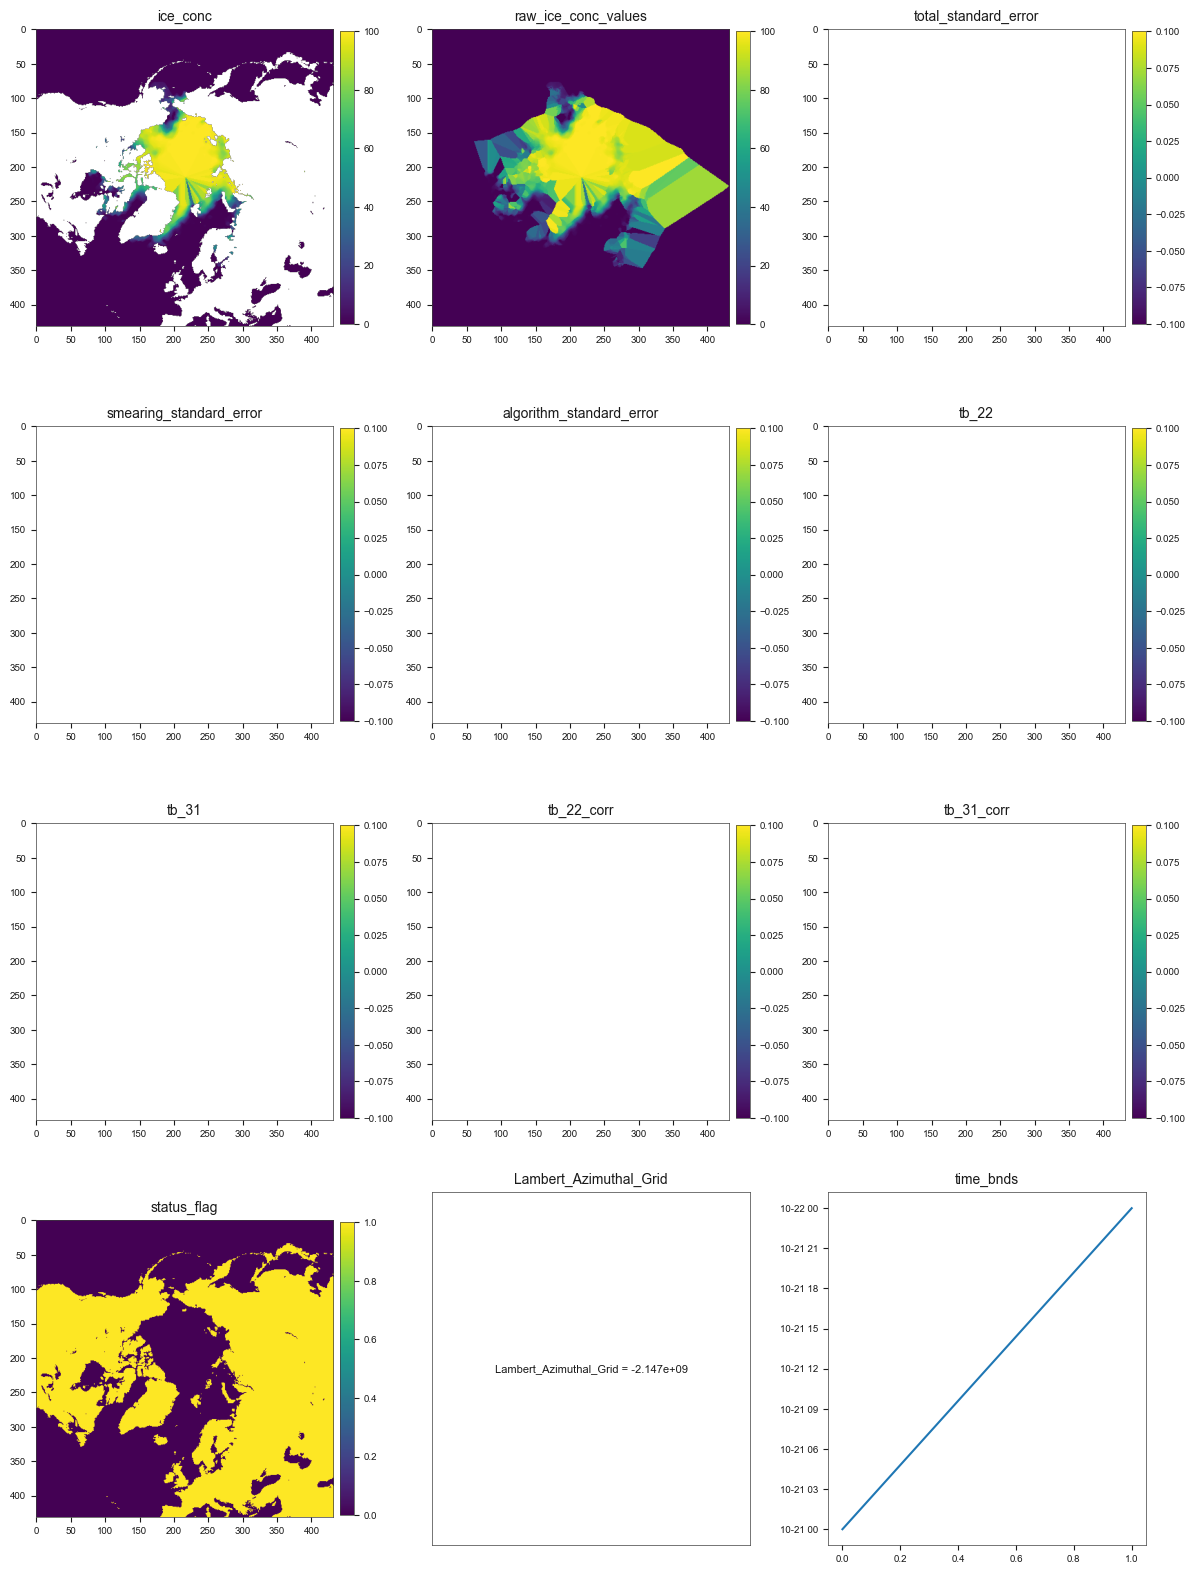

In [23]:
# =============================================================================
# PART 6d — Quick-look: plot every variable in a netCDF file
# =============================================================================
# General-purpose diagnostic (unrelated to the SIC-specific module above) --
# useful for eyeballing a file you haven't inspected yet, GNN output or not.
# =============================================================================

def plot_xarray_contents(ds_or_path, ncols=3, figsize_per_panel=4.0, cmap='viridis',
                          vars_to_skip=None, save_path=None):
    """Quick-look plot of every data variable in an xarray Dataset (or a
    path to a NetCDF file) -- one panel per variable. 2D fields are shown
    as images with their own colorbar, 1D as line plots, scalars are
    printed into their panel instead of plotted."""
    close_after = False
    if isinstance(ds_or_path, str):
        ds = xr.open_dataset(ds_or_path)
        close_after = True
    else:
        ds = ds_or_path

    vars_to_skip = set(vars_to_skip or [])
    var_names = [v for v in ds.data_vars if v not in vars_to_skip]
    if not var_names:
        print("No data variables to plot.")
        if close_after:
            ds.close()
        return

    ncols = min(ncols, len(var_names))
    nrows = -(-len(var_names) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_panel * ncols, figsize_per_panel * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, var_names):
        data = np.squeeze(np.asarray(ds[name].values))
        if data.ndim == 2:
            im = ax.imshow(data, origin='upper', cmap=cmap)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        elif data.ndim == 1:
            ax.plot(data)
        elif data.ndim == 0:
            ax.text(0.5, 0.5, f"{name} = {data.item():.4g}", ha='center', va='center',
                     transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.text(0.5, 0.5, f"{name}: shape {data.shape}\n(not plotted)",
                     ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(name, fontsize=10)

    for ax in axes[len(var_names):]:
        ax.axis('off')

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    if close_after:
        ds.close()


# Example: inspect the most recent GNN-filled NH period file.
_example_files = sorted(GNN_FILLED_DIR.rglob("*_NH-*.nc"))
if _example_files:
    plot_xarray_contents(str(_example_files[-1]))

### 6e. Load a GNN-filled period from netCDF (shared helper)

In [24]:
# =============================================================================
# PART 6e — Load one GNN-filled period straight from its netCDF file
# =============================================================================
# This is the piece that used to be missing. The original notebook's
# Figure-8-style comparison (former cell 8) got its "Filled SIC" panel from
# `load_target_arrays()`, which read `NEMS_{PERIOD_DAYS}day_{hemi}_{pk}.nc`
# out of SH_OUT_DIR / NH_OUT_DIR -- the DISCARDED v3.1 model's output
# (see the note at the top of Part 3). The actually-used v4 output, written
# in Part 4, lives at GNN_FILLED_DIR and has a different schema (no
# `gap_filled_flag` variable -- provenance has to be inferred by comparing
# `raw_ice_conc_values` against `ice_conc` in the same file). This helper
# reads from the right place with the right schema.
# =============================================================================

def find_period_containing(target_date, periods_dict, period_days=PERIOD_DAYS):
    """Return the period key containing `target_date`, or the nearest one."""
    best_key, best_dist = None, None
    for pk in periods_dict:
        start = datetime.strptime(pk, '%Y%m%d')
        end = start + timedelta(days=period_days - 1)
        if start <= target_date <= end:
            return pk
        dist = min(abs((target_date - start).days), abs((target_date - end).days))
        if best_dist is None or dist < best_dist:
            best_key, best_dist = pk, dist
    return best_key


def _period_netcdf_path(hemi_code, period_key, root_dir=PERIOD_ROOT_DIR,
                         mission_label=PERIOD_MISSION_LABEL):
    """Reconstruct the path write_one_period() (Part 4) would have used for
    this period, without needing to keep the in-memory nh_period_paths /
    sh_period_paths dict around -- lets this be re-run in a fresh session
    purely from files on disk."""
    period_start = datetime.strptime(period_key, '%Y%m%d')
    save_dir = Path(build_save_dir(root_dir, mission_label, hemi_code, period_start))
    matches = sorted(save_dir.glob(f"*{period_key}*.nc")) or sorted(save_dir.glob("*.nc"))
    return matches[0] if matches else None


def load_gnn_period_from_netcdf(hemi_code, periods_dict, target_date):
    """
    Returns (filled_pct, raw_pct, gnn_fill_mask, land_mask, period_key) for
    the period covering `target_date`, read entirely from the netCDF file
    Part 4 wrote -- no in-memory pipeline state required.
    """
    pk = find_period_containing(target_date, periods_dict)
    path = _period_netcdf_path(hemi_code, pk) if pk else None

    if path is None or not path.exists():
        print(f"  [{hemi_code}] No GNN-filled netCDF found for period {pk} under {GNN_FILLED_DIR}.")
        return None, None, None, None, pk

    with xr.open_dataset(path) as ds:
        filled = ds['ice_conc'].values[0].astype(np.float32) * 100.0
        raw = ds['raw_ice_conc_values'].values[0].astype(np.float32) * 100.0
        status_flag = ds['status_flag'].values[0].astype(np.int32)

    land_mask = (status_flag & 3) > 0
    gnn_fill_mask = np.isnan(raw) & ~np.isnan(filled) & ~land_mask
    return filled, raw, gnn_fill_mask, land_mask, pk

In [25]:
# =============================================================================
# PART 6e (cont.) — Shared NIC-archive helpers
# =============================================================================
# read_nic_bin / nic_to_sic / nic_file_dates_all used to be defined in
# former cell 7 -- which the Figure-8-style plot (former cell 8) silently
# depended on having already been run earlier in the session, purely
# because of cell order, despite cell 7 otherwise being about a completely
# different figure (the SIE time series, now superseded by former cell 22
# -- see Part 6h). Defined once, here, ahead of anything that needs them.
# =============================================================================

def parse_nic_date(fname):
    m = re.search(r"nic_weekly_(\d{4})_(\d{2})_(\d{2})", fname)
    return datetime(int(m.group(1)), int(m.group(2)), int(m.group(3))) if m else None


def read_nic_bin(path, grid_size=361):
    return np.fromfile(path, dtype=np.uint8).reshape(grid_size, grid_size)


def nic_to_sic(grid):
    sic = grid.astype(np.float32).copy()
    sic[grid == 108] = 100.0
    sic[np.isin(grid, [157, 253, 254])] = np.nan
    return sic


def nic_land_mask(grid):
    return grid == 254


nic_bin_files_all = sorted(glob.glob(os.path.join(NIC_ROOT, "**", "nic_weekly_*.bin"), recursive=True))
nic_file_dates_all = [(f, parse_nic_date(os.path.basename(f))) for f in nic_bin_files_all]
nic_file_dates_all = [(f, d) for f, d in nic_file_dates_all if d is not None]
nic_file_dates_all.sort(key=lambda x: x[1])
print(f"Found {len(nic_file_dates_all)} NIC weekly ice-chart file(s) under {NIC_ROOT}.")

Found 53 NIC weekly ice-chart file(s) under C:\Users\user\OneDrive\Desktop\CCI.


### 6f. Figure-8-style comparison

SIC / T$_B$ / tie points / uncertainty / filled SIC / NEMS-NIC difference. NH: March 1973, SH: August 1973.

In [26]:
# =============================================================================
# PART 6f — Figure-8-style comparison (SIC / Tb / tie points / uncertainty /
#            filled SIC / NEMS-NIC difference), NH: March 1973, SH: Aug 1973
# =============================================================================
# Panels A/G (raw SIC) and E/K (filled SIC) now come from the netCDF file
# Part 4 wrote, via Part 6e's loader -- these used to come from
# `load_target_arrays()` reading the discarded v3.1 model's own (separate,
# stale) netCDF output. Panels B/H (Tb) and C/I (tie points) still come
# from the monthly-aggregation record (Part 1e) and arctic_record /
# antarctic_record (Part 1) respectively: brightness temperature and
# per-observation tie-point membership aren't preserved past the 14-day
# compositing step, so they simply aren't in the period netCDF to read back
# -- this is an honest limitation of what the product stores, not an
# in-memory shortcut, so it's kept as a visible seam here rather than
# papered over.
# =============================================================================

TARGET_MONTH_NH, TARGET_MONTH_SH = 3, 8
TARGET_DATE_NH = datetime(1973, 3, 15)
TARGET_DATE_SH = datetime(1973, 8, 15)
FOOTPRINT_WINDOW_PX = 9  # None disables the footprint-scale sensitivity test

nh_area_def = _get_area_definition('arctic')
sh_area_def = _get_area_definition('antarctic')
nh_lon_grid, nh_lat_grid = nh_area_def.get_lonlats()
sh_lon_grid, sh_lat_grid = sh_area_def.get_lonlats()

# ── 1. Monthly Tb grid (panel B/H) ──────────────────────────────────────────
for region_name, record, mask_path, monthly_results, target_month in [
        ('arctic', arctic_record, arctic_lmask, arctic_monthly_results, TARGET_MONTH_NH),
        ('antarctic', antarctic_record, antarctic_lmask, antarctic_monthly_results, TARGET_MONTH_SH)]:
    if monthly_results.get(target_month) is None:
        print(f"[{region_name}] no data for month {target_month}, skipping Tb grid.")
        continue
    month_df = record[record['month'] == target_month].copy()
    resampled_tb = resample_to_ease2(month_df, region_name, ['tb_31_phys_corrected'],
                                      mask_path=mask_path, month=target_month)
    monthly_results[target_month]['tb31'] = resampled_tb[:, :, 0]
print("Gridded monthly Tb (for panel B).")

# ── 2. Raw + filled SIC, straight from the GNN-filled netCDF ───────────────
nh_e_filled, nh_e_raw, nh_e_gnn_mask, nh_land, nh_e_pk = load_gnn_period_from_netcdf(
    'N', nh_periods, TARGET_DATE_NH)
sh_e_filled, sh_e_raw, sh_e_gnn_mask, sh_land, sh_e_pk = load_gnn_period_from_netcdf(
    'S', sh_periods, TARGET_DATE_SH)

nh_nems_period_label = period_label(nh_e_pk, PERIOD_DAYS) if nh_e_pk else '?'
sh_nems_period_label = period_label(sh_e_pk, PERIOD_DAYS) if sh_e_pk else '?'
print(f"NH NEMS panel covers the 14-day period: {nh_nems_period_label}")
print(f"SH NEMS panel covers the 14-day period: {sh_nems_period_label}")

for hemi, raw, filled, mask in [('NH', nh_e_raw, nh_e_filled, nh_e_gnn_mask),
                                 ('SH', sh_e_raw, sh_e_filled, sh_e_gnn_mask)]:
    if mask is not None:
        print(f"[{hemi}] NaN->value fill count: {int(mask.sum()):,} px ({mask.mean()*100:.1f}% of grid)")

# ── 2b. Nearest NIC weekly ice chart (NH only) ──────────────────────────────
def _load_nearest_nic_sic(target_date, file_dates, grid_size=361):
    if not file_dates:
        return None, None
    fpath, fdate = min(file_dates, key=lambda fd: abs((fd[1] - target_date).days))
    return nic_to_sic(read_nic_bin(fpath, grid_size=grid_size)), fdate


def _panel_or_blank(ax, data, land, cmap, norm, letter, title=None, msg='No data', cbar_label=None):
    if data is None or not np.isfinite(data).any():
        _blank_panel(ax, letter, title, msg=msg)
    else:
        _panel(ax, data, cmap, norm, land, letter, title, cbar_label=cbar_label)


nh_nic_sic, nh_nic_date = _load_nearest_nic_sic(TARGET_DATE_NH, nic_file_dates_all)
nh_nems_nic_diff = None
nh_nic_sic_regridded = None
if nh_nic_sic is not None and nh_e_filled is not None:
    print(f"[NH] Nearest NIC chart: {nh_nic_date.date()} "
          f"({abs((nh_nic_date - TARGET_DATE_NH).days)} days from target)")
    if nh_nic_sic.shape != nh_e_filled.shape:
        zf = (nh_e_filled.shape[0] / nh_nic_sic.shape[0], nh_e_filled.shape[1] / nh_nic_sic.shape[1])
        nh_nic_sic_regridded = zoom(np.nan_to_num(nh_nic_sic, nan=-1), zf, order=0)
        nh_nic_sic_regridded[nh_nic_sic_regridded < 0] = np.nan
    else:
        nh_nic_sic_regridded = nh_nic_sic
    nh_nems_nic_diff = nh_e_filled - nh_nic_sic_regridded
else:
    print("[NH] No NIC files found -- panel F left blank.")

# ── 2c. Nearest raw ESMR SIC, skipping mostly-empty files ───────────────────
def _load_nearest_esmr_sic(target_date, esmr_dict, max_days=30, min_valid_frac=0.05):
    if not esmr_dict:
        return None, None, None
    parsed = sorted(((k, datetime.strptime(k, '%Y%m%d')) for k in esmr_dict),
                     key=lambda kd: abs((kd[1] - target_date).days))
    for k, d in parsed:
        if abs((d - target_date).days) > max_days:
            break
        grid = load_ice(esmr_dict[k])
        valid_frac = np.isfinite(grid).mean()
        if valid_frac >= min_valid_frac:
            return grid, d, valid_frac
        print(f"  [ESMR skip] {d.date()}: only {valid_frac*100:.1f}% valid, trying next nearest date")
    print(f"  [ESMR] No file within {max_days} days of {target_date.date()} met the threshold.")
    return None, None, None


nh_e_esmr, nh_esmr_date, nh_esmr_valid_frac = _load_nearest_esmr_sic(TARGET_DATE_NH, nh_esmr)
sh_e_esmr, sh_esmr_date, sh_esmr_valid_frac = _load_nearest_esmr_sic(TARGET_DATE_SH, sh_esmr)

# ── 2d. Grid Tb + 14-day dynamic tie-point locations (FYI/MYI/OW) ───────────
def _period_dynamic_tiepoint_flags(record, period_start, period_end, min_c_ice=0.95,
                                    col_c_ice='c_ice_hybrid', col_22='tb_22_phys_corrected',
                                    col_31='tb_31_phys_corrected', iqr_multiplier=1.0,
                                    ow_min_sst=271, ow_max_sst=275, ow_outlier_sigma=1.0):
    dt = pd.to_datetime(record['datetime'])
    period_sel = (dt >= period_start) & (dt <= period_end)
    sub = record[period_sel]

    ice_eligible = sub[col_c_ice] >= min_c_ice
    ice_df = sub[ice_eligible].dropna(subset=[col_22, col_31])
    fyi_idx, myi_idx = pd.Index([]), pd.Index([])
    if len(ice_df) > 0:
        clean = remove_outliers_multivariate(ice_df, columns=[col_22, col_31],
                                              method='iqr', iqr_multiplier=iqr_multiplier)
        if len(clean) > 0:
            n = max(1, int(len(clean) * 0.10))
            fyi_idx = clean.nlargest(n, col_31).index
            myi_idx = clean.nsmallest(n, col_31).index

    ow_eligible = ((sub['Ts'] >= ow_min_sst) & (sub['Ts'] <= ow_max_sst) & (sub[col_c_ice] <= 0.0))
    ow_df = sub[ow_eligible].dropna(subset=[col_22, col_31])
    ow_idx = pd.Index([])
    if len(ow_df) > 0:
        z22 = np.abs((ow_df[col_22] - ow_df[col_22].mean()) / ow_df[col_22].std())
        z31 = np.abs((ow_df[col_31] - ow_df[col_31].mean()) / ow_df[col_31].std())
        ow_idx = ow_df[(z22 < ow_outlier_sigma) & (z31 < ow_outlier_sigma)].index

    return record.index.isin(fyi_idx), record.index.isin(myi_idx), record.index.isin(ow_idx)


def _period_tb_tiepoint_grid_v2(record, mask_path, region_name, period_key, period_days=PERIOD_DAYS):
    if period_key is None:
        return None, None
    period_start = datetime.strptime(period_key, '%Y%m%d')
    period_end = period_start + timedelta(days=period_days - 1)
    fyi_flag, myi_flag, ow_flag = _period_dynamic_tiepoint_flags(record, period_start, period_end)

    dt = pd.to_datetime(record['datetime'])
    period_sel = (dt >= period_start) & (dt <= period_end)
    period_df = record[period_sel].copy()
    period_df['fyi_flag'] = fyi_flag[period_sel].astype(float)
    period_df['myi_flag'] = myi_flag[period_sel].astype(float)
    period_df['ow_flag'] = ow_flag[period_sel].astype(float)
    if period_df.empty:
        print(f"  [{region_name}] no observations in window {period_start.date()}-{period_end.date()}.")
        return None, None

    resampled = resample_to_ease2(period_df, region_name,
                                   ['tb_31_phys_corrected', 'fyi_flag', 'myi_flag', 'ow_flag'],
                                   mask_path=mask_path, month=None)
    fyi_frac, myi_frac, ow_frac = resampled[:, :, 1], resampled[:, :, 2], resampled[:, :, 3]
    tp_class = np.zeros(fyi_frac.shape, dtype=np.int8)
    tp_class[fyi_frac >= 0.5] = 1
    tp_class[myi_frac >= 0.5] = 2
    tp_class[ow_frac >= 0.5] = 3
    return resampled[:, :, 0], tp_class


nh_tb31_period, nh_tpc_period = _period_tb_tiepoint_grid_v2(arctic_record, arctic_lmask, 'arctic', nh_e_pk)
sh_tb31_period, sh_tpc_period = _period_tb_tiepoint_grid_v2(antarctic_record, antarctic_lmask, 'antarctic', sh_e_pk)
print("Gridded Tb + 14-day dynamic tie-point (FYI/MYI/OW) locations, matching the NEMS period.")

c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
  Found climatology variable: climatology, using month 3


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
  Found climatology variable: climatology, using month 8
Gridded monthly Tb (for panel B).
NH NEMS panel covers the 14-day period: 1973-02-25 to 1973-03-10
SH NEMS panel covers the 14-day period: 1973-08-12 to 1973-08-25
[NH] NaN->value fill count: 0 px (0.0% of grid)
[SH] NaN->value fill count: 0 px (0.0% of grid)
[NH] Nearest NIC chart: 1973-03-13 (2 days from target)


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask


c:\Users\user\anaconda3\envs\CCI\Lib\site-packages\pyresample\kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 87500 m for some data points
  get_neighbour_info(source_geo_def,


  Found landmask variable: lmask
Gridded Tb + 14-day dynamic tie-point (FYI/MYI/OW) locations, matching the NEMS period.


  [arctic] footprint-scale resampling term (window=9px): mean=297.77 pp, max=2900.00 pp
  [antarctic] footprint-scale resampling term (window=9px): mean=221.89 pp, max=2718.47 pp
Saved: C:\Users\user\OneDrive\Desktop\CCI\plots\fig8_style_NEMS_march_august_1973.pdf, C:\Users\user\OneDrive\Desktop\CCI\plots\fig8_style_NEMS_march_august_1973.png


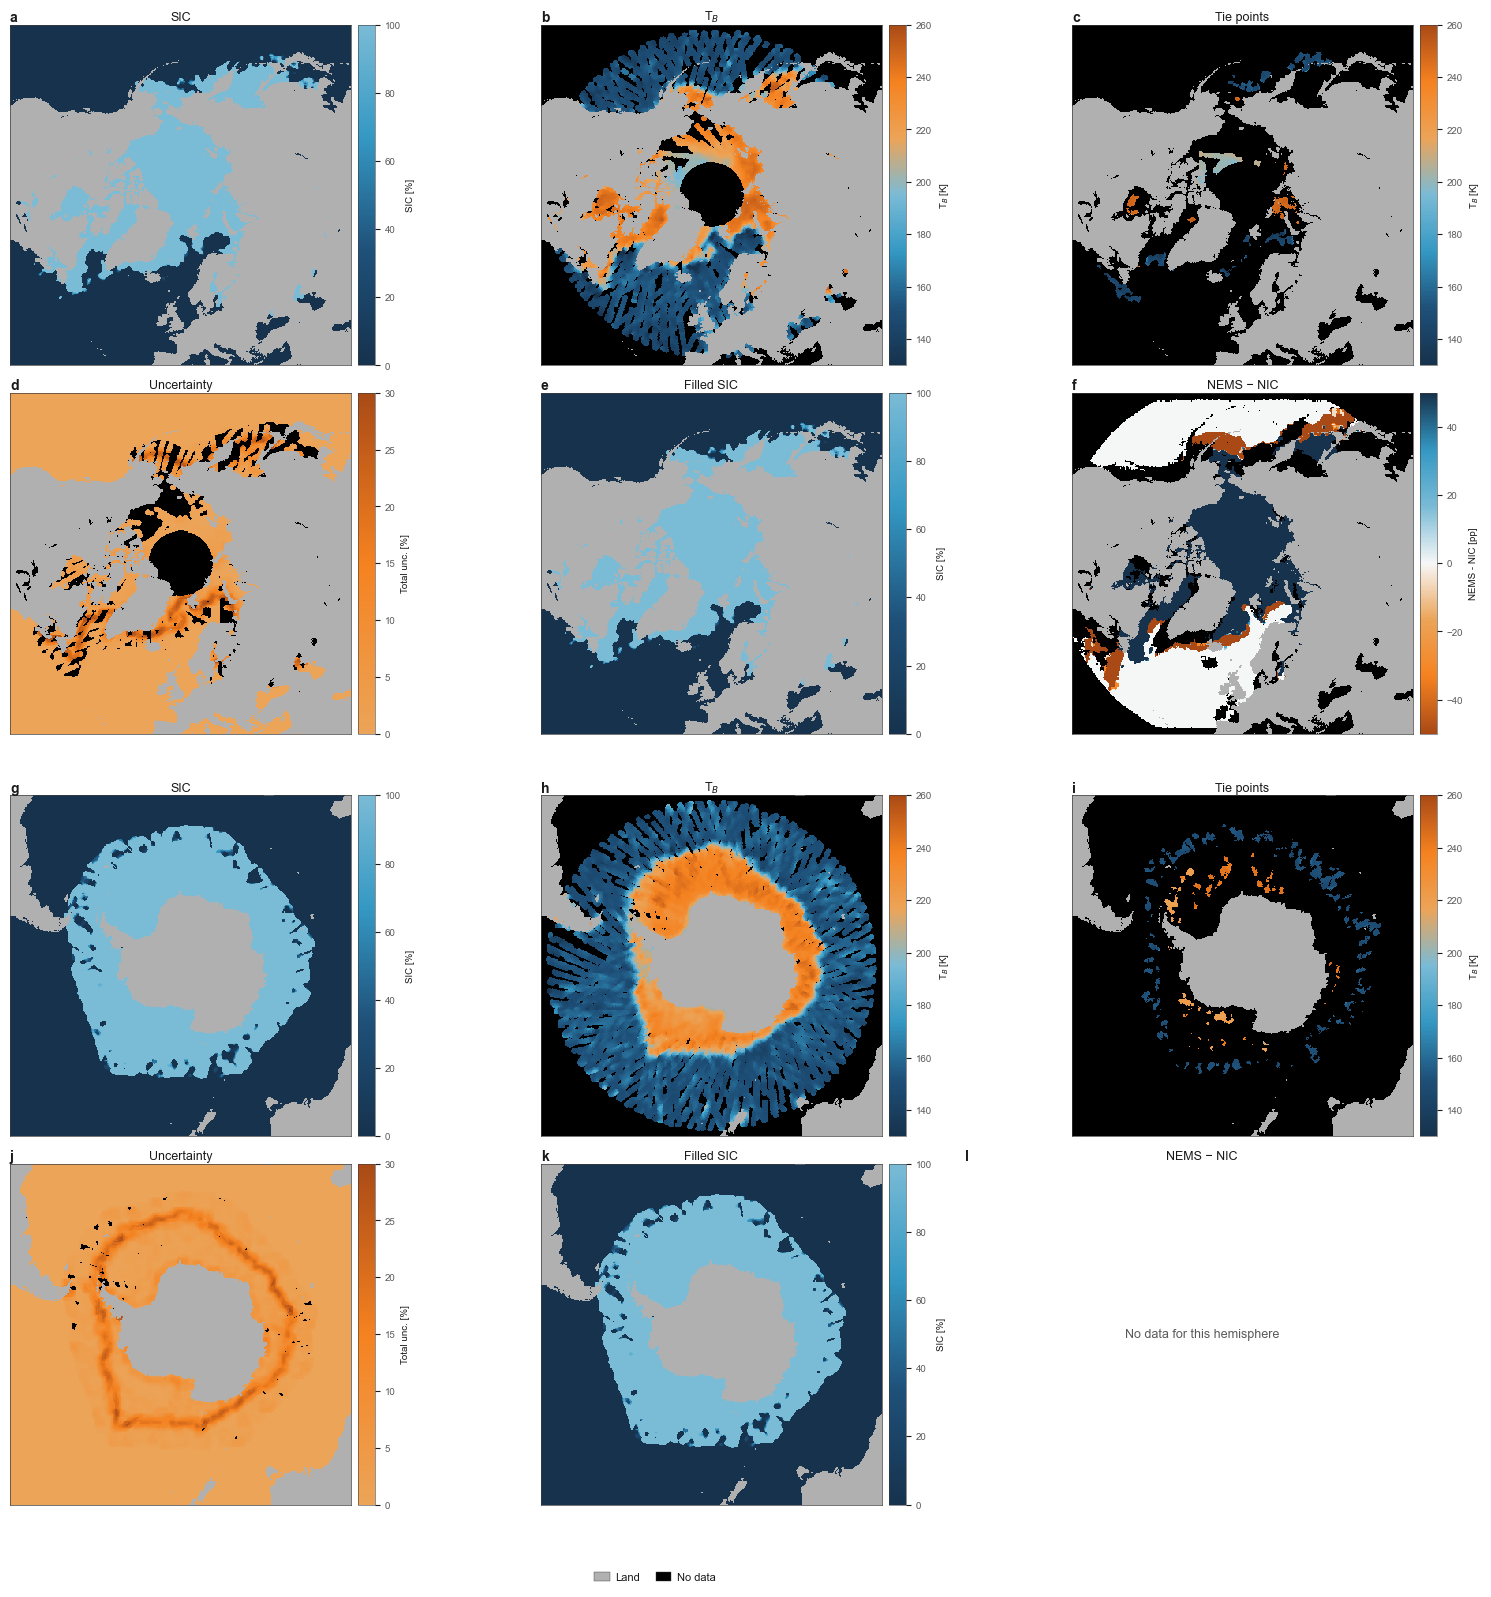


Regional NEMS vs. NIC (and vs. ESMR where available), 1973-03-15:

Labrador Sea  (n=1933 px)
  NEMS - NIC : mean=+3387.6 pp   std=3485.5 pp   |diff|>20pp: 1170 px
  NEMS - ESMR: mean=+2848.6 pp   std=3412.7 pp   (ESMR date used: 1973-02-28, 42% valid)
  -> NEMS closer to ESMR than to NIC in this region: True

White/Barents Sea  (n=2119 px)
  NEMS - NIC : mean=+3497.0 pp   std=3812.8 pp   |diff|>20pp: 1414 px
  NEMS - ESMR: mean=+3843.1 pp   std=3885.5 pp   (ESMR date used: 1973-02-28, 42% valid)
  -> NEMS closer to ESMR than to NIC in this region: False



In [27]:
# =============================================================================
# PART 6f (cont.) — Panel assembly
# =============================================================================

def _to_pct(arr):
    if arr is None:
        return arr
    finite = arr[np.isfinite(arr)]
    if finite.size and np.nanmax(finite) <= 1.5:
        return arr * 100.0
    return arr


def _fix_mixed_scale(arr, fill_mask):
    arr = arr.copy()
    obs, fill = arr[~fill_mask], arr[fill_mask]
    obs_max = np.nanmax(obs) if np.isfinite(obs).any() else np.nan
    fill_max = np.nanmax(fill) if np.isfinite(fill).any() else np.nan
    if np.isfinite(obs_max) and np.isfinite(fill_max) and obs_max > 1.5 and fill_max <= 1.5:
        arr[fill_mask] = arr[fill_mask] * 100.0
        print(f"  [scale fix] rescaled {int(fill_mask.sum()):,} filled px "
              f"(subset max {fill_max:.3f} -> now {np.nanmax(arr[fill_mask]):.1f}, vs observed max {obs_max:.1f})")
    return arr


def _panel_label(ax, letter, title=None):
    if title:
        ax.set_title(title, fontsize=9, fontweight='normal', color=INK, pad=3)
    ax.text(0.0, 1.0, letter.lower(), transform=ax.transAxes, fontsize=10,
            fontweight='bold', color=INK, va='bottom', ha='left')


def _panel(ax, data, cmap, norm, land, letter, title=None, categorical=False, cbar_label=None):
    if categorical:
        rgba = np.zeros((*data.shape, 4))
        rgba[land] = mcolors.to_rgba(LAND_COL)
        ok = ~land
        rgba[ok] = cmap(norm(data[ok].astype(float)))
    else:
        rgba = rgba_with_land(data, cmap, norm, land)
    ax.imshow(rgba, origin='upper', interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(FRAME); spine.set_linewidth(0.5)
    _panel_label(ax, letter, title)
    if not categorical:
        cb = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, fraction=0.04, pad=0.015)
        if cbar_label:
            cb.set_label(cbar_label, fontsize=7)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED, fontsize=7)
        cb.outline.set_edgecolor(FRAME); cb.outline.set_linewidth(0.4)


def _panel_tp_shared_cbar(ax, tb31, tp_class, land, letter, title=None, cmap=CMAP_TB, norm=TB_NORM):
    """Tie-point panel with a single shared colorbar for FYI, MYI, and OW together."""
    if tb31 is None or tp_class is None:
        ax.set_facecolor('white'); ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        _panel_label(ax, letter, title)
        ax.text(0.5, 0.5, 'No tie-point data\nfor this period', ha='center', va='center',
                fontsize=9, color=MUTED, transform=ax.transAxes)
        return
    data = np.where(tp_class > 0, tb31, np.nan)
    rgba = rgba_with_land(data, cmap, norm, land)
    ax.imshow(rgba, origin='upper', interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(FRAME); spine.set_linewidth(0.5)
    _panel_label(ax, letter, title)
    cb = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, fraction=0.04, pad=0.015)
    cb.set_label('T$_B$ [K]', fontsize=7)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED, fontsize=7)
    cb.outline.set_edgecolor(FRAME); cb.outline.set_linewidth(0.4)


def _blank_panel(ax, letter, title=None, msg='No data for this hemisphere'):
    ax.set_facecolor('white'); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    _panel_label(ax, letter, title)
    ax.text(0.5, 0.5, msg, ha='center', va='center', fontsize=9, color=MUTED, transform=ax.transAxes)


def _overall_uncertainty_frac(sic_grid_frac, unc_algorithm_grid_frac, window_size=3, k_factor=0.29,
                               extra_window_size=FOOTPRINT_WINDOW_PX, region_name=''):
    unc_resampling = calculate_resampling_uncertainty(sic_grid_frac, window_size=window_size, k_factor=k_factor)
    total = calculate_total_uncertainty(unc_algorithm_grid_frac, unc_resampling)
    if extra_window_size is not None:
        unc_resampling_fp = calculate_resampling_uncertainty(sic_grid_frac, window_size=extra_window_size, k_factor=k_factor)
        total = calculate_total_uncertainty(total, unc_resampling_fp)
        print(f"  [{region_name}] footprint-scale resampling term (window={extra_window_size}px): "
              f"mean={np.nanmean(unc_resampling_fp)*100:.2f} pp, max={np.nanmax(unc_resampling_fp)*100:.2f} pp")
    return total


fig = plt.figure(figsize=(16, 16))
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 1, 0.02, 1, 1], wspace=0.12, hspace=0.1,
                        left=0.03, right=0.99, top=0.98, bottom=0.055)

hemi_blocks = [
    ('NH', 0, TARGET_MONTH_NH, arctic_monthly_results, nh_land, nh_e_filled, nh_e_raw,
     nh_e_pk, nh_nems_period_label, nh_nems_nic_diff, nh_tb31_period, nh_tpc_period),
    ('SH', 3, TARGET_MONTH_SH, antarctic_monthly_results, sh_land, sh_e_filled, sh_e_raw,
     sh_e_pk, sh_nems_period_label, None, sh_tb31_period, sh_tpc_period),
]

for (hemi, row0, tgt_month, monthly_results, land, filled_sic, raw_sic, pk,
     nems_period_lbl, nems_nic_diff, tb31_period, tpc_period) in hemi_blocks:

    if land is None or filled_sic is None:
        for col, letter in enumerate(['A', 'B', 'C'] if hemi == 'NH' else ['G', 'H', 'I']):
            ax = fig.add_subplot(gs[row0, col])
            _blank_panel(ax, letter, msg=f'No GNN-filled netCDF\nfound for {hemi}')
        continue

    sic = _to_pct(raw_sic)
    tb31 = tb31_period if tb31_period is not None else np.full(land.shape, np.nan)

    res = monthly_results.get(tgt_month)
    unc_frac = res['uncertainty'] if res else np.full(land.shape, np.nan)
    sic_frac_for_unc = raw_sic if np.nanmax(np.abs(np.nan_to_num(raw_sic))) <= 1.5 else raw_sic / 100.0
    unc_total = _to_pct(_overall_uncertainty_frac(
        sic_frac_for_unc, unc_frac, region_name='arctic' if hemi == 'NH' else 'antarctic'))

    fill_mask = np.isnan(raw_sic) & ~np.isnan(filled_sic) & ~land
    filled_sic = _fix_mixed_scale(filled_sic, fill_mask)

    ax_a = fig.add_subplot(gs[row0, 0])
    _panel(ax_a, sic, CMAP_ICE, ICE_NORM, land, 'A' if hemi == 'NH' else 'G', 'SIC', cbar_label='SIC [%]')
    ax_b = fig.add_subplot(gs[row0, 1])
    _panel(ax_b, tb31, CMAP_TB, TB_NORM, land, 'B' if hemi == 'NH' else 'H', 'T$_B$', cbar_label='T$_B$ [K]')
    ax_c = fig.add_subplot(gs[row0, 2])
    _panel_tp_shared_cbar(ax_c, tb31_period, tpc_period, land, 'C' if hemi == 'NH' else 'I', 'Tie points')

    ax_d = fig.add_subplot(gs[row0+1, 0])
    _panel(ax_d, unc_total, CMAP_ERR, ERR_NORM, land, 'D' if hemi == 'NH' else 'J', 'Uncertainty', cbar_label='Total unc. [%]')
    ax_e = fig.add_subplot(gs[row0+1, 1])
    _panel(ax_e, filled_sic, CMAP_ICE, ICE_NORM, land, 'E' if hemi == 'NH' else 'K', 'Filled SIC', cbar_label='SIC [%]')

    ax_f = fig.add_subplot(gs[row0+1, 2])
    if nems_nic_diff is not None:
        _panel(ax_f, nems_nic_diff, CMAP_DIFF, DIFF_NORM, land, 'F' if hemi == 'NH' else 'L',
               'NEMS \u2212 NIC', cbar_label='NEMS - NIC [pp]')
    else:
        _blank_panel(ax_f, 'F' if hemi == 'NH' else 'L', 'NEMS \u2212 NIC')

legend_handles = [
    mpatches.Patch(facecolor=LAND_COL, edgecolor=FRAME, linewidth=0.3, label='Land'),
    mpatches.Patch(facecolor='black', edgecolor=FRAME, linewidth=0.3, label='No data'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2,
           fontsize=8, handlelength=1.4, handleheight=0.9, columnspacing=1.4, handletextpad=0.5, frameon=False)

saved = []
for ext in ('pdf', 'png'):
    out_path = PLOT_DIR / f'fig8_style_NEMS_march_august_1973.{ext}'
    fig.savefig(out_path, bbox_inches='tight')
    saved.append(str(out_path))
print('Saved: ' + ', '.join(saved))
plt.show()


# ── Regional sanity check: Labrador Sea + White/Barents Sea ────────────────
REGIONS = {
    'Labrador Sea': dict(lat=(50, 62), lon=(-65, -45)),
    'White/Barents Sea': dict(lat=(66, 80), lon=(20, 60)),
}


def region_mask(lat_grid, lon_grid, lat_range, lon_range):
    return ((lat_grid >= lat_range[0]) & (lat_grid <= lat_range[1]) &
            (lon_grid >= lon_range[0]) & (lon_grid <= lon_range[1]))


if nh_nems_nic_diff is None:
    print("[regional check] no NEMS-vs-NIC difference available for NH -- nothing to compare.")
else:
    print(f"\nRegional NEMS vs. NIC (and vs. ESMR where available), {TARGET_DATE_NH.date()}:\n")
    for name, rng in REGIONS.items():
        m = region_mask(nh_lat_grid, nh_lon_grid, rng['lat'], rng['lon']) & ~nh_land
        n_px = int(m.sum())
        if n_px == 0:
            print(f"  {name}: no grid cells matched this lat/lon box.")
            continue
        diff_nic = nh_nems_nic_diff[m]
        print(f"{name}  (n={n_px} px)")
        print(f"  NEMS - NIC : mean={np.nanmean(diff_nic):+6.1f} pp   std={np.nanstd(diff_nic):5.1f} pp   "
              f"|diff|>20pp: {int((np.abs(diff_nic) > 20).sum())} px")
        if nh_e_esmr is not None:
            diff_esmr = (nh_e_filled - nh_e_esmr)[m]
            print(f"  NEMS - ESMR: mean={np.nanmean(diff_esmr):+6.1f} pp   std={np.nanstd(diff_esmr):5.1f} pp   "
                  f"(ESMR date used: {nh_esmr_date.date()}, {nh_esmr_valid_frac*100:.0f}% valid)")
            closer_to_esmr = np.nanmean(np.abs(diff_esmr)) < np.nanmean(np.abs(diff_nic))
            print(f"  -> NEMS closer to ESMR than to NIC in this region: {bool(closer_to_esmr)}")
        else:
            print("  NEMS - ESMR: no usable ESMR file found near this date for NH -- skipped.")
        print()

### 6g. Regional zoom companion

Labrador Sea and White/Barents Sea, NH target date only.

  [Labrador Sea] NIC chart date: 1973-03-13
  [Labrador Sea] ESMR date: 1973-02-28, 42% valid
  [Labrador Sea] NEMS period: 1973-02-25 to 1973-03-10
  [White/Barents Sea] NIC chart date: 1973-03-13
  [White/Barents Sea] ESMR date: 1973-02-28, 42% valid
  [White/Barents Sea] NEMS period: 1973-02-25 to 1973-03-10
Saved: C:\Users\user\OneDrive\Desktop\CCI\plots\fig_regional_zoom_nic_esmr_nems.pdf, C:\Users\user\OneDrive\Desktop\CCI\plots\fig_regional_zoom_nic_esmr_nems.png


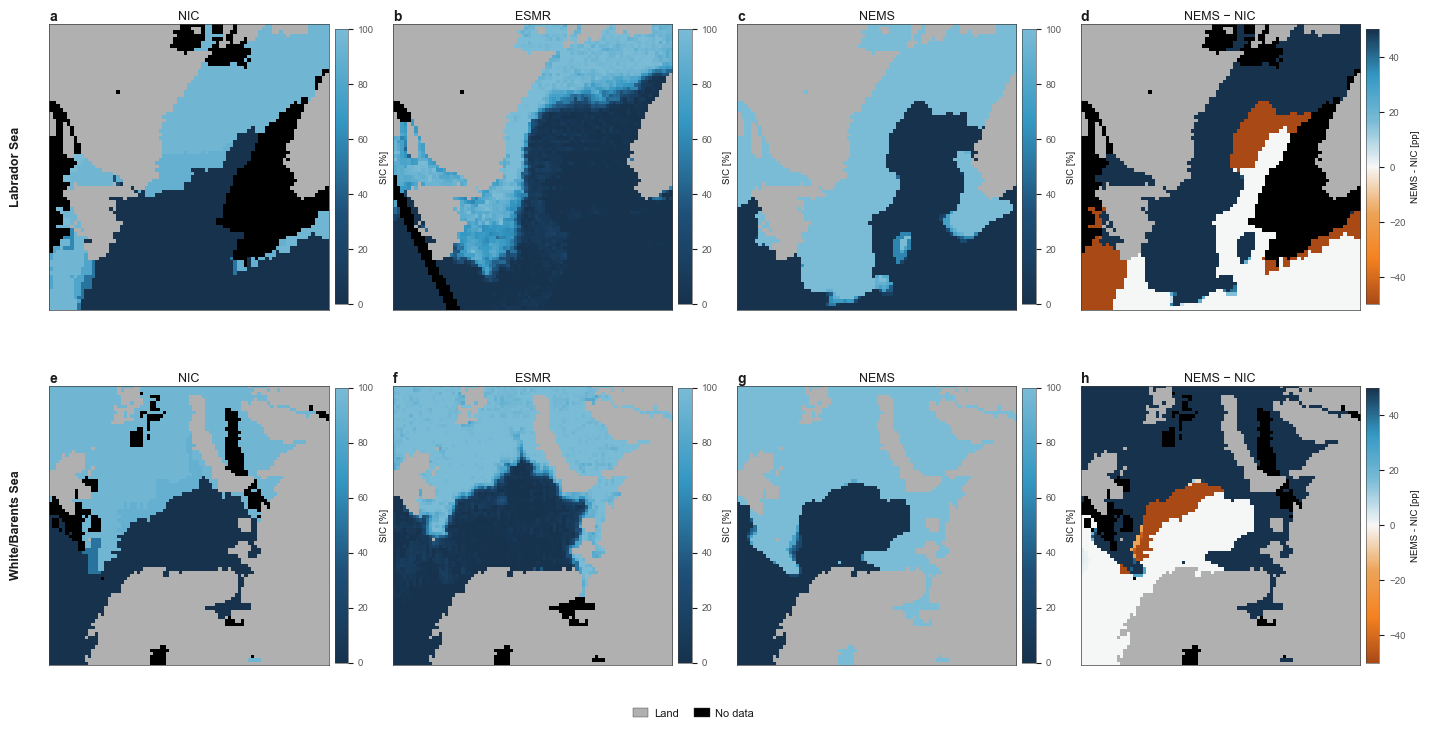

In [28]:
# =============================================================================
# PART 6g — Regional zoom: NIC / raw ESMR / NEMS (GNN-filled) / NEMS-NIC diff
# =============================================================================
# Companion to Part 6f -- reuses its data (nh_e_filled etc., which already
# came from the GNN-filled netCDF via Part 6e/6f, not from any further
# in-memory-only state). Cropped to Labrador Sea and White/Barents Sea,
# NH target date only (that's where the NIC panel exists).
# =============================================================================

def _bbox_from_mask(mask):
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if rows.size == 0 or cols.size == 0:
        return None
    r0, r1 = max(rows.min() - 5, 0), min(rows.max() + 5, mask.shape[0])
    c0, c1 = max(cols.min() - 5, 0), min(cols.max() + 5, mask.shape[1])
    return r0, r1, c0, c1


def _crop(arr, bbox):
    r0, r1, c0, c1 = bbox
    return arr[r0:r1, c0:c1]


# Local, uniquely-named panel helpers so this figure can't break just
# because Part 6f's _panel/_blank_panel/_panel_or_blank signatures change.
def _zoom_label(ax, letter, title=None):
    if title:
        ax.set_title(title, fontsize=9, fontweight='normal', color=INK, pad=3)
    ax.text(0.0, 1.0, letter.lower(), transform=ax.transAxes, fontsize=10,
            fontweight='bold', color=INK, va='bottom', ha='left')


def _zoom_panel(ax, data, land, cmap, norm, letter, title=None, cbar_label=None):
    rgba = rgba_with_land(data, cmap, norm, land)
    ax.imshow(rgba, origin='upper', interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(FRAME); spine.set_linewidth(0.5)
    _zoom_label(ax, letter, title)
    cb = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, fraction=0.046, pad=0.02)
    if cbar_label:
        cb.set_label(cbar_label, fontsize=7)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED, fontsize=7)
    cb.outline.set_edgecolor(FRAME); cb.outline.set_linewidth(0.4)


def _zoom_blank(ax, letter, title=None, msg='No data'):
    ax.set_facecolor('white'); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    _zoom_label(ax, letter, title)
    ax.text(0.5, 0.5, msg, ha='center', va='center', fontsize=9, color=MUTED, transform=ax.transAxes)


def _zoom_panel_or_blank(ax, data, land, cmap, norm, letter, title=None, msg='No data', cbar_label=None):
    if data is None or not np.isfinite(data).any():
        _zoom_blank(ax, letter, title, msg=msg)
    else:
        _zoom_panel(ax, data, land, cmap, norm, letter, title, cbar_label=cbar_label)


LETTERS_6 = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

fig5 = plt.figure(figsize=(14, 7.5))
gs5 = gridspec.GridSpec(2, 4, wspace=0.15, hspace=0.25, left=0.04, right=0.99, top=0.94, bottom=0.08)

for row_idx, (region_name, rng) in enumerate(REGIONS.items()):
    m = region_mask(nh_lat_grid, nh_lon_grid, rng['lat'], rng['lon'])
    bbox = _bbox_from_mask(m)
    row_letters = LETTERS_6[row_idx * 4:(row_idx + 1) * 4]

    if bbox is None or nh_land is None:
        for col in range(4):
            ax = fig5.add_subplot(gs5[row_idx, col])
            _zoom_blank(ax, row_letters[col], msg='No grid cells\nin this box')
        continue

    land_c = _crop(nh_land, bbox)
    nic_c = _crop(nh_nic_sic_regridded, bbox) if nh_nic_sic is not None else None
    esmr_c = _crop(nh_e_esmr, bbox) if nh_e_esmr is not None else None
    nems_c = _crop(nh_e_filled, bbox)
    diff_c = _crop(nh_nems_nic_diff, bbox) if nh_nems_nic_diff is not None else None

    ax0 = fig5.add_subplot(gs5[row_idx, 0])
    _zoom_panel_or_blank(ax0, nic_c, land_c, CMAP_ICE, ICE_NORM, row_letters[0], 'NIC',
                         msg='No NIC data', cbar_label='SIC [%]')
    ax0.text(-0.12, 0.5, region_name, transform=ax0.transAxes, fontsize=9, fontweight='bold',
             color=INK, rotation=90, va='center', ha='center')
    if nh_nic_sic is not None:
        print(f"  [{region_name}] NIC chart date: {nh_nic_date.date()}")

    ax1 = fig5.add_subplot(gs5[row_idx, 1])
    _zoom_panel_or_blank(ax1, esmr_c, land_c, CMAP_ICE, ICE_NORM, row_letters[1], 'ESMR',
                         msg='No usable ESMR\n(gap/coverage)', cbar_label='SIC [%]')
    if nh_e_esmr is not None:
        print(f"  [{region_name}] ESMR date: {nh_esmr_date.date()}, {nh_esmr_valid_frac*100:.0f}% valid")

    ax2 = fig5.add_subplot(gs5[row_idx, 2])
    _zoom_panel_or_blank(ax2, nems_c, land_c, CMAP_ICE, ICE_NORM, row_letters[2], 'NEMS', cbar_label='SIC [%]')
    print(f"  [{region_name}] NEMS period: {nh_nems_period_label}")

    ax3 = fig5.add_subplot(gs5[row_idx, 3])
    if diff_c is not None:
        _zoom_panel(ax3, diff_c, land_c, CMAP_DIFF, DIFF_NORM, row_letters[3], 'NEMS \u2212 NIC', cbar_label='NEMS - NIC [pp]')
    else:
        _zoom_blank(ax3, row_letters[3], 'NEMS \u2212 NIC', msg='No NIC data')

legend_handles = [
    mpatches.Patch(facecolor=LAND_COL, edgecolor=FRAME, linewidth=0.3, label='Land'),
    mpatches.Patch(facecolor='black', edgecolor=FRAME, linewidth=0.3, label='No data'),
]
fig5.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2,
            fontsize=8, handlelength=1.4, handleheight=0.9, columnspacing=1.4, handletextpad=0.5, frameon=False)

saved5 = []
for ext in ('pdf', 'png'):
    out_path5 = PLOT_DIR / f'fig_regional_zoom_nic_esmr_nems.{ext}'
    fig5.savefig(out_path5, bbox_inches='tight')
    saved5.append(str(out_path5))
print('Saved: ' + ', '.join(saved5))
plt.show()

### 6h. Sea ice extent: NEMS (GNN-filled) vs ESMR vs NIC

Found ESMR files -> NH: 1136, SH: 1138
Found NEMS files -> NH: 13, SH: 13


Processing NIC bins: 100%|██████████| 46/46 [00:00<00:00, 124.75it/s]



=== Arctic (NH): Coverage Summary ===
ESMR bins:        18
NEMS bins:        13
NEMS-only bins:   4

=== Antarctic (SH): Coverage Summary ===
ESMR bins:        19
NEMS bins:        13
NEMS-only bins:   4
Saved: C:\Users\user\OneDrive\Desktop\CCI\plots\sie_14day_gnn_filled_vs_esmr_nic.pdf, C:\Users\user\OneDrive\Desktop\CCI\plots\sie_14day_gnn_filled_vs_esmr_nic.png


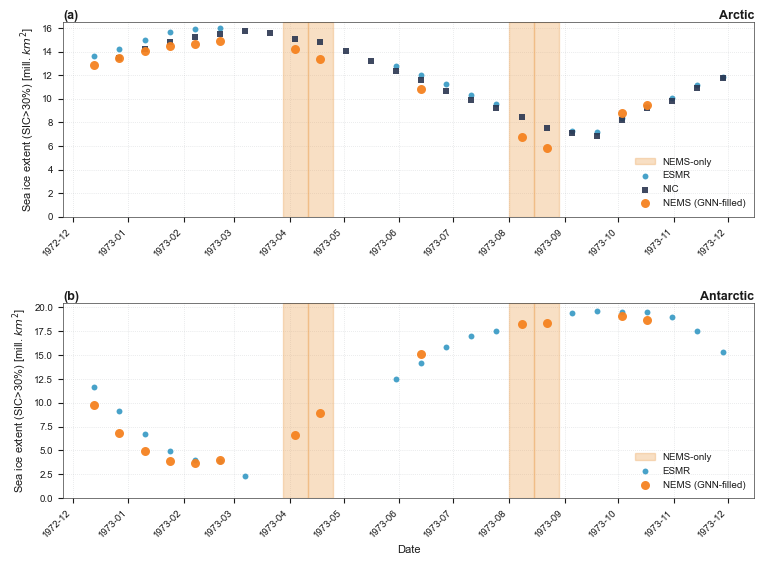

In [29]:
# =============================================================================
# PART 6h — Sea ice extent: NEMS (GNN-filled) vs ESMR vs NIC, from netCDF
# =============================================================================
# This is former cell 22, which was already a from-netCDF rewrite of former
# cell 7 (which built the same figure from `nh_df`/`sh_df`, in-memory stats
# produced by the discarded v3.1 inference run). Cell 7 is dropped rather
# than kept alongside this one. The only change here: NEMS_PROCESSED_ROOT
# now points at GNN_FILLED_MASKED_DIR (Part 6c's output, land already
# NaN'd out) via CONFIG, instead of the stale `GNN-N5NEMS-SIC-1972-1973`
# folder the original pointed at.
# =============================================================================

ESMR_ROOT = NH_ESMR_DIR.parent  # shared parent of NH_ESMR_DIR / SH_ESMR_DIR
NEMS_PROCESSED_ROOT = GNN_FILLED_MASKED_DIR

BIN_START = pd.Timestamp("1972-03-01")
BIN_END = pd.Timestamp("1973-12-01")
bin_edges = pd.date_range(BIN_START, BIN_END, freq="14D")
bin_midpoints = bin_edges + pd.Timedelta(days=7)


def extract_date_from_nc(path):
    m = re.search(r"(\d{8})", path.name)
    return m.group(1) if m else None


def load_nc_ice_and_pixel_area(file_path):
    """Loads ice_conc array and calculates pixel area in km^2 dynamically."""
    with xr.open_dataset(file_path) as ds:
        ice = ds["ice_conc"].squeeze().values.astype(float)
        x_dim = "xc" if "xc" in ds.coords else "x"
        y_dim = "yc" if "yc" in ds.coords else "y"
        x_coords, y_coords = ds[x_dim].values, ds[y_dim].values
        dx, dy = abs(x_coords[1] - x_coords[0]), abs(y_coords[1] - y_coords[0])
        if dx > 1000:
            dx, dy = dx / 1000.0, dy / 1000.0
        pixel_area_km2 = dx * dy
    return ice, pixel_area_km2


def discover_nc_files_by_hemisphere(nc_dir):
    nh_files, sh_files = {}, {}
    for f in sorted(Path(nc_dir).rglob("*.nc")):
        d_str = extract_date_from_nc(f)
        if not d_str:
            continue
        fname_upper = f.name.upper()
        if "_NH-" in fname_upper or "_NH_" in fname_upper:
            nh_files[d_str] = f
        elif "_SH-" in fname_upper or "_SH_" in fname_upper:
            sh_files[d_str] = f
    return nh_files, sh_files


nh_esmr_nc, sh_esmr_nc = discover_nc_files_by_hemisphere(ESMR_ROOT)
nh_nems_nc, sh_nems_nc = discover_nc_files_by_hemisphere(NEMS_PROCESSED_ROOT)
print(f"Found ESMR files -> NH: {len(nh_esmr_nc)}, SH: {len(sh_esmr_nc)}")
print(f"Found NEMS files -> NH: {len(nh_nems_nc)}, SH: {len(sh_nems_nc)}")


def dates_in_range(date_dict, b0, b1):
    out = []
    for d in date_dict:
        dt = pd.Timestamp(datetime.strptime(d, "%Y%m%d"))
        if b0 <= dt < b1:
            out.append(d)
    return out


def calculate_nc_biweekly_sie(nc_dict, bin_edges, sie_threshold=SIE_THRESHOLD, bin_days=14, desc_tag="NC"):
    vals = []
    for b0 in tqdm(bin_edges, desc=f"Processing {desc_tag} bins"):
        b1 = b0 + pd.Timedelta(days=bin_days)
        d_in_bin = dates_in_range(nc_dict, b0, b1)
        if not d_in_bin:
            vals.append(np.nan)
            continue
        stack, area_km2 = [], None
        for d in d_in_bin:
            ice, pixel_area = load_nc_ice_and_pixel_area(nc_dict[d])
            stack.append(ice)
            if area_km2 is None:
                area_km2 = pixel_area
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            comp = np.nanmean(np.stack(stack, axis=0), axis=0)
        vals.append(float((comp >= sie_threshold).sum()) * area_km2 / 1e6)
    return np.array(vals, dtype=float)


def nic_biweekly_sie(file_dates_all, bin_edges, sie_threshold=SIE_THRESHOLD, pixel_area_km2=PIXEL_AREA_KM2, bin_days=14):
    vals, land_cached = [], None
    for b0 in tqdm(bin_edges, desc="Processing NIC bins"):
        b1 = b0 + pd.Timedelta(days=bin_days)
        files_in_bin = [f for f, d in file_dates_all if b0 <= pd.Timestamp(d) < b1]
        if not files_in_bin:
            vals.append(np.nan)
            continue
        grids = [read_nic_bin(f) for f in files_in_bin]
        sic_stack = np.stack([nic_to_sic(g) for g in grids], axis=0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            comp = np.nanmean(sic_stack, axis=0)
        if land_cached is None:
            land_cached = nic_land_mask(grids[0])
        vals.append(float(((comp >= sie_threshold) & ~land_cached).sum()) * pixel_area_km2 / 1e6)
    return np.array(vals, dtype=float)


nh_esmr_biweekly = calculate_nc_biweekly_sie(nh_esmr_nc, bin_edges, desc_tag="NH ESMR")
sh_esmr_biweekly = calculate_nc_biweekly_sie(sh_esmr_nc, bin_edges, desc_tag="SH ESMR")
nh_nems_biweekly = calculate_nc_biweekly_sie(nh_nems_nc, bin_edges, desc_tag="NH NEMS")
sh_nems_biweekly = calculate_nc_biweekly_sie(sh_nems_nc, bin_edges, desc_tag="SH NEMS")
nic_biweekly = (nic_biweekly_sie(nic_file_dates_all, bin_edges) if nic_file_dates_all
                else np.full(len(bin_edges), np.nan))


def drop_outliers(series_v, threshold=3.0, window=5):
    s = pd.Series(series_v)
    rolling_med = s.rolling(window=window, center=True, min_periods=2).median()
    outlier = (s - rolling_med).abs() > threshold
    return s.mask(outlier).values


nh_esmr_biweekly = drop_outliers(nh_esmr_biweekly)
sh_esmr_biweekly = drop_outliers(sh_esmr_biweekly)
nh_nems_biweekly = drop_outliers(nh_nems_biweekly)
sh_nems_biweekly = drop_outliers(sh_nems_biweekly)


def report_unique_coverage(hemisphere_name, esmr_v, nems_v, nic_v, bin_midpoints):
    esmr_mask = ~np.isnan(esmr_v)
    nems_mask = ~np.isnan(nems_v)
    nems_only_vs_esmr = nems_mask & ~esmr_mask
    print(f"\n=== {hemisphere_name}: Coverage Summary ===")
    print(f"ESMR bins:        {esmr_mask.sum()}")
    print(f"NEMS bins:        {nems_mask.sum()}")
    print(f"NEMS-only bins:   {nems_only_vs_esmr.sum()}")
    return {"esmr_mask": esmr_mask, "nems_mask": nems_mask, "nems_only_vs_esmr": nems_only_vs_esmr}


nh_coverage = report_unique_coverage("Arctic (NH)", nh_esmr_biweekly, nh_nems_biweekly, nic_biweekly, bin_midpoints)
sh_coverage = report_unique_coverage("Antarctic (SH)", sh_esmr_biweekly, sh_nems_biweekly, None, bin_midpoints)


def highlight_unique_bins(ax, bin_midpoints, mask, color=COLOR_NEMS_ONLY_SHADE, label="NEMS-only"):
    if not mask.any():
        return
    first = True
    for mid in np.array(bin_midpoints)[mask]:
        ax.axvspan(mid - pd.Timedelta(days=7), mid + pd.Timedelta(days=7), color=color,
                   alpha=0.35, zorder=1, label=label if first else None)
        first = False


# ── Plot ─────────────────────────────────────────────────────────────────

w, h = W_DOUBLE * MM, 140 * MM
fig, axes = plt.subplots(2, 1, figsize=(w, h), layout='constrained')
fig.get_layout_engine().set(w_pad=0.02, h_pad=0.03, hspace=0.12)

for ax, letter, nems_v, esmr_v, nic_v, hemi, coverage in [
        (axes[0], '(a)', nh_nems_biweekly, nh_esmr_biweekly, nic_biweekly, 'Arctic', nh_coverage),
        (axes[1], '(b)', sh_nems_biweekly, sh_esmr_biweekly, None, 'Antarctic', sh_coverage)]:

    highlight_unique_bins(ax, bin_midpoints, coverage["nems_only_vs_esmr"], color=COLOR_NEMS_ONLY_SHADE, label='NEMS-only')

    esmr_mask = ~np.isnan(esmr_v)
    ax.scatter(bin_midpoints[esmr_mask], esmr_v[esmr_mask], color=COLOR_ESMR, marker='o', s=18,
               linewidths=0, alpha=0.9, label='ESMR', zorder=2)
    if nic_v is not None:
        nic_mask = ~np.isnan(nic_v)
        ax.scatter(bin_midpoints[nic_mask], nic_v[nic_mask], color=COLOR_NIC, marker='s', s=18,
                   linewidths=0, alpha=0.9, label='NIC', zorder=2)
    nems_mask = ~np.isnan(nems_v)
    ax.scatter(bin_midpoints[nems_mask], nems_v[nems_mask], color=COLOR_NEMS, marker='o', s=42,
               linewidths=0, alpha=0.95, label='NEMS (GNN-filled)', zorder=3)

    ax.set_ylabel(r'Sea ice extent (SIC>30%) [mill. $km^2$]')
    ax.set_ylim(bottom=0)
    ax.grid(True, color=GRID, alpha=0.6, linewidth=0.4, linestyle=(0, (1, 2.5)))
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor(FRAME)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.text(0.0, 1.0, letter, transform=ax.transAxes, fontsize=9, fontweight='bold', va='bottom', ha='left', color=INK)
    ax.text(1.0, 1.0, hemi, transform=ax.transAxes, fontsize=9, fontweight='bold', va='bottom', ha='right', color=INK)
    ax.legend(loc='lower right')

axes[1].set_xlabel('Date')

saved = []
for ext in ('pdf', 'png'):
    path = PLOT_DIR / f'sie_14day_gnn_filled_vs_esmr_nic.{ext}'
    fig.savefig(path)
    saved.append(str(path))
print('Saved: ' + ', '.join(saved))
plt.show()

### 6i. Manuscript summary statistics

In [30]:
# =============================================================================
# PART 6i — Manuscript summary statistics
# =============================================================================
# The original notebook's version of this cell (former cell 11) re-binned
# NEMS SIE from `nh_nems_dates`/`nh_nems_vals` -- per-date values that only
# existed because former cell 7 (superseded, dropped -- see Part 6h) had
# computed them. Part 6h already produces `nh_nems_biweekly` /
# `sh_nems_biweekly` directly, binned the same way, so that re-binning step
# is now redundant and has been removed; this cell uses Part 6h's series
# as-is.
# =============================================================================

def agreement_stats(a, b, label_a, label_b):
    """Bias, RMSE, correlation and n on bins where both a and b are defined."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    both = ~np.isnan(a) & ~np.isnan(b)
    n = int(both.sum())
    if n < 2:
        print(f'{label_a} vs {label_b}: fewer than 2 jointly-covered bins (n={n}) -- skipping.')
        return
    diff = a[both] - b[both]
    bias = float(np.mean(diff))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r = float(np.corrcoef(a[both], b[both])[0, 1]) if n >= 3 else float('nan')
    print(f'{label_a} vs {label_b}  (n={n} jointly-covered 14-day bins)')
    print(f'  bias (mean {label_a} - {label_b}): {bias:+.3f} mill. km^2')
    print(f'  RMSE:                          {rmse:.3f} mill. km^2')
    print(f'  correlation r:                 {r:.3f}\n')


print('=== Sea ice extent agreement ===\n')
agreement_stats(nh_nems_biweekly, nh_esmr_biweekly, 'NEMS', 'ESMR (Arctic)')
agreement_stats(nh_nems_biweekly, nic_biweekly, 'NEMS', 'NIC (Arctic)')
agreement_stats(sh_nems_biweekly, sh_esmr_biweekly, 'NEMS', 'ESMR (Antarctic)')

print('=== NEMS - NIC concentration difference (Figure 8, panel F) ===\n')
if 'nh_nems_nic_diff' in globals() and nh_nems_nic_diff is not None:
    diff = np.asarray(nh_nems_nic_diff, dtype=float)
    valid = ~np.isnan(diff)
    n_valid = int(valid.sum())
    if n_valid:
        print(f'  valid (non-land, non-missing) pixels: {n_valid:,} of {diff.size:,} '
              f'({100 * n_valid / diff.size:.1f}%)')
        print(f'  mean bias (NEMS - NIC):  {np.mean(diff[valid]):+.2f} pp')
        print(f'  median bias:             {np.median(diff[valid]):+.2f} pp')
        print(f'  std dev:                 {np.std(diff[valid]):.2f} pp')
        print(f'  RMS difference:          {np.sqrt(np.mean(diff[valid] ** 2)):.2f} pp')
        print(f'  5th / 95th percentile:   {np.percentile(diff[valid], 5):+.2f} / '
              f'{np.percentile(diff[valid], 95):+.2f} pp')
        print(f'  min / max:               {np.nanmin(diff[valid]):+.2f} / {np.nanmax(diff[valid]):+.2f} pp')
    else:
        print('  nh_nems_nic_diff exists but contains no valid (non-NaN) pixels.')
else:
    print('  nh_nems_nic_diff not found -- run Part 6f (Figure-8-style panel F) first.')

=== Sea ice extent agreement ===

NEMS vs ESMR (Arctic)  (n=9 jointly-covered 14-day bins)
  bias (mean NEMS - ESMR (Arctic)): -0.732 mill. km^2
  RMSE:                          0.930 mill. km^2
  correlation r:                 0.993

NEMS vs NIC (Arctic)  (n=12 jointly-covered 14-day bins)
  bias (mean NEMS - NIC (Arctic)): -0.602 mill. km^2
  RMSE:                          0.932 mill. km^2
  correlation r:                 0.974

NEMS vs ESMR (Antarctic)  (n=9 jointly-covered 14-day bins)
  bias (mean NEMS - ESMR (Antarctic)): -0.833 mill. km^2
  RMSE:                          1.291 mill. km^2
  correlation r:                 0.987

=== NEMS - NIC concentration difference (Figure 8, panel F) ===

  valid (non-land, non-missing) pixels: 56,608 of 186,624 (30.3%)
  mean bias (NEMS - NIC):  +3007.89 pp
  median bias:             +0.00 pp
  std dev:                 4289.75 pp
  RMS difference:          5239.22 pp
  5th / 95th percentile:   -90.00 / +9905.00 pp
  min / max:               -

### 6j. Extent agreement by season

In [31]:
# =============================================================================
# PART 6j — Extent agreement by season: transition months vs. rest
# =============================================================================
# Unchanged logic from former cell 16 -- its inputs (nh_nems_biweekly,
# nh_esmr_biweekly, nic_biweekly, bin_midpoints) already come from Part 6h,
# which reads them from the GNN-filled netCDF files.
# =============================================================================

TRANSITION_MONTHS = {3, 9}  # Arctic freeze-up / melt-onset months
bin_months = pd.DatetimeIndex(bin_midpoints).month


def seasonal_agreement(nems_bin, other_bin, label_a, label_b):
    both = ~np.isnan(nems_bin) & ~np.isnan(other_bin)
    if both.sum() < 2:
        print(f'{label_a} vs {label_b}: insufficient jointly-covered bins.')
        return

    diff = nems_bin[both] - other_bin[both]
    months = bin_months[both]
    is_transition = np.isin(months, list(TRANSITION_MONTHS))

    def _report(mask, tag):
        n = int(mask.sum())
        if n == 0:
            print(f'    {tag}: no bins.')
            return
        d = diff[mask]
        print(f'    {tag} (n={n}): bias={np.mean(d):+.3f}  RMSE={np.sqrt(np.mean(d**2)):.3f}  mill. km^2')

    print(f'{label_a} vs {label_b}')
    _report(np.ones_like(is_transition, dtype=bool), 'all bins    ')
    _report(is_transition, 'transition  ')
    _report(~is_transition, 'core (rest) ')

    if is_transition.any() and (~is_transition).any():
        rmse_trans = np.sqrt(np.mean(diff[is_transition] ** 2))
        rmse_core = np.sqrt(np.mean(diff[~is_transition] ** 2))
        ratio = rmse_trans / rmse_core if rmse_core > 0 else np.nan
        verdict = 'LARGER' if ratio > 1.2 else ('SMALLER' if ratio < 0.8 else 'COMPARABLE')
        print(f'    -> transition-month RMSE is {verdict} than core-month RMSE (ratio={ratio:.2f})')
    print()


print('=== Sea ice extent agreement, transition vs. core months ===\n')
seasonal_agreement(nh_nems_biweekly, nh_esmr_biweekly, 'NEMS', 'ESMR (Arctic)')
seasonal_agreement(nh_nems_biweekly, nic_biweekly, 'NEMS', 'NIC (Arctic)')

=== Sea ice extent agreement, transition vs. core months ===

NEMS vs ESMR (Arctic)
    all bins     (n=9): bias=-0.732  RMSE=0.930  mill. km^2
    transition  : no bins.
    core (rest)  (n=9): bias=-0.732  RMSE=0.930  mill. km^2

NEMS vs NIC (Arctic)
    all bins     (n=12): bias=-0.602  RMSE=0.932  mill. km^2
    transition  : no bins.
    core (rest)  (n=12): bias=-0.602  RMSE=0.932  mill. km^2



In [32]:
# =============================================================================
# PART 6i (cont.) — Monthly SIE summary table (LaTeX)
# =============================================================================
# Monthly view of the same 14-day-binned extents computed in Part 6h
# (nh_nems_biweekly, nh_esmr_biweekly, nic_biweekly, sh_nems_biweekly,
# sh_esmr_biweekly / bin_midpoints) -- not a separate computation. A month
# with two bin midpoints falling inside it is the plain average of those
# two bins; a month covered by only ONE 14-day bin is still shown, marked
# with a dagger, since a single bin is a weaker stand-in for the full month
# than two. A month with no covering bin at all is shown as "--".
# =============================================================================

def _monthly_from_biweekly(values, midpoints):
    """Return {(year, month): (mean_value, n_bins_used)}, skipping all-NaN bins."""
    df = pd.DataFrame({"val": values}, index=pd.DatetimeIndex(midpoints))
    out = {}
    for (y, m), grp in df.groupby([df.index.year, df.index.month]):
        v = grp["val"].dropna()
        if len(v):
            out[(y, m)] = (float(v.mean()), len(v))
    return out


def _fmt_cell(monthly, key, width=5):
    if key not in monthly:
        return f"{'--':>{width}}"
    val, n = monthly[key]
    s = f"{val:{width}.2f}"
    return s + r"\rlap{\textsuperscript{\dag}}" if n == 1 else s


nh_nems_m = _monthly_from_biweekly(nh_nems_biweekly, bin_midpoints)
nh_esmr_m = _monthly_from_biweekly(nh_esmr_biweekly, bin_midpoints)
nic_m = _monthly_from_biweekly(nic_biweekly, bin_midpoints)
sh_nems_m = _monthly_from_biweekly(sh_nems_biweekly, bin_midpoints)
sh_esmr_m = _monthly_from_biweekly(sh_esmr_biweekly, bin_midpoints)

months = pd.period_range("1972-12", "1973-11", freq="M")

lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\label{tab:sie-monthly}",
    r"\begin{tabular}{lrrrrr}",
    r"\toprule",
    r" & \multicolumn{3}{c}{Arctic} & \multicolumn{2}{c}{Antarctic} \\",
    r"\cmidrule(lr){2-4}\cmidrule(lr){5-6}",
    r"Month & NEMS & ESMR & NIC & NEMS & ESMR \\",
    r"\midrule",
]
for p in months:
    key = (p.year, p.month)
    lines.append(
        f"{p.strftime('%b %Y')} & {_fmt_cell(nh_nems_m, key)} & {_fmt_cell(nh_esmr_m, key)} & "
        f"{_fmt_cell(nic_m, key)} & {_fmt_cell(sh_nems_m, key)} & {_fmt_cell(sh_esmr_m, key)} \\\\"
    )
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

latex_table = "\n".join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\label{tab:sie-monthly}
\begin{tabular}{lrrrrr}
\toprule
 & \multicolumn{3}{c}{Arctic} & \multicolumn{2}{c}{Antarctic} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-6}
Month & NEMS & ESMR & NIC & NEMS & ESMR \\
\midrule
Dec 1972 & 13.17 & 13.91 & 13.45\rlap{\textsuperscript{\dag}} &  8.28 & 10.38 \\
Jan 1973 & 14.26 & 15.30 & 14.50 &  4.46 &  5.84 \\
Feb 1973 & 14.77 & 15.97 & 15.38 &  3.80 &  3.97 \\
Mar 1973 &    -- &    -- & 15.67 &    -- &  2.36\rlap{\textsuperscript{\dag}} \\
Apr 1973 & 13.81 &    -- & 14.94 &  7.77 &    -- \\
May 1973 &    -- & 12.74\rlap{\textsuperscript{\dag}} & 13.21 &    -- & 12.47\rlap{\textsuperscript{\dag}} \\
Jun 1973 & 10.87\rlap{\textsuperscript{\dag}} & 11.66 & 11.11 & 15.16\rlap{\textsuperscript{\dag}} & 14.97 \\
Jul 1973 &    -- &  9.94 &  9.55 &    -- & 17.25 \\
Aug 1973 &  6.26 &    -- &  7.98 & 18.29 &    -- \\
Sep 1973 &    -- &  7.23 &  6.96 &    -- & 19.50 \\
Oct 1973 &  9.12 &  9.25 &  9.08 & 18.92 & 19.36 \\
Nov 1973 &    